# Analyzing IDR sequence grammar from human IDRome

This notebook calculates the compositional and patterning sequence features from any accessions list

* Part 0: Load in python libraries needed

* Part 1: Load in human IDRome and IDR subset of interest
    
* Part 2: Analyze patterning features
    * NARDINI Radial Bar Charts
    
* Part 3: Analyze compositional features
    * Compositional Pie Charts

* Part 4: Analyze all sequence features
    * Clustered Z-score Heat Map
    * Clusters within accessions of interest
    
* Part 5: Get which of the 30 clusters the IDR corresponds to
    
* Part 6: Create sequence block diagrams
    
* Part 7: Compare to other IDRs

# Part 0: Load in libraries that are needed

In [2]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import localcider
from localcider.sequenceParameters import SequenceParameters
import re
import math
import scipy
from scipy.stats import ks_2samp
from matplotlib.patches import Rectangle
import pathlib
from matplotlib import font_manager

# Setup the fonts
fonts_path = pathlib.Path.home().joinpath('fonts') # i.e. `~/fonts` (update as needed)
font_filename = 'ARIAL.TTF'
font_path = fonts_path.joinpath(font_filename)
print(font_path)

font_manager.fontManager.addfont(str(font_path))
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42

COLOR_MAP = dict()
COLOR_MAP['A']         = '#8c8c8c'
COLOR_MAP['CHNQST']    = '#077a15'
COLOR_MAP['DE']        = '#e23a36'
COLOR_MAP['FWY']       = '#f58220'
COLOR_MAP['G']         = '#86bd8d'
COLOR_MAP['ILMV']      = '#231f20'
COLOR_MAP['KR']        = '#1725c2'
COLOR_MAP['P']         = '#c25fc9'


# Using the global color map, we convert the colormap of amino acid
# groups, to a map against individual amino acids. This
# serves as our internal color map which is used for styling.
aacolor_map=dict()
for amino_acids in COLOR_MAP:
    for amino_acid in amino_acids:
        aacolor_map[amino_acid] = COLOR_MAP[amino_acids]

/home/compute/kiersten.ruff/fonts/ARIAL.TTF


# Part 1: Load in all data for IDRs of interest

In [3]:
mainprotein='catsper1_n_terminals'

## 1.1 Load in All Sapiens Disordered Stretches >=30

In [5]:
speciesname='sapiens'

# Gene names table
mapdf=pd.read_table(speciesname+'_uniprot_gene_name.tsv')

accsmap=mapdf['Uniprot'].tolist()
genesmap=mapdf['Gene'].tolist()

# Load in IDRome information
myseqs=[]
fullaccswnums=[]
goodidxs=[]
badidxs=[]
fullaccs=[]
mygenes=[]
mygeneswnum=[]

myfile = open('disorder/min_length_30/'+speciesname, 'r')
Lines = myfile.readlines()

count=0
for line in Lines:
    count=count+1
    fullline=line.split(" ")
    tmpseq=fullline[3]
    tmpacc=fullline[0]
    currseq=tmpseq.strip('\n')
    
    if len(currseq)>=30 and "X" not in currseq and "U" not in currseq and "Z" not in currseq and "J" not in currseq and "B" not in currseq and "O" not in currseq:
        myseqs.append(currseq)
        fullaccswnums.append(tmpacc)
        goodidxs.append(count)
        tmp=tmpacc.split("_")
        fullaccs.append(tmp[0])
        if tmp[0] in accsmap:
            currgidx=accsmap.index(tmp[0])
            mygenes.append(genesmap[currgidx])
            mygeneswnum.append(genesmap[currgidx]+' IDR'+tmp[1])
        else:
            mygenes.append(tmpacc)
            mygeneswnum.append(tmpacc+' IDR'+tmp[1])
    else:
        badidxs.append(count)
        
print(len(myseqs))
print(count)
print(len(goodidxs))
print(badidxs)

24508
24535
24508
[337, 338, 5387, 7965, 8270, 8860, 9309, 13434, 18343, 20894, 20895, 20896, 20897, 20898, 20900, 20901, 20902, 20903, 20904, 20905, 20906, 20907, 20908, 20909, 21628, 22016, 23960]


## 1.2 Load in your subset of IDRs of interest

In [6]:
## Load in sequences
myfile = open(mainprotein+'_remove_bad.fasta', 'r')
Lines = myfile.readlines()

subgenes=[]
subseqs=[]
substpos=[]
subenpos=[]
subidrlens=[]
subaccs=[]
thisseq = ''
for line in Lines:
    
    # remove pesky newline
    cleanline = line.strip()
    print(cleanline)
    
    if cleanline[0]=='>':
        tmp=cleanline
        tmp2=tmp.split('_')
        tmp3=" ".join(tmp2[:-1])
        tmp4=tmp3.split('>')
        subgenes.append(tmp4[1])
        #substpos.append(int(tmp6[0])-1)
        #subenpos.append(int(tmp6[1]))
        subaccs.append(tmp4[1])
        
        # check that this is not the very first sequence, if not 
        # add the sequence
        if (thisseq is not ''): 
            subseqs.append(thisseq.upper()) 

            # reset the sequence for the coming entry
            thisseq = '' 

    # else append the sequence
    else:
        thisseq += cleanline

# store the final sequence	
subseqs.append(thisseq.upper())

for s in subseqs:
    subidrlens.append(len(s))
    substpos.append(0)
    subenpos.append(len(s))

print((subgenes))
print((subseqs))
print((substpos))
print((subenpos))
print((subidrlens))
print((subaccs))


>Mus_musculus_0
MDQSSRRDESYHETHPGSLDPSHQSHPHPHPHPTLHRPNQGGVYYDSPQHGMFQQPYQQHGGFHQQNELQHLREFSDSHDNAFSHHSYQQDRAGVSTLPNNISHAYGGSHPLAESQHSGGPQSGPRIDPNHHPHQDDPHRPSEPLSHPSSTGSHQGTTHQQYHERSHHLNPQQNRDHADTISYRSSTRFYRSHAPFSRQERPHLHADHHHEGHHAHSHHGEHPHHKEQRHYHGDHMHHHIHHRSPSASQLSHKSHSTLATSPSHVGSKSTASGARYTFGARSQIFGKAQSRESLRESASLSEGEDHVQKRKKAQRAHKKAHTGNIFQLLWEK
>Cavia_porcellus_13
QSEFLMTEKAQNEHSTSNLDTLPHPHSSSPHRRPEQDRPRQHESHHLPGGGRHHSESHQRRDIRQDFQDSALSQSHHSKAQPHDRAHHRTSLGWGPSPATVHHTEPHHDGPHHQGRHHYHGGHQPSVVTHQPSEMSSSSRHCLPSVSPHHSEYGHHGGLHHKSPSHQHEYSYHHSEEYRRKGSQHHEAHESNKLHPHDTPPSQERYHPTLSESYHRGAPHVLREKLSCAYRYDHRDSYKDSHRSTSQLFVPHKPHSAVGSGIHQELTKGLPHGSRIRSLTAVHSHGSQVSNKVHPQDISTIDSEYWSEDEQYQRQKRSRGQRIQKKFVVNIFQRLCER
>Octodon_degus_26
MGEPLMPEKVRDEHDTNNLDIPSHSHSSFQHHRPDHDRYHRPHESHHFTEGHHHGPTISHPLVGIPPILPTTPTIIMKTTLMMNTTMVVGFIRVGPITIQRHTTTTLDLNKVGPTTMLSQTTMMGHITKAGIIILVGIHTTNPLVCPTNTVRFPTLVGTIYLVCRTTMVSMAHTITPRGPSILNPTSMTGSILMNTTTTKSTLITKIIFTAIPLRSPTTMAHLTFTEKIMEVINPVKTTMVSTTTIEITTMGSNTMLSHTIVTTTTTEITTMVN

# Part 2: Analyze Patterning Features

## 2.1 Load in NARDINI data for your subset of IDRs

In [7]:
mypattfeats_all=['pol-pol','pol-hyd','pol-pos','pol-neg','pol-aro','pol-ala','pol-pro','pol-gly','hyd-hyd','hyd-pos','hyd-neg','hyd-aro','hyd-ala','hyd-pro','hyd-gly','pos-pos','pos-neg','pos-aro','pos-ala','pos-pro','pos-gly','neg-neg','neg-aro','neg-ala','neg-pro','neg-gly','aro-aro','aro-ala','aro-pro','aro-gly','ala-ala','ala-pro','ala-gly','pro-pro','pro-gly','gly-gly']
subzvecpatt_all=np.zeros((len(subseqs),len(mypattfeats_all)))

for s in range(0,len(subseqs)):
    tmpzec=np.load('zscores/job-{:04d}.npy'.format(s+1))
    #print('job-{:04d}.npy'.format(s+1))
    zm_list_36 = np.zeros([1,36])
    count=-1
    count2=-1
    for i in range(0,8):
        for j in range(0,8):
            count=count+1
            if j>=i:
                count2=count2+1
                zm_list_36[0][count2]=tmpzec[0][count]
        
    
    subzvecpatt_all[s,:]=zm_list_36[0]
    
print(np.shape(subzvecpatt_all))
print(subzvecpatt_all[0,:])
print(subseqs[0])

(41, 36)
[-1.64569489  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.        ]
MDQSSRRDESYHETHPGSLDPSHQSHPHPHPHPTLHRPNQGGVYYDSPQHGMFQQPYQQHGGFHQQNELQHLREFSDSHDNAFSHHSYQQDRAGVSTLPNNISHAYGGSHPLAESQHSGGPQSGPRIDPNHHPHQDDPHRPSEPLSHPSSTGSHQGTTHQQYHERSHHLNPQQNRDHADTISYRSSTRFYRSHAPFSRQERPHLHADHHHEGHHAHSHHGEHPHHKEQRHYHGDHMHHHIHHRSPSASQLSHKSHSTLATSPSHVGSKSTASGARYTFGARSQIFGKAQSRESLRESASLSEGEDHVQKRKKAQRAHKKAHTGNIFQLLWEK


## 2.2 Removing patterning features that are all zeros for your given accession list - this just helps with cleanup

In [8]:
mypattfeats=[]
indices=[]
for f in range(0,len(mypattfeats_all)):
    all_zeros = not np.any(subzvecpatt_all[:,f])
    #print(all_zeros)
    #print(np.sum(zvecpatt[:,f]))
    if all_zeros == False:
        indices.append(f)
        mypattfeats.append(mypattfeats_all[f])
        #print(mypattfeats_all[f])
    
print(len(indices))
print(mypattfeats)

subzvecpatt=np.zeros((len(subseqs),len(mypattfeats)))

for s in range(0,len(subseqs)):
    for i in range(0,len(indices)):
        subzvecpatt[s,i]=subzvecpatt_all[s,indices[i]]

print(subzvecpatt[0])

27
['pol-pol', 'pol-hyd', 'pol-pos', 'pol-neg', 'pol-ala', 'pol-pro', 'pol-gly', 'hyd-hyd', 'hyd-pos', 'hyd-neg', 'hyd-ala', 'hyd-pro', 'hyd-gly', 'pos-pos', 'pos-neg', 'pos-ala', 'pos-pro', 'pos-gly', 'neg-neg', 'neg-ala', 'neg-pro', 'neg-gly', 'ala-ala', 'ala-pro', 'pro-pro', 'pro-gly', 'gly-gly']
[-1.64569489  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.        ]


## 2.3 Different patterning specific analyses you may want to run

In [7]:
# Create heatmap

typeall=['pol','hyd','pos','neg','aro','ala','pro','gly']

## Pick the IDR you want to consider ##
whichseq='ARID1A: 1-1011'
whichseqpos=subgenes.index(whichseq)
whichsequnderscore=whichseq.replace(": ", "_")

mymat=np.zeros([len(typeall),len(typeall)])
count=-1
for i in range(0,len(typeall)):
    for j in range(i,len(typeall)):
        count=count+1
        mymat[i,j]=subzvecpatt_all[whichseqpos][count]
        
#print(zvec[IDRidx])
#print(mymat)

# 3. Plot the heatmap
plt.style.use("seaborn")
plt.figure(figsize=(6,5))
heat_map = sbn.heatmap( mymat, linewidth = 1 , annot = True, cmap='RdBu_r',vmin=-3,vmax=3)
plt.title(whichseq)
#heat_map.set_xticks(range(len(typeall))) # <--- set the ticks first
heat_map.set_xticklabels(typeall)
heat_map.set_yticklabels(typeall)
#plt.show()

#plt.savefig('figures/individual_nardini_heatmaps/'+mainprotein+'/'+whichsequnderscore+"_NARDINI_MATRIX.pdf", transparent=True, bbox_inches = "tight")

ValueError: 'ARID1A: 1-1011' is not in list

### 2.3.2 - Plot NARDINI Circular bar graph for a Given IDR

1.9301554658289921
2.5048694489158185


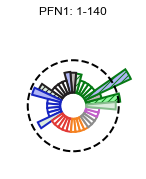

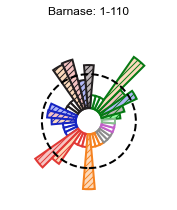

In [53]:
#maxval=10
typeall=['pol','hyd','pos','neg','aro','ala','pro','gly']


def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

# Kiersten's colors
#aatypecolors=['#1f8241','#231f20','#189bd7','#e23a36','#f58220','#8c8c8c','#7c2880','#d865a6']
# Matt's colors
aatypecolors=['#077a15','#231f20','#1725c2','#e23a36','#f58220','#8c8c8c','#c25fc9','#86bd8d']

## Pick which IDR you want to consider ##
#whichseqs=['SMARCA2: 1-344', 'SMARCA2: 508-594', 'SMARCA2: 631-726', 'SMARCA2: 1165-1258', 'SMARCA2: 1327-1411', 'SMARCA2: 1494-1590', 'SMARCA4: 1-368', 'SMARCA4: 532-617', 'SMARCA4: 653-756', 'SMARCA4: 1195-1321', 'SMARCA4: 1390-1454', 'SMARCA4: 1569-1647']
#whichseqs=['ARID1A: 1-1011','ARID1B: 1-1047']
whichseqs=subgenes

for s in range(0,len(whichseqs)):
    whichseq=whichseqs[s]

    whichseqpos=subgenes.index(whichseq)

    ## Get patterning zvec ##
    currzvecpatt=subzvecpatt_all[whichseqpos,:]
    patttype=[]
    for i in range(0,len(currzvecpatt)):
        if currzvecpatt[i]<0:
            patttype.append('////')
        else:
            patttype.append('')

    ## Create colors for patterning zvec ##
    hexedgecolors=[]
    hexfillcolors=[]
    count=-1
    for i in range(0,len(typeall)):
        for j in range(i,len(typeall)):
            count=count+1
            if currzvecpatt[count]==0:
                hexfillcolors.append('#ffffff')
            else:
                tmpcolor=lighten_color(aatypecolors[j],0.3)
                hexfillcolors.append(tmpcolor)
            hexedgecolors.append(aatypecolors[i])

    #colors = cm.RdBu_r((currzvecpatt-minval)/(maxval-minval))
    #hexcolors=[]
    #for i in range(0,len(colors)):
    #    rgba = colors[i]
    #    # rgb2hex accepts rgb or rgba
    #    hexcolors.append(mpl.colors.rgb2hex(rgba))


    ## Build a dataset ##
    df = pd.DataFrame(
            {
                'Name': mypattfeats_all,
                'Value': abs(currzvecpatt),
                'EdgeColors': hexedgecolors,
                'FillColors': hexfillcolors,
                'PattType': patttype
            })


    #print(df)

    ## Create Figure ##

    # Constants = parameters controling the plot layout:
    upperLimit = 50
    lowerLimit = 0.5 #if zero all same size: 1 - Value should be larger than nonzero df['Value'].min()
    labelPadding = 4

    # Compute max and min in the dataset
    maxval = df['Value'].max()
    print(maxval)

    # Let's compute heights: they are a conversion of each item value in those new coordinates
    # In our example, 0 in the dataset will be converted to the lowerLimit (10)
    # The maximum will be converted to the upperLimit (100)
    slope = (maxval - lowerLimit) / maxval
    heights = slope * df.Value + lowerLimit

    # Compute the width of each bar. In total we have 2*Pi = 360°
    width = 2*np.pi / len(df.index)

    # Compute the angle each bar is centered on:
    indexes = list(range(1, len(df.index)+1))
    angles = [element * width for element in indexes]
    angles
    
    # initialize the figure - made so z-score=1 always the same size
    plt.figure(figsize=(max(heights)+lowerLimit,max(heights)+lowerLimit))
    ax = plt.subplot(111, polar=True)
    plt.axis('off')    

    # Draw bars
    bars = ax.bar(
        x=angles, 
        height=heights, 
        width=width, 
        bottom=lowerLimit,
        linewidth=2, 
        edgecolor=df['EdgeColors'].tolist(),
        hatch=df['PattType'].tolist(),
        color=df['FillColors'].tolist(),
    )

    ## add |z-score|==1 threshold line 
    circle = plt.Circle((0, 0), lowerLimit + slope * 1 + lowerLimit, transform=ax.transData._b, fill=False, edgecolor='black', ls='--',linewidth=2, zorder=10)
    plt.gca().add_artist(circle)

    plt.title(whichseq)
    whichsequnderscore=whichseq.replace(": ", "_")

    #plt.savefig('figures/patterning_circular_bar_zscores/'+mainprotein+'/'+whichsequnderscore+"_NARDINI_radial_bar_plot.pdf", transparent=True, bbox_inches = "tight")

### 2.3.3 - Plot Clustered Heatmap NARDINI

    pol-pol   pol-hyd   pol-aro   pol-pro   pol-gly   hyd-hyd   hyd-pro  \
0  0.438624 -0.112697  0.000000 -0.674473 -0.006266 -0.092569 -1.496436   
1 -1.131987 -0.741655  0.000000 -1.257895  0.342914  0.212766 -0.358063   
2  4.798746  0.000000  0.176415  0.000000  6.778466  0.000000  0.000000   
3  0.646083  0.061537  0.000000 -0.858312  0.367701 -0.091607 -0.920836   

    hyd-gly   aro-aro   aro-gly   pro-pro   pro-gly   gly-gly  
0  1.649391  0.000000  0.000000 -0.207885  0.871522  1.941590  
1 -0.024698  0.000000  0.000000 -1.827911 -2.147850 -0.691776  
2  0.000000 -3.200762  3.751101  0.000000  0.000000  4.846967  
3  1.889655  0.000000  0.000000 -0.135843  1.051939  2.312544  
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  backgroundcolor: color
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip

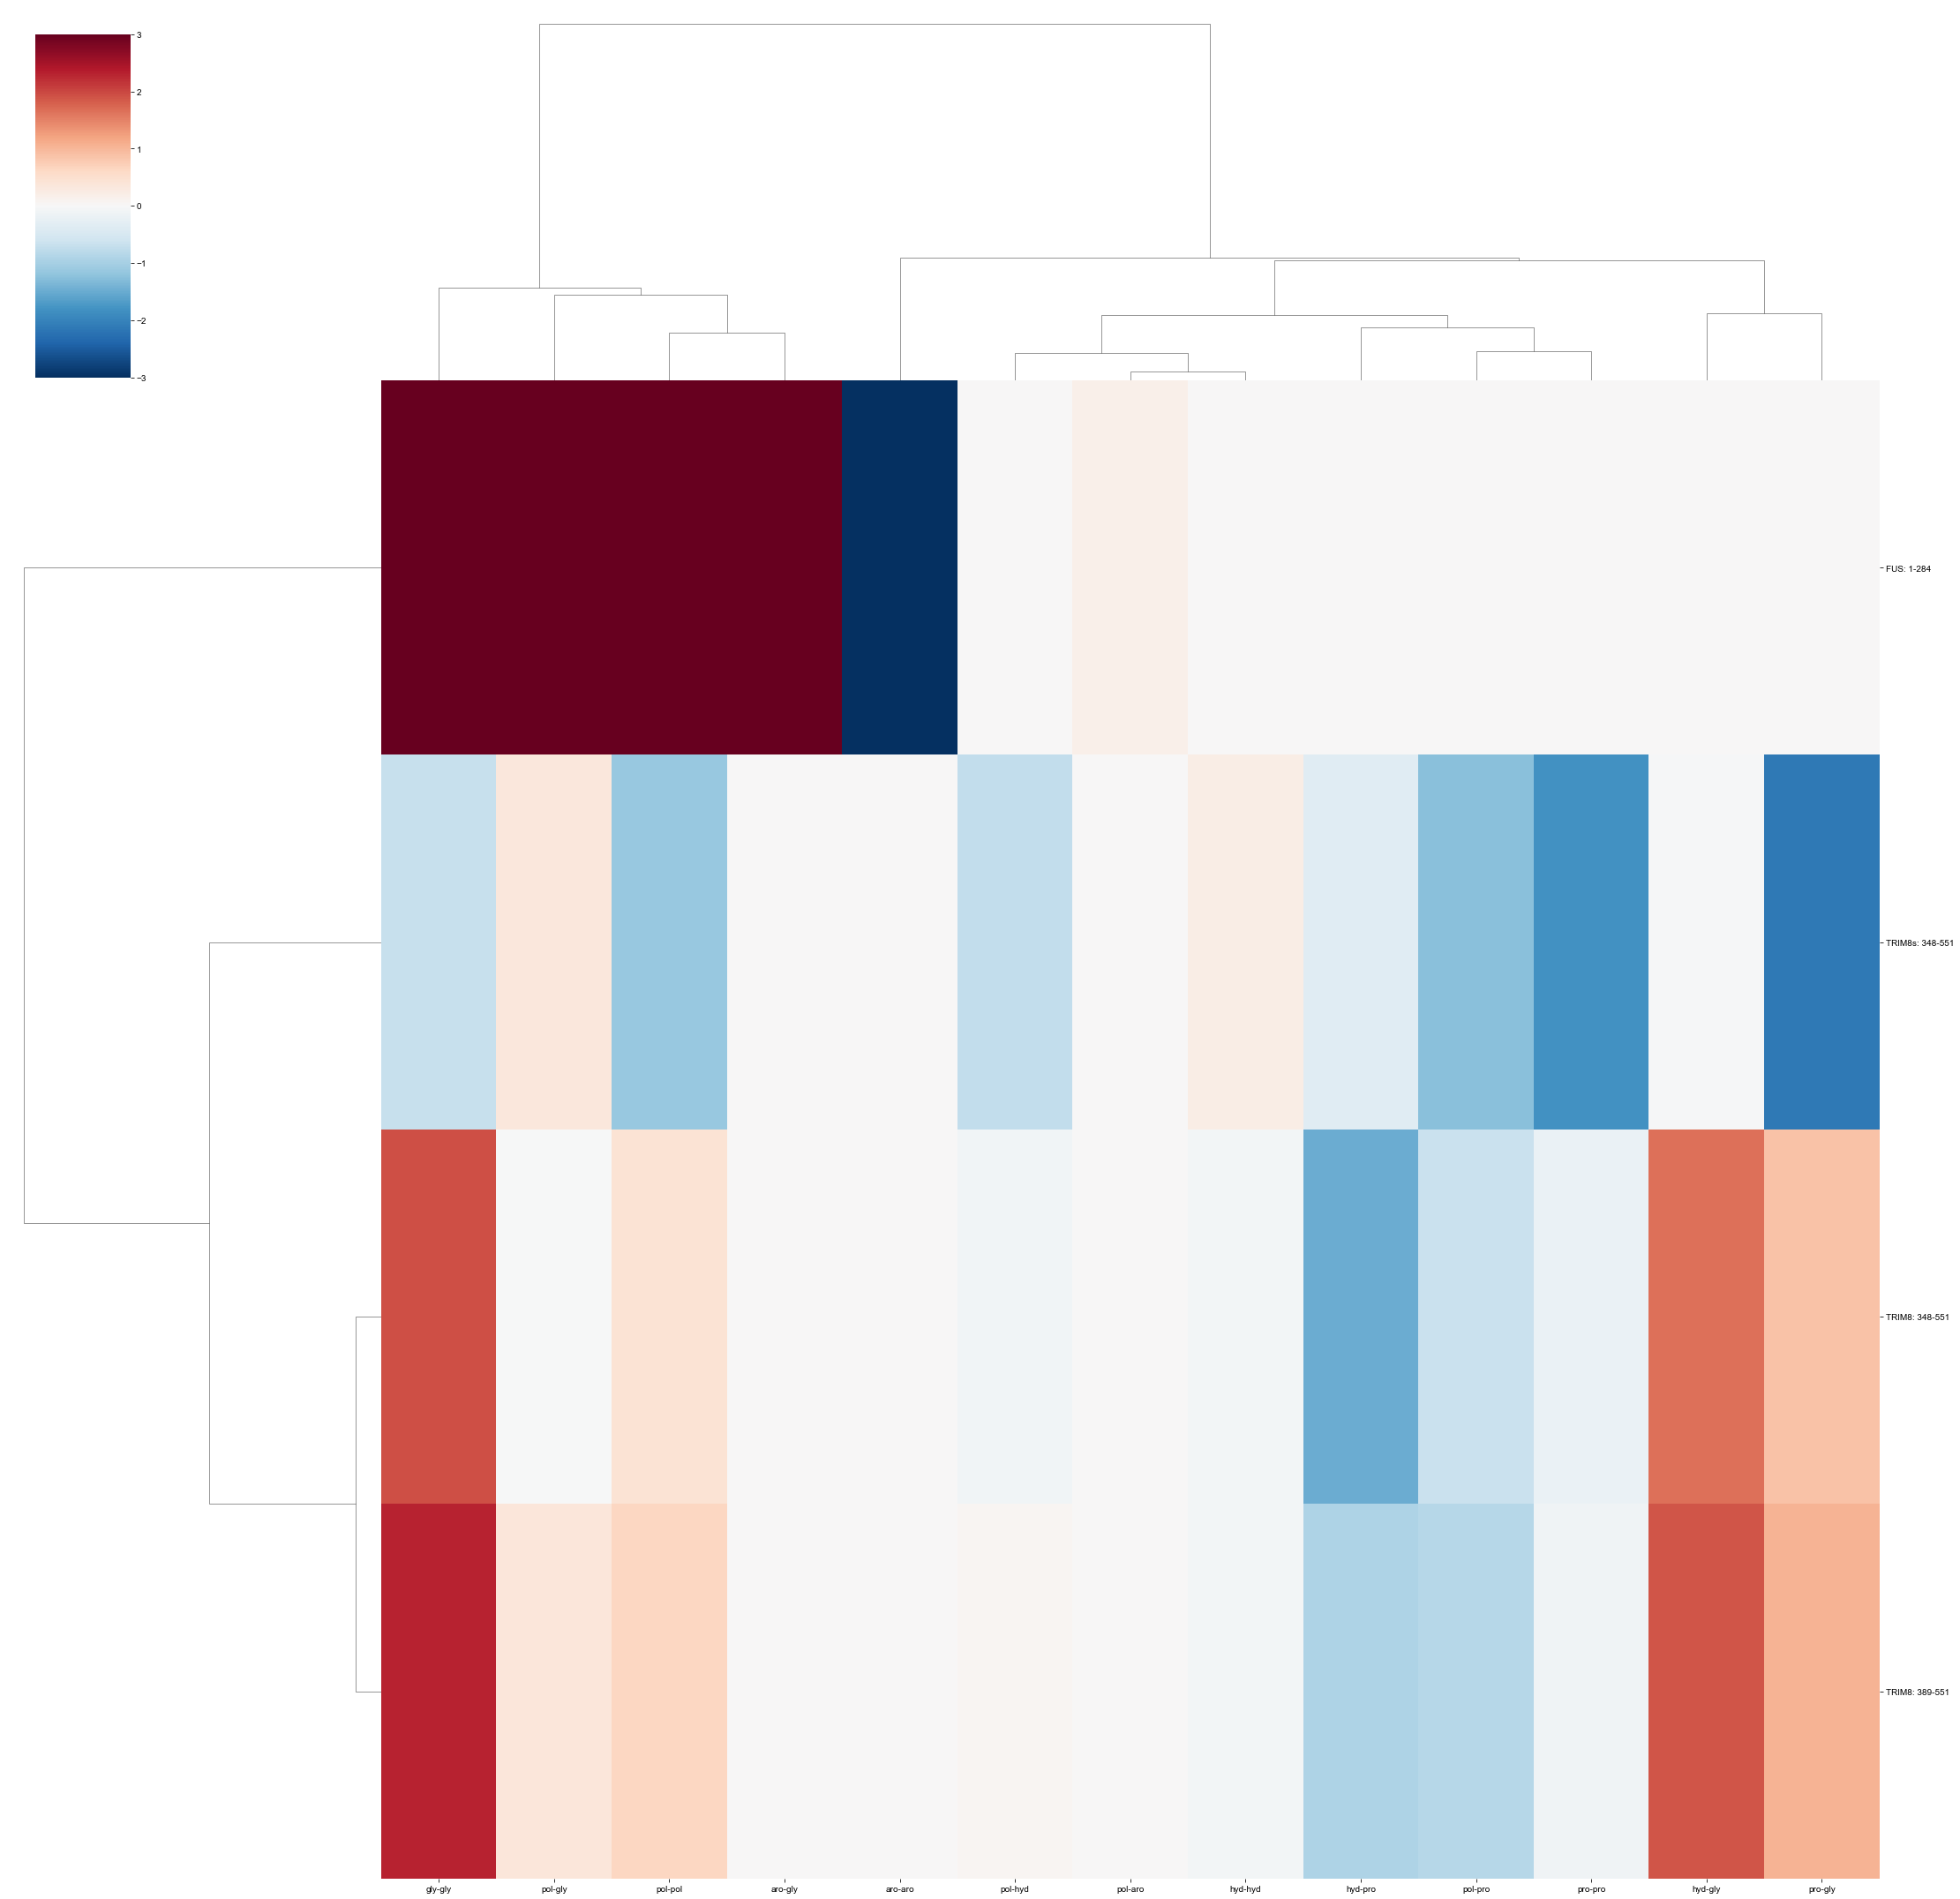

In [46]:
df2 = pd.DataFrame(subzvecpatt, columns=mypattfeats)
#df2 = df2.loc[:, df2.std() > 0.1]
print(df2)
#hi

clust_map = sbn.clustermap(df2, metric="euclidean", method="ward",cmap='RdBu_r',figsize=(30, 30),vmin=-3,vmax=3) 
#clust_map = sbn.clustermap(df2, metric="euclidean", method="ward",cmap='RdBu_r',figsize=(18, 8),vmin=-3,vmax=3,linewidth=0.5) 

rowindex=clust_map.dendrogram_row.reordered_ind
#print(rowindex)

ylabellist=[]
for r in rowindex:
    ylabellist.append(subgenes[r])

plt.setp(clust_map.ax_heatmap.get_yticklabels(),rotation=0)
plt.setp(clust_map.ax_heatmap.set_yticklabels(ylabellist))

colindex=clust_map.dendrogram_col.reordered_ind
#print(colindex)

clusters = scipy.cluster.hierarchy.fcluster(clust_map.dendrogram_row.linkage, 30, 'distance')
print(clusters)
numclust=max(clusters)


#plt.savefig("figures/clustered_zscore_heatmaps/"+mainprotein+"_clustered_sequence_features_IDRs_gte_30_patterning.pdf", transparent=True, bbox_inches = "tight") 


# Part 3: Analyze Compositional Features

## 3.1 Get compositional values for each of the sub sequences

In [9]:
mycompfeats_all=['Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','W Patch','Y Patch','RG Frac']

numInt=2 # Number of allowable interruption residues
minBlockLen=4 # Must have at least minBlockLen lysines in the block

aas='ACDEFGHIKLMNPQRSTVWY' # For pathces - no W patch in proteome so this is removed

fracA=[]
fracC=[]
fracD=[]
fracE=[]
fracF=[]
fracG=[]
fracH=[]
fracI=[]
fracK=[]
fracL=[]
fracM=[]
fracN=[]
fracP=[]
fracQ=[]
fracR=[]
fracS=[]
fracT=[]
fracV=[]
fracW=[]
fracY=[]
fracpos=[]
fracneg=[]
fracpol=[]
fracali=[]
fracaro=[]
fracRtoK=[]
fracEtoD=[]
fracexp=[]
fcr=[]
ncpr=[]
mhydro=[]
dispro=[]
isopoi=[]
ppii=[]
fracpatch=[[] for _ in range(len(aas))]
rgpatch=[]

myseqlens=[]

for currseq in subseqs:

    if len(currseq)>=1 and "X" not in currseq and "U" not in currseq and "Z" not in currseq and "J" not in currseq and "B" not in currseq and "O" not in currseq:
        SeqOb = SequenceParameters(currseq)
        slen=SeqOb.get_length()
        myseqlens.append(slen)
        aafrac=SeqOb.get_amino_acid_fractions()

        fracexp.append(SeqOb.get_fraction_expanding())
        fcr.append(SeqOb.get_FCR())
        ncpr.append(SeqOb.get_NCPR())
        mhydro.append(SeqOb.get_mean_hydropathy())
        dispro.append(SeqOb.get_fraction_disorder_promoting())
        isopoi.append(SeqOb.get_isoelectric_point())
        ppii.append(SeqOb.get_PPII_propensity(mode='hilser'))

        ## AA Fractions
        fracA.append(aafrac['A'])
        fracC.append(aafrac['C'])
        fracD.append(aafrac['D'])
        fracE.append(aafrac['E'])
        fracF.append(aafrac['F'])
        fracG.append(aafrac['G'])
        fracH.append(aafrac['H'])
        fracI.append(aafrac['I'])
        fracK.append(aafrac['K'])
        fracL.append(aafrac['L'])
        fracM.append(aafrac['M'])
        fracN.append(aafrac['N'])
        fracP.append(aafrac['P'])
        fracQ.append(aafrac['Q'])
        fracR.append(aafrac['R'])
        fracS.append(aafrac['S'])
        fracT.append(aafrac['T'])
        fracV.append(aafrac['V'])
        fracW.append(aafrac['W'])
        fracY.append(aafrac['Y'])

        ## AA Physicochemical properties
        fracpos.append(aafrac['K']+aafrac['R'])
        fracneg.append(aafrac['D']+aafrac['E'])
        fracpol.append(aafrac['Q']+aafrac['N']+aafrac['S']+aafrac['T']+aafrac['G']+aafrac['C']+aafrac['H'])
        fracali.append(aafrac['A']+aafrac['L']+aafrac['M']+aafrac['I']+aafrac['V'])
        fracaro.append(aafrac['F']+aafrac['W']+aafrac['Y'])

        ## AA ratios
        fracRtoK.append(np.log10(((slen*aafrac['R'])+1)/((slen*aafrac['K'])+1)))
        fracEtoD.append(np.log10(((slen*aafrac['E'])+1)/((slen*aafrac['D'])+1)))

        ## Fraction of sequence containing patches
        counta=-1
        for a in aas:
            counta=counta+1
            justKs='0'*len(currseq) # Set string of zeros

            pos=[i for i, ltr in enumerate(currseq) if ltr == a] # Find positions of the residue of interest

            # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
            pos2=pos
            for p in range(0,len(pos)-1):
                tdi=pos[p+1]-pos[p]
                if tdi > 1 and tdi<=numInt+1:
                    myt=list(range(pos[p]+1,pos[p+1]))
                    for item in myt:
                        pos2.append(item)


            # For positions make those 1 in string of zeros   
            justKs = list(justKs)
            for p in pos2:
                justKs[p]='1'
            justKs = ''.join(justKs)


            the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
            idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

            numpatches=0
            count=-1
            patchescombined=''
            for o in the_ones:
                count=count+1
                myrange=idx_ones[count] # Get indices for each consecutive strength
                subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
                pos3=[i for i, ltr in enumerate(subseq) if ltr == a] # Get positions of the actual residue of interest in this subseq
                # If the number of the actual residue of interest is greater than or equal to minBlockLen add to the number of patches and string patches together in string
                if len(pos3)>=minBlockLen:
                    numpatches=numpatches+1
                    patchescombined+=subseq

            fracpatch[counta].append(len(patchescombined)/len(currseq))

        ## Fraction of sequence in RG stretch
        justKs='0'*len(currseq) # Set string of zeros
        pos=[i for i, ltr in enumerate(currseq) if ltr == 'R' or ltr == 'G'] # Find positions of Rs and Gs

        # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
        pos2=pos
        for p in range(0,len(pos)-1):
            tdi=pos[p+1]-pos[p]
            if tdi > 1 and tdi<=numInt+1:
                myt=list(range(pos[p]+1,pos[p+1]))
                for item in myt:
                    pos2.append(item)

        # For positions make those 1 in string of zeros             
        justKs = list(justKs)
        for p in pos2:
            justKs[p]='1'
        justKs = ''.join(justKs)

        the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
        idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

        count=-1
        patchescombined=''
        for o in the_ones:
            count=count+1
            myrange=idx_ones[count] # Get indices for each consecutive strength
            subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
            pos3=subseq.count('RG')
            #print(subseq)
            if pos3>=2:
                patchescombined+=subseq

        rgpatch.append(len(patchescombined)/len(currseq))

meanvals_features_all=[np.mean(fracA), np.mean(fracC), np.mean(fracD), np.mean(fracE), np.mean(fracF), np.mean(fracG), np.mean(fracH), np.mean(fracI), np.mean(fracK), np.mean(fracL), np.mean(fracM), np.mean(fracN), np.mean(fracP), np.mean(fracQ), np.mean(fracR), np.mean(fracS), np.mean(fracT), np.mean(fracV), np.mean(fracW), np.mean(fracY), np.mean(fracpos), np.mean(fracneg), np.mean(fracpol), np.mean(fracali), np.mean(fracaro), np.mean(fracRtoK), np.mean(fracEtoD), np.mean(fracexp), np.mean(fcr), np.mean(ncpr), np.mean(mhydro), np.mean(dispro), np.mean(isopoi), np.mean(ppii)]
stdvals_features_all=[np.std(fracA), np.std(fracC), np.std(fracD), np.std(fracE), np.std(fracF), np.std(fracG), np.std(fracH), np.std(fracI), np.std(fracK), np.std(fracL), np.std(fracM), np.std(fracN), np.std(fracP), np.std(fracQ), np.std(fracR), np.std(fracS), np.std(fracT), np.std(fracV), np.std(fracW), np.std(fracY), np.std(fracpos), np.std(fracneg), np.std(fracpol), np.std(fracali), np.std(fracaro), np.std(fracRtoK), np.std(fracEtoD), np.std(fracexp), np.std(fcr), np.std(ncpr), np.std(mhydro), np.std(dispro), np.std(isopoi), np.std(ppii)]
compfeatvals_all=[fracA, fracC, fracD, fracE, fracF, fracG, fracH, fracI, fracK, fracL, fracM, fracN, fracP, fracQ, fracR, fracS, fracT, fracV, fracW, fracY, fracpos, fracneg, fracpol, fracali, fracaro, fracRtoK, fracEtoD, fracexp, fcr, ncpr, mhydro, dispro, isopoi, ppii]

for a in fracpatch:
    meanvals_features_all.append(np.mean(a))
    stdvals_features_all.append(np.std(a))
    compfeatvals_all.append(a)

meanvals_features_all.append(np.mean(rgpatch))
stdvals_features_all.append(np.std(rgpatch))
compfeatvals_all.append(rgpatch)


print(meanvals_features_all)
print(stdvals_features_all)
print(len(rgpatch))
print(len(fracA))

print(len(compfeatvals_all))

[0.05633898552055145, 0.008768685122671213, 0.039726799587181075, 0.05932602708558555, 0.018806157397514085, 0.06911245028562873, 0.12101064703345617, 0.02453117826277939, 0.05331335132996741, 0.05207011110495708, 0.02356936428794124, 0.020681020235758952, 0.06898153149075277, 0.04858148756454898, 0.07404160826802367, 0.12090183583300224, 0.0641559889439529, 0.041429962421516295, 0.00974515463439173, 0.024907653589819088, 0.12735495959799106, 0.09905282667276662, 0.45321211501901915, 0.19793960159774546, 0.05345896562172489, 0.1821842691301094, 0.15326776918675633, 0.2953893177615105, 0.22640778627075772, 0.02830213292522445, 3.3647897573353687, 0.775490712942651, 9.078125, 0.3594774469207838, 0.00594120568360595, 0.0, 0.0033338325797125402, 0.003960337861971836, 0.0, 0.0025468823672562097, 0.046210632226238134, 0.0005688686624475575, 0.0024620576978388073, 0.00348818985429806, 0.0, 0.0003719645039587651, 0.007991679917374594, 0.0022442421659661384, 0.017278031304033867, 0.049167675182

## 3.2 Remove features that have no values

In [10]:
indices=[i for i, ltr in enumerate(stdvals_features_all) if ltr != 0]

print(indices)
print(len(indices))

# created in /project/fava/work/kiersten.ruff/Collaborations/Brangwynne/2022/BAF/evolution/get_sequence_features_evolution.ipynb
# meanvals saved for sapiens includes W Patch where other species do not
meanvals_sapiens_all=np.load(speciesname+'_full_idrome_gte_30_compositional_mean.npy')
stdvals_sapiens_all=np.load(speciesname+'_full_idrome_gte_30_compositional_std.npy')

print(len(meanvals_features_all))
print(len(meanvals_sapiens_all))
print(len(stdvals_sapiens_all))


meanvals_features=[]
stdvals_features=[]
meanvals_sapiens=[]
stdvals_sapiens=[]
mycompfeats=[]
compfeatvals=[]
if speciesname=='sapiens':
    for i in indices:
        meanvals_features.append(meanvals_features_all[i])
        stdvals_features.append(stdvals_features_all[i])
        meanvals_sapiens.append(meanvals_sapiens_all[i])
        stdvals_sapiens.append(stdvals_sapiens_all[i])
        mycompfeats.append(mycompfeats_all[i])
        compfeatvals.append(compfeatvals_all[i])
# There will be an extra index for the accession list compared to the full so need to adjust for this
# W patch is calculated in this script but was not in the mean and std saved values
else:
    count=-1
    for i in range(0,len(mycompfeats_all)):
        if mycompfeats_all[i]!='W Patch':
            count=count+1
            if i in indices:
                print(mycompfeats_all[i])
                print(count)
                print(i)
                meanvals_features.append(meanvals_features_all[i])
                stdvals_features.append(stdvals_features_all[i])
                meanvals_sapiens.append(meanvals_sapiens_all[count])
                stdvals_sapiens.append(stdvals_sapiens_all[count])
                mycompfeats.append(mycompfeats_all[i])
                compfeatvals.append(compfeatvals_all[i])  
    
print(meanvals_sapiens)
print(stdvals_sapiens)
print(mycompfeats)
print(len(compfeatvals))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 54]
50
55
55
55
[0.07741329870246792, 0.008538805724799583, 0.05127727736370751, 0.09008763614629162, 0.014270327223274142, 0.08332631606660568, 0.023213564275380197, 0.01785675831127527, 0.06098073687889461, 0.05867819723550179, 0.016164841817388885, 0.030837123165538154, 0.11307352429649098, 0.05451395702245792, 0.06577801431451794, 0.12502566544640797, 0.05722109753347246, 0.03588171932609476, 0.005580771458323423, 0.010280367691109179, 0.12675875119341254, 0.14136491350999913, 0.38267652923466194, 0.20599481539272863, 0.030131466372706743, 0.05493351039784072, 0.1841411803139005, 0.3811971889999026, 0.26812366470341165, -0.01460616231658658, 3.4110708906101537, 0.8019110880466948, 7.44443247900792, 0.4044778171527079, 0.013228570102474755, 0.00565433376114803, 0.024103760059206916, 0.02339461678211

## 3.3 Get compositional z-scores for sub set of IDRs

In [11]:
# For all features that aren't all zeros
subzveccomp=np.zeros((len(subseqs),len(mycompfeats)))

for s in range(0,len(subseqs)):
    tmpseq=[]
    for f in range(0,len(meanvals_features)):
        # using mean and standard from full idrome
        tmpseq.append(np.array((compfeatvals[f][s]-meanvals_sapiens[f])/stdvals_sapiens[f]))

    #print(myseqs_sub[s])
    #print(tmpseq)
    subzveccomp[s,:]=tmpseq

print(subzveccomp)

    

# for all features except W Patch
# this is used later for getting at which cluster it belongs to
if speciesname=='sapiens':
    subzveccomp_all=np.zeros((len(subseqs),54))

    mycompfeats_all_no_WPatch=[]
    for s in range(0,len(subseqs)):
        tmpseq=[]
        for f in range(0,len(mycompfeats_all)):
            if mycompfeats_all[f] not in ['W Patch']:
                tmpseq.append(np.array((compfeatvals_all[f][s]-meanvals_sapiens_all[f])/stdvals_sapiens_all[f]))
                if s==0:
                    mycompfeats_all_no_WPatch.append(mycompfeats_all[f])
        subzveccomp_all[s,:]=tmpseq
else:
    subzveccomp_all=np.zeros((len(subseqs),54))

    mycompfeats_all_no_WPatch=[]
    for s in range(0,len(subseqs)):
        tmpseq=[]
        count=-1
        for f in range(0,len(mycompfeats_all)):
            if mycompfeats_all[f] not in ['W Patch']:
                count=count+1
                #print(f)
                #print(count)
                tmpseq.append(np.array((compfeatvals_all[f][s]-meanvals_sapiens_all[count])/stdvals_sapiens_all[count]))
                if s==0:
                    mycompfeats_all_no_WPatch.append(mycompfeats_all[f])
        subzveccomp_all[s,:]=tmpseq
    
    
print(subzveccomp_all.shape)
print(mycompfeats_all_no_WPatch)

[[-0.42561369 -0.58236319 -0.14676594 ... -0.14699348 -0.05093994
  -0.12989614]
 [-0.87755045  0.02297955 -0.23729719 ... -0.14699348 -0.05093994
  -0.12989614]
 [-1.13144912 -0.17959578 -0.3814269  ...  2.59266045 -0.05093994
  -0.12989614]
 ...
 [-0.62495385 -0.18813227  0.01795514 ... -0.14699348 -0.05093994
  -0.12989614]
 [-0.82660361 -0.14092663  0.86908936 ... -0.14699348 -0.05093994
  -0.12989614]
 [-0.65005183 -0.4522068  -0.03993704 ... -0.14699348 -0.05093994
  -0.12989614]]
(41, 54)
['Frac A', 'Frac C', 'Frac D', 'Frac E', 'Frac F', 'Frac G', 'Frac H', 'Frac I', 'Frac K', 'Frac L', 'Frac M', 'Frac N', 'Frac P', 'Frac Q', 'Frac R', 'Frac S', 'Frac T', 'Frac V', 'Frac W', 'Frac Y', 'Frac K+R', 'Frac D+E', 'Frac Polar', 'Frac Aliphatic', 'Frac Aromatic', 'R/K Ratio', 'E/D Ratio', 'Frac Chain Expanding', 'FCR', 'NCPR', 'Hydrophobicity', 'Disorder Promoting', 'Iso point', 'PPII', 'A Patch', 'C Patch', 'D Patch', 'E Patch', 'F Patch', 'G Patch', 'H Patch', 'I Patch', 'K Patch', 

## 3.4 Different compositional specific analyses you may want to run

### 3.4.1 - Pie Charts of Sequence Composition

{'A': 0.018957345971563982, 'C': 0.0, 'D': 0.018957345971563982, 'E': 0.0, 'F': 0.0, 'G': 0.24644549763033174, 'H': 0.0, 'I': 0.0, 'K': 0.0, 'L': 0.0, 'M': 0.009478672985781991, 'N': 0.03317535545023697, 'P': 0.052132701421800945, 'Q': 0.2037914691943128, 'R': 0.0, 'S': 0.24170616113744076, 'T': 0.04739336492890995, 'V': 0.0, 'W': 0.0, 'Y': 0.12796208530805686}
0.9999999999999999
{'A': 0.0149812734082397, 'C': 0.0, 'D': 0.02247191011235955, 'E': 0.003745318352059925, 'F': 0.00749063670411985, 'G': 0.31086142322097376, 'H': 0.0, 'I': 0.0, 'K': 0.003745318352059925, 'L': 0.0, 'M': 0.011235955056179775, 'N': 0.033707865168539325, 'P': 0.0449438202247191, 'Q': 0.16104868913857678, 'R': 0.033707865168539325, 'S': 0.20599250936329588, 'T': 0.03745318352059925, 'V': 0.0, 'W': 0.0, 'Y': 0.10861423220973783}
1.0
{'A': 0.06372549019607843, 'C': 0.024509803921568627, 'D': 0.0196078431372549, 'E': 0.029411764705882353, 'F': 0.03431372549019608, 'G': 0.10784313725490197, 'H': 0.04411764705882353, '

/project/engineering/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:43: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.


{'A': 0.1044776119402985, 'C': 0.03482587064676617, 'D': 0.0, 'E': 0.029850746268656716, 'F': 0.03482587064676617, 'G': 0.07960199004975124, 'H': 0.01990049751243781, 'I': 0.009950248756218905, 'K': 0.009950248756218905, 'L': 0.03980099502487562, 'M': 0.01990049751243781, 'N': 0.009950248756218905, 'P': 0.1890547263681592, 'Q': 0.03482587064676617, 'R': 0.05970149253731343, 'S': 0.14925373134328357, 'T': 0.1044776119402985, 'V': 0.03482587064676617, 'W': 0.024875621890547265, 'Y': 0.009950248756218905}
0.9999999999999999
{'A': 0.06467661691542288, 'C': 0.029850746268656716, 'D': 0.004975124378109453, 'E': 0.03482587064676617, 'F': 0.03482587064676617, 'G': 0.11442786069651742, 'H': 0.03482587064676617, 'I': 0.009950248756218905, 'K': 0.014925373134328358, 'L': 0.04975124378109453, 'M': 0.009950248756218905, 'N': 0.01990049751243781, 'P': 0.15920398009950248, 'Q': 0.05970149253731343, 'R': 0.03980099502487562, 'S': 0.14925373134328357, 'T': 0.06467661691542288, 'V': 0.05472636815920398,

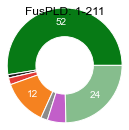

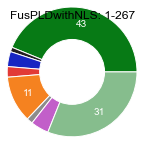

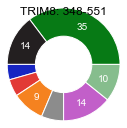

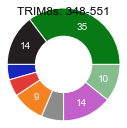

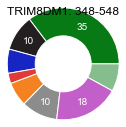

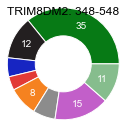

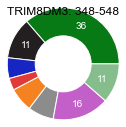

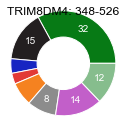

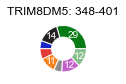

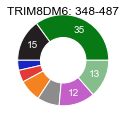

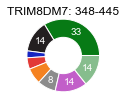

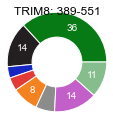

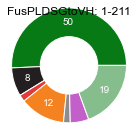

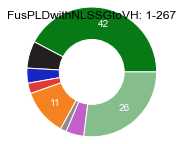

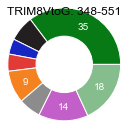

In [30]:
# Kiersten's colors
#aatypecolors=['#1f8241','#231f20','#189bd7','#e23a36','#f58220','#8c8c8c','#7c2880','#d865a6']
# Matt's colors
aatypecolors=['#077a15','#231f20','#1725c2','#e23a36','#f58220','#8c8c8c','#c25fc9','#86bd8d']

## Pick which IDR you want to consider ##
#whichseqs=['ARID1A: 1-1011']
#whichseqs=['SMARCA2: 1-344', 'SMARCA2: 508-594', 'SMARCA2: 631-726', 'SMARCA2: 1165-1258', 'SMARCA2: 1327-1411', 'SMARCA2: 1494-1590', 'SMARCA4: 1-368', 'SMARCA4: 532-617', 'SMARCA4: 653-756', 'SMARCA4: 1195-1321', 'SMARCA4: 1390-1454', 'SMARCA4: 1569-1647']
#whichseqs=['ARID1A: 1-1011','ARID1B: 1-1047']
whichseqs=subgenes


for s in range(0,len(whichseqs)):
    whichseq=whichseqs[s]
    whichseqpos=subgenes.index(whichseq)
    currseq=subseqs[whichseqpos]
    currlen=len(currseq)
    
    SeqOb = SequenceParameters(currseq)
    aafrac=SeqOb.get_amino_acid_fractions()
    print(aafrac)

    frac8types=[]
    frac8types.append(aafrac['C']+aafrac['H']+aafrac['N']+aafrac['Q']+aafrac['S']+aafrac['T'])
    frac8types.append(aafrac['I']+aafrac['L']+aafrac['M']+aafrac['V'])
    frac8types.append(aafrac['K']+aafrac['R'])
    frac8types.append(aafrac['D']+aafrac['E'])
    frac8types.append(aafrac['F']+aafrac['W']+aafrac['Y'])
    frac8types.append(aafrac['A'])
    frac8types.append(aafrac['P'])
    frac8types.append(aafrac['G'])
    
    print(sum(frac8types))
    
    def my_autopct(pct):
        return ('%i' % round(pct,2)) if pct > 8 else ''
    
    plt.figure(figsize=(math.log10(currlen/5),math.log10(currlen/5)))
    ax = plt.subplot(111)
    #ax.pie(frac8types, colors=aatypecolors, wedgeprops={"edgecolor":"black",'linewidth': 1, 'antialiased': True},radius=math.log10(currlen/5))#,labels=typeall)
    ## Make it a donut plot rather than pie plot
    ax.pie(frac8types, colors=aatypecolors, autopct=my_autopct, pctdistance=0.75, textprops={'color':"w"}, wedgeprops={"edgecolor":"white",'linewidth': 1, 'antialiased': True},radius=math.log10(currlen/5))#,labels=typeall)
    my_circle=plt.Circle((0,0),0.5*math.log10(currlen/5),color='white',edgecolor='black')
    p=plt.gcf()
    p.gca().add_artist(my_circle)
    
    plt.title(whichseq)
    
    whichsequnderscore=whichseq.replace(": ", "_")
    
    #plt.savefig('figures/compositional_pie_charts/'+mainprotein+'/'+whichsequnderscore+"_compositional_donut_chart_8_types.pdf", transparent=True, bbox_inches = "tight")

### 3.4.2 - Pie Charts of Sequence Composition each individual amino acid

{'A': 0.018957345971563982, 'C': 0.0, 'D': 0.018957345971563982, 'E': 0.0, 'F': 0.0, 'G': 0.24644549763033174, 'H': 0.0, 'I': 0.0, 'K': 0.0, 'L': 0.0, 'M': 0.009478672985781991, 'N': 0.03317535545023697, 'P': 0.052132701421800945, 'Q': 0.2037914691943128, 'R': 0.0, 'S': 0.24170616113744076, 'T': 0.04739336492890995, 'V': 0.0, 'W': 0.0, 'Y': 0.12796208530805686}
0.9999999999999999
{'A': 0.0149812734082397, 'C': 0.0, 'D': 0.02247191011235955, 'E': 0.003745318352059925, 'F': 0.00749063670411985, 'G': 0.31086142322097376, 'H': 0.0, 'I': 0.0, 'K': 0.003745318352059925, 'L': 0.0, 'M': 0.011235955056179775, 'N': 0.033707865168539325, 'P': 0.0449438202247191, 'Q': 0.16104868913857678, 'R': 0.033707865168539325, 'S': 0.20599250936329588, 'T': 0.03745318352059925, 'V': 0.0, 'W': 0.0, 'Y': 0.10861423220973783}
1.0
{'A': 0.06372549019607843, 'C': 0.024509803921568627, 'D': 0.0196078431372549, 'E': 0.029411764705882353, 'F': 0.03431372549019608, 'G': 0.10784313725490197, 'H': 0.04411764705882353, '

/project/engineering/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.


{'A': 0.06467661691542288, 'C': 0.029850746268656716, 'D': 0.004975124378109453, 'E': 0.03482587064676617, 'F': 0.03482587064676617, 'G': 0.11442786069651742, 'H': 0.03482587064676617, 'I': 0.009950248756218905, 'K': 0.014925373134328358, 'L': 0.04975124378109453, 'M': 0.009950248756218905, 'N': 0.01990049751243781, 'P': 0.15920398009950248, 'Q': 0.05970149253731343, 'R': 0.03980099502487562, 'S': 0.14925373134328357, 'T': 0.06467661691542288, 'V': 0.05472636815920398, 'W': 0.009950248756218905, 'Y': 0.03980099502487562}
1.0
{'A': 0.07462686567164178, 'C': 0.03482587064676617, 'D': 0.004975124378109453, 'E': 0.029850746268656716, 'F': 0.03482587064676617, 'G': 0.11442786069651742, 'H': 0.03482587064676617, 'I': 0.009950248756218905, 'K': 0.014925373134328358, 'L': 0.04975124378109453, 'M': 0.009950248756218905, 'N': 0.01990049751243781, 'P': 0.16417910447761194, 'Q': 0.05970149253731343, 'R': 0.04477611940298507, 'S': 0.14427860696517414, 'T': 0.06965174129353234, 'V': 0.04975124378109

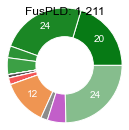

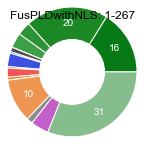

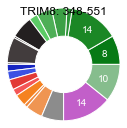

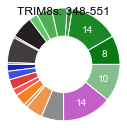

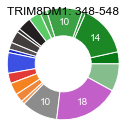

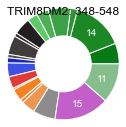

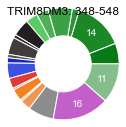

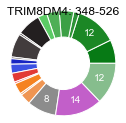

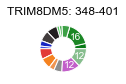

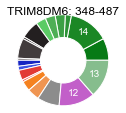

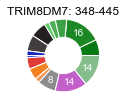

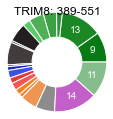

In [71]:
# Kiersten's colors
#aatypecolors=['#1f8241','#231f20','#189bd7','#e23a36','#f58220','#8c8c8c','#7c2880','#d865a6']
# Matt's colors
aatypecolors=['#077a15','#231f20','#1725c2','#e23a36','#f58220','#8c8c8c','#c25fc9','#86bd8d']

## Pick which IDR you want to consider ##
#whichseqs=['ARID1A: 1-1011']
#whichseqs=['SMARCA2: 1-344', 'SMARCA2: 508-594', 'SMARCA2: 631-726', 'SMARCA2: 1165-1258', 'SMARCA2: 1327-1411', 'SMARCA2: 1494-1590', 'SMARCA4: 1-368', 'SMARCA4: 532-617', 'SMARCA4: 653-756', 'SMARCA4: 1195-1321', 'SMARCA4: 1390-1454', 'SMARCA4: 1569-1647']
#whichseqs=['ARID1A: 1-1011','ARID1B: 1-1047']
whichseqs=subgenes

aas=['Q','S','N','T','H','C','L','I','V','M','K','R','E','D','F','W','Y','A','P','G']
aaindvidcolors=['#077a15','#1b8725','#2c9336','#3ca045','#4eaf56','#5bcb65','#231f20','#2d2829','#423c3d','#544d4f','#1725c2','#3c51e3','#e23a36','#f45656','#f58220','#ef873a','#ef9552','#8c8c8c','#c25fc9','#86bd8d']


for s in range(0,len(whichseqs)):
    whichseq=whichseqs[s]
    whichseqpos=subgenes.index(whichseq)
    currseq=subseqs[whichseqpos]
    currlen=len(currseq)
    
    SeqOb = SequenceParameters(currseq)
    aafrac=SeqOb.get_amino_acid_fractions()
    print(aafrac)

    frac8types=[]
    for a in range(0,len(aas)):
        frac8types.append(aafrac[aas[a]])

    print(sum(frac8types))
    
    def my_autopct(pct):
        return ('%i' % round(pct,2)) if pct > 8 else ''
        
    plt.figure(figsize=(math.log10(currlen/5),math.log10(currlen/5)))
    ax = plt.subplot(111)
    #ax.pie(frac8types, colors=aatypecolors, wedgeprops={"edgecolor":"black",'linewidth': 1, 'antialiased': True},radius=math.log10(currlen/5))#,labels=typeall)
    ## Make it a donut plot rather than pie plot
    ax.pie(frac8types, colors=aaindvidcolors, autopct=my_autopct, pctdistance=0.75, textprops={'color':"w"}, wedgeprops={"edgecolor":"white",'linewidth': 1, 'antialiased': True},radius=math.log10(currlen/5))
    my_circle=plt.Circle((0,0),0.5*math.log10(currlen/5),color='white',edgecolor='black')
    p=plt.gcf()
    p.gca().add_artist(my_circle)
    
    plt.title(whichseq)
    
    whichsequnderscore=whichseq.replace(": ", "_")
    
    #plt.savefig('figures/compositional_pie_charts/'+mainprotein+'/'+whichsequnderscore+"_compositional_donut_chart_20_aas.pdf", transparent=True, bbox_inches = "tight")

# Part 4: Analzye all sequence features

## 4.1 Combine compositional and patterning features

In [12]:
# for just features that exist in the subset
myfullfeats=mycompfeats+mypattfeats
#print(myfullfeats)

subzveccomppatt=np.zeros((len(subseqs),len(myfullfeats)))

for s in range(0,len(subseqs)):
    subzveccomppatt[s,:]=np.append(subzveccomp[s,:],subzvecpatt[s,:])
    
# for all 90 features regardless of whether they exist in subset
# this is used for mapping to a specific IDR cluster
myfullfeats_all=mypattfeats_all+mycompfeats_all_no_WPatch
print(myfullfeats_all)
print(len(myfullfeats_all))

subzvecpattcomp_all=np.zeros((len(subseqs),len(myfullfeats_all)))

for s in range(0,len(subseqs)):
    subzvecpattcomp_all[s,:]=np.append(subzvecpatt_all[s,:],subzveccomp_all[s,:])

print(subzvecpattcomp_all[0,:])

['pol-pol', 'pol-hyd', 'pol-pos', 'pol-neg', 'pol-aro', 'pol-ala', 'pol-pro', 'pol-gly', 'hyd-hyd', 'hyd-pos', 'hyd-neg', 'hyd-aro', 'hyd-ala', 'hyd-pro', 'hyd-gly', 'pos-pos', 'pos-neg', 'pos-aro', 'pos-ala', 'pos-pro', 'pos-gly', 'neg-neg', 'neg-aro', 'neg-ala', 'neg-pro', 'neg-gly', 'aro-aro', 'aro-ala', 'aro-pro', 'aro-gly', 'ala-ala', 'ala-pro', 'ala-gly', 'pro-pro', 'pro-gly', 'gly-gly', 'Frac A', 'Frac C', 'Frac D', 'Frac E', 'Frac F', 'Frac G', 'Frac H', 'Frac I', 'Frac K', 'Frac L', 'Frac M', 'Frac N', 'Frac P', 'Frac Q', 'Frac R', 'Frac S', 'Frac T', 'Frac V', 'Frac W', 'Frac Y', 'Frac K+R', 'Frac D+E', 'Frac Polar', 'Frac Aliphatic', 'Frac Aromatic', 'R/K Ratio', 'E/D Ratio', 'Frac Chain Expanding', 'FCR', 'NCPR', 'Hydrophobicity', 'Disorder Promoting', 'Iso point', 'PPII', 'A Patch', 'C Patch', 'D Patch', 'E Patch', 'F Patch', 'G Patch', 'H Patch', 'I Patch', 'K Patch', 'L Patch', 'M Patch', 'N Patch', 'P Patch', 'Q Patch', 'R Patch', 'S Patch', 'T Patch', 'V Patch', 'Y Pat

## 4.2 Save all z-score values to excel file

In [13]:
df1=pd.DataFrame(subzvecpattcomp_all,columns=myfullfeats_all)
df2=pd.DataFrame()
df2['Genes']=subgenes
df3=pd.DataFrame()
df3['Uniprot']=subaccs
df4=pd.DataFrame()
df4['Sequence']=subseqs
df5=pd.DataFrame()
df5['Start Pos']=substpos
df6=pd.DataFrame()
df6['End Pos']=subenpos

dfcomppatt = pd.concat([df2, df3, df5, df6, df4, df1], axis=1)
print(dfcomppatt)

dfcomppatt.to_excel('excel_zscore_files/'+mainprotein+'_patterning_compositional_feature_zscores.xlsx') 

print(dfcomppatt['neg-neg'])
print(dfcomppatt['Q Patch'])
print(dfcomppatt['R/K Ratio'])

                            Genes                        Uniprot  Start Pos  \
0                    Mus musculus                   Mus musculus          0   
1                 Cavia porcellus                Cavia porcellus          0   
2                   Octodon degus                  Octodon degus          0   
3           Heterocephalus glaber          Heterocephalus glaber          0   
4              Lipotes vexillifer             Lipotes vexillifer          0   
5           Monodelphis domestica          Monodelphis domestica          0   
6             Pelodiscus sinensis            Pelodiscus sinensis          0   
7           Elephantulus edwardii          Elephantulus edwardii          0   
8                Vombatus ursinus               Vombatus ursinus          0   
9          Apostichopus japonicus         Apostichopus japonicus          0   
10       Capricornis sumatraensis       Capricornis sumatraensis          0   
11         Phascolarctos cinereus         Phascolarc

## 4.3 Different full features specific analyses you may want to run

### 4.3.0 - Plot clustered z-score heatmap on only subset of IDRs

ARID1A: 1-1011
ARID1B: 1-1047
     Frac A    Frac C    Frac D    Frac E    Frac F    Frac G    Frac H  \
0  0.594097 -0.447443 -0.829630 -1.026710 -0.359559  1.067773 -0.125546   
1  0.875323 -0.321802 -0.820555 -1.023602 -0.266909  1.339962  0.548512   

     Frac I    Frac K    Frac L  ...   hyd-hyd   hyd-ala   hyd-pro   hyd-gly  \
0 -0.252012 -0.749293 -0.717527  ... -0.529771  3.934862  1.272671  2.585705   
1 -0.370618 -0.743806 -0.613851  ...  1.554767  7.225544 -0.492267  5.812341   

    ala-ala   ala-pro   ala-gly   pro-pro   pro-gly   gly-gly  
0  1.626234  7.310981  8.580255  1.378688  4.087700  4.089441  
1  3.980412  9.012591  8.245163  0.577401  5.445974  3.829340  

[2 rows x 64 columns]
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  backgroundcolor: color
  bbox: dict with properties for `.patches.FancyB

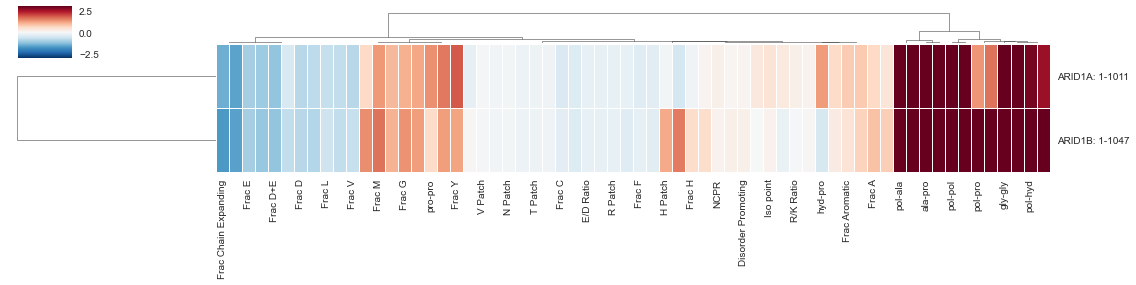

In [17]:
sublist=['ARID1A: 1-1011', 'ARID1B: 1-1047']
#sublist=['SIGLEC: 537-626', '2B4: 251-370']

tmpidx=[]
tmpgenes=[]
for s in sublist:
    tmpidx.append(subgenes.index(s))
    tmpgenes.append(subgenes[subgenes.index(s)])
    print(subgenes[subgenes.index(s)])
    

myfeat=['pol-pol','pol-hyd','pol-pos','pol-neg','pol-aro','pol-ala','pol-pro','pol-gly','hyd-hyd','hyd-pos','hyd-neg','hyd-aro','hyd-ala','hyd-pro','hyd-gly','pos-pos','pos-neg','pos-aro','pos-ala','pos-pro','pos-gly','neg-neg','neg-aro','neg-ala','neg-pro','neg-gly','aro-aro','aro-ala','aro-pro','aro-gly','ala-ala','ala-pro','ala-gly','pro-pro','pro-gly','gly-gly','Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','Y Patch','RG Frac']

df2 = pd.DataFrame(subzveccomppatt[tmpidx,:], columns=myfullfeats)
df2 = df2.loc[:, (df2 != 0).any(axis=0)] # remove features with all zeros
#df2 = df2.loc[:, df2.std() > 0.1]
print(df2)
#hi

#clust_map = sbn.clustermap(df2, metric="euclidean", method="ward",cmap='RdBu_r',figsize=(30, 30),vmin=-3,vmax=3) 
clust_map = sbn.clustermap(df2, metric="euclidean", method="ward",cmap='RdBu_r',figsize=(15, 4),vmin=-3,vmax=3,linewidth=0.5) 

rowindex=clust_map.dendrogram_row.reordered_ind
#print(rowindex)

ylabellist=[]
for r in rowindex:
    ylabellist.append(tmpgenes[r])

plt.setp(clust_map.ax_heatmap.get_yticklabels(),rotation=0)
plt.setp(clust_map.ax_heatmap.set_yticklabels(ylabellist))

colindex=clust_map.dendrogram_col.reordered_ind
#print(colindex)

clusters = scipy.cluster.hierarchy.fcluster(clust_map.dendrogram_row.linkage, 30, 'distance')
print(clusters)
numclust=max(clusters)


#plt.savefig("figures/clustered_zscore_heatmaps/"+mainprotein+"_clustered_sequence_features_IDRs_gte_30_subset.pdf", transparent=True, bbox_inches = "tight") 


### 4.3.1 - Plot clustered z-score heatmap

      Frac A    Frac C    Frac D    Frac E    Frac F    Frac G    Frac H  \
0  -0.425614 -0.582363 -0.146766 -0.629530  0.726095 -0.227188  5.432612   
1  -0.877550  0.022980 -0.237297 -0.375644  0.029556 -0.390602  4.996335   
2  -1.131449 -0.179596 -0.381427 -0.584626  0.083576 -0.647145  4.192528   
3  -0.980680 -0.433775 -0.237918 -0.240627  0.055439  0.132228  8.796310   
4  -0.374914 -0.388056  0.068701 -0.454678  0.965369 -0.011404  6.135007   
5  -1.077440  0.055038 -0.784454 -0.089790  0.778635  0.466096  0.518464   
6  -1.034119 -0.582363 -0.981022 -0.246485 -0.807099  0.695176 -0.464225   
7  -0.446155 -0.280585 -0.701827 -0.888275 -0.056331 -0.703485  1.255345   
8   0.563196  4.947525  0.392166 -0.744516 -0.042804 -0.910407  0.633992   
9  -0.700859  0.086283 -0.526381  0.266802  1.410855 -0.713306  0.226791   
10 -0.109809  0.635529 -0.374657 -0.280379  0.202862 -0.769927  1.437485   
11  0.040966  0.624751 -0.595306 -0.688809 -0.807099 -0.918143  1.417247   
12  0.308756

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  backgroundcolor: color
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `.Bbox`
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: color
  figure: `.Figure`
  fontfamily or family: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 'semi-expanded', 'expanded', 'extra-expanded', 'ultra-expanded'}
  fontstyle or style: {'normal', 'italic', 'oblique'}
  fontvariant or var

meta NOT subset; don't know how to subset; dropped


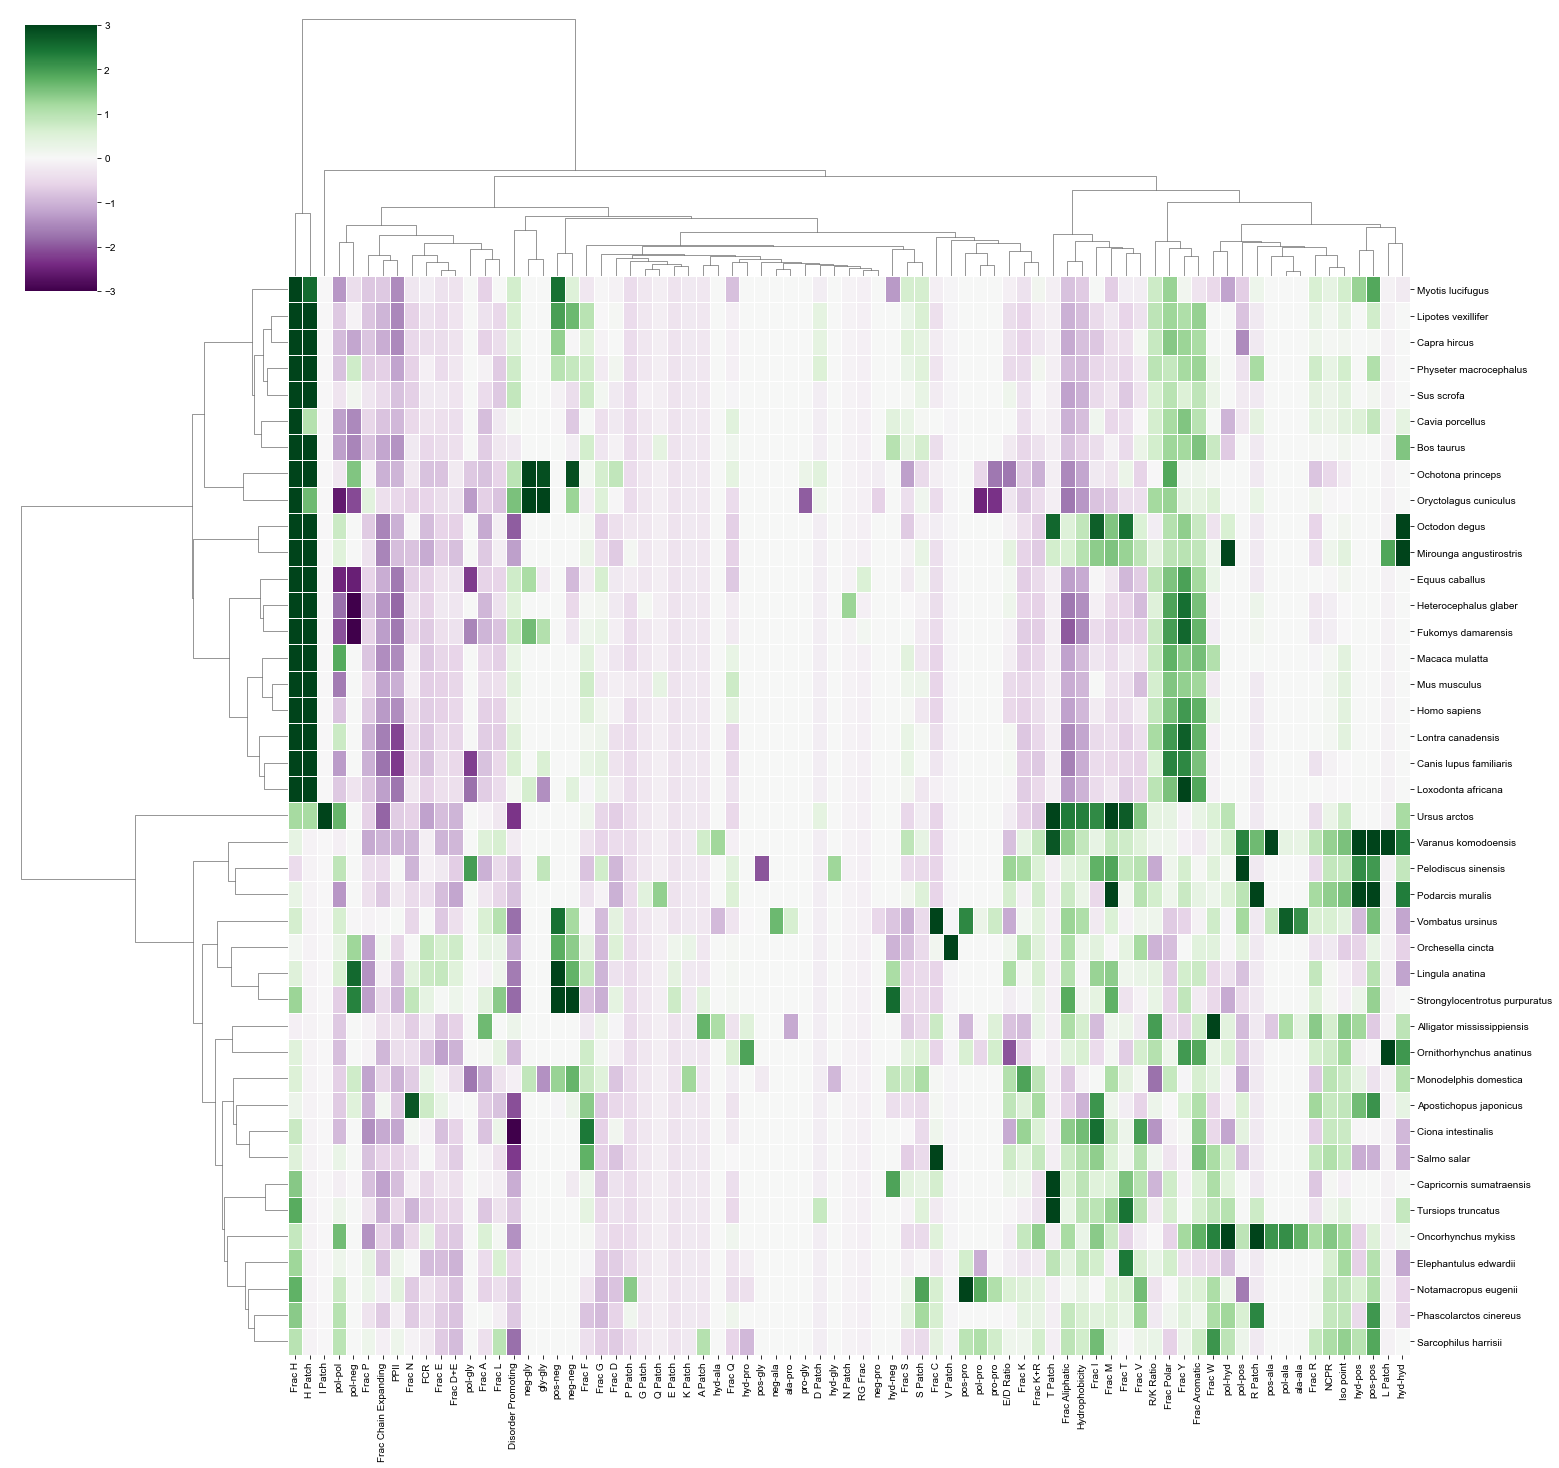

In [40]:
df2 = pd.DataFrame(subzveccomppatt, columns=myfullfeats)
#df2 = df2.loc[:, df2.std() > 0.1]
print(df2)
#hi

#clust_map = sbn.clustermap(df2, metric="euclidean", method="ward",cmap='RdBu_r',figsize=(30, 30),vmin=-3,vmax=3) 
#clust_map = sbn.clustermap(df2, metric="euclidean", method="ward",cmap='RdBu_r',figsize=(20, len(subaccs)/2),vmin=-3,vmax=3) 
clust_map = sbn.clustermap(df2, metric="euclidean", method="ward",cmap='PRGn',figsize=(20, len(subaccs)/2),vmin=-3,vmax=3,linewidth=0.5) 


rowindex=clust_map.dendrogram_row.reordered_ind
#print(rowindex)

ylabellist=[]
for r in rowindex:
    ylabellist.append(subgenes[r])

plt.setp(clust_map.ax_heatmap.get_yticklabels(),rotation=0)
plt.setp(clust_map.ax_heatmap.set_yticklabels(ylabellist))

colindex=clust_map.dendrogram_col.reordered_ind
#print(colindex)

clusters = scipy.cluster.hierarchy.fcluster(clust_map.dendrogram_row.linkage, 20, 'distance')
print(clusters)
numclust=max(clusters)
print(numclust)


plt.savefig("figures/clustered_zscore_heatmaps/"+mainprotein+"_clustered_sequence_features_IDRs_gte_30.pdf", transparent=True, bbox_inches = "tight") 


### 4.3.2 - Get clusters - must run 4.3.1 first

In [51]:
genelistclust=[]
listclust=[]
acclistbyclust=[]
for c in range(1,numclust+1):
    print('Cluster_'+str(c))
    pos=[i for i, ltr in enumerate(clusters) if ltr == c]
    print(pos)

    acclist=[]
    seqlist=[]
    genelist=[]
    for p in pos: 
        acclist.append(subaccs[p])
        seqlist.append(subseqs[p])
        genelist.append(subgenes[p])
        genelistclust.append(subgenes[p])
        listclust.append(c)
        #print(p)
        print(subaccs[p])
        print(subgenes[p])
        print(subseqs[p])
    
    currdf=pd.DataFrame()
    currdf['Gene']=genelist
    currdf['Uniprot']=acclist
    currdf['Sequences']=seqlist
    
    acclistbyclust.append(genelist)
    
    #if c==1:
    #    with pd.ExcelWriter('nucleolar_IDR_clusters.xlsx') as writer:  
    #        currdf.to_excel(writer, sheet_name='cluster_'+str(c))
    #else:
    #    with pd.ExcelWriter('nucleolar_IDR_clusters.xlsx',engine="openpyxl",mode='a') as writer:  
    #        currdf.to_excel(writer, sheet_name='cluster_'+str(c))
    
dfc = pd.DataFrame()
dfc['Gene']=genelistclust
dfc['Cluster']=listclust
#dfc.to_excel("BAF_29_IDR_by_Cluster.xlsx")
print(dfc)

Cluster_1
[0, 1, 2]
Q9NX58
LYAR: 140-310
ASNSEPVNKEQDQRPLHPVANPHAEISTKVPASKVKDAVEQQGEVKKNKRERKEERQKKRKREKKELKLENHQENSRNQKPKKRKKGQEADLEAGGEEVPEANGSAGKRSKKKKQRKDSASEEEAHVGAGKRKRRHSEVETDSKKKKMKLPEHPEGGEPEDDEAPAKGKFN
Q9NX58
LYAR well-mixed: 140-310
ASNSRPVNERQDQRPLHPVANPHARISTEVPASKVEKAVEQQGKVEKNKDKEREKEQKEKEKDKEKLELKNHQENSRNQKPKKEKKGQDAKLEAGGKEVPKANGSAGDRSKEKKQRKDSASKEKAHVGAGKERERHSEVRTESKKDKMKLPEHPRGGEPKEREAPAKGEFN
Q9NX58
LYAR blocky: 140-310
ASNSKPVNRKQRQRPLHPVANPHAKISTEVPASEVEDAVEQQGRVKKNKKKDEEEEQKKKKKKEDDLELDNHQKNSKNQRPRKREEGQEAELEAGGKKVPRANGSAGKRSKEEEQEEKSASKRKAHVGAGKKDEEHSEVETRSKKKRMKLPDHPEGGEPEKKKAPARGKFN
                       Gene  Cluster
0             LYAR: 140-310        1
1  LYAR well-mixed: 140-310        1
2      LYAR blocky: 140-310        1


### 4.3.3 - Sorted z-score map of a given sequence

LYAR: 140-310
LYAR blocky: 140-310
LYAR well-mixed: 140-310
['R/K Ratio', 'Hydrophobicity', 'PPII', 'E Patch', 'K Patch', 'pol-pol', 'pol-pos', 'pol-neg', 'pos-pos', 'pos-neg', 'neg-neg']
    LYAR: 140-310  LYAR blocky: 140-310  LYAR well-mixed: 140-310
0       -1.099618             -1.099618                 -1.099618
1       -1.885001             -1.885001                 -1.885001
2        0.384107              0.384107                  0.384107
3        0.666346              1.850471                  0.497185
4        3.688741              1.833602                  4.384418
5        0.689919              0.689919                  0.689919
6        3.127059              1.150601                 -0.303383
7        0.068209              2.451184                 -0.221772
8        5.712057              3.622194                 -1.794099
9        5.766303              5.578108                 -3.460275
10       0.984837              4.530906                 -2.646193
   Sequence Features

meta NOT subset; don't know how to subset; dropped


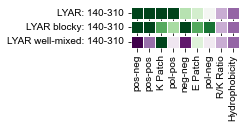

In [52]:
#sublist=['ARID1A: 1-1011', 'ARID1B: 1-1047','SS18: 71-418','SS18L1: 71-396']
#sublist=['ARID1A: 1-1011']
#sublist=['SIGLEC: 537-626', '2B4: 251-370']
#sublist=['TRIM8: 348-551', 'TRIM8s: 348-551', 'TRIM8: 389-551', 'TRIM8DM1: 348-548', 'TRIM8DM2: 348-548', 'TRIM8DM3: 348-548', 'TRIM8DM4: 348-526', 'TRIM8DM5: 348-401', 'TRIM8DM6: 348-487', 'TRIM8DM7: 348-445','FusPLD: 1-211', 'FusPLDwithNLS: 1-267']
#sublist=['PFN1: 1-140','Barnase: 1-110']
#sublist=['TRIM8: 348-551','TRIM8s: 348-551','TRIM8VtoG: 348-551','FusPLDSGtoVH: 1-211', 'FusPLDwithNLSSGtoVH: 1-267','FusPLD: 1-211', 'FusPLDwithNLS: 1-267']
#sublist=['YAP1: 249-472','YAP1: 1-155','MED1: 518-1575','POLR2A: 1546-1970']
#sublist=['CD28: 180-220']
#sublist=['FUS 2XPLD 48 Tyr, 70 Gly, and 90 Ser: 1-173','BRG1 PLD Aro++: 1-2']
#sublist=['LAT: 48-233','PD1: 194-288']
#sublist=['PD1: 192-288','CTLA4: 183-223','CD28: 180-220']
#sublist=['FUSPLD: 1-173','FUSPLD (6S/T to E): 1-173','FUSPLD (12S/T to E): 1-173','FUSPLD: 1-173','BRG1 PLD Aro+: 1-2','BRG1 PLD Aro++: 1-2','FUSPLD: 1-173','FOXG1N-IDR: 1-181','FOXG1N-IDR Aro + (12 G/A to Y): 1-181','FOXG1N-IDR Aro ++ (19 G/A/S to Y): 1-181']
#sublist=['SS18 C PLD: 247-418','FUS PLD: 1-173']
#sublist=['SS18 PLD: 67-418', 'ARID1A PLD: 79-601', 'ARID1B PLD: 314-716','BRG1 PLD: 1-340']
#sublist=['SS18 N PLD: 67-246', 'SS18L1 N PLD: 67-228']
#sublist=['SS18 PLD: 67-418','SS18L1 PLD: 68-396','SS18 N PLD:FUS PLD: 67-419']
#sublist=['SS18 C PLD: 247-418','SS18L1 C PLD: 229-396', 'FUS PLD: 1-173']
#sublist=['SS18 N PLD: 67-246', 'SS18 C PLD: 247-418']
#sublist=['SRSF1: 194-248','SRSF2: 93-221','SRSF3: 82-164','SRSF4: 176-494','SRSF5: 179-272','SRSF6: 184-344','SRSF7: 118-238','SRSF8: 93-282','SRSF9: 188-221','SRSF10: 96-262','SRSF11: 126-484','SRSF12: 97-261']
#sublist=['TANGO1 WT IDR: 145-925','TANGO1 well-mixed pol-neg: 145-925','TANGO1 extra blocky pol-neg: 145-925','TANGO1 E to D: 145-925','TANGO1 D to E: 145-925','TANGO1 F to S: 145-925','TANGO1 scramble both conserved regions: 145-925','TANGO1 scramble conserved region 1: 145-925','TANGO1 scramble conserved region 2: 145-925']
#sublist=['ARID1A: 1-1011', 'ARID1B: 1-1047']
#sublist=['SMARCA4: 1-368', 'SMARCA2: 1-344']
#sublist=['SMARCC1: 947-1105', 'SMARCC2: 947-1214']
#sublist=['BRD2: 449-798', 'BRD2 KRDES Scram1: 449-798', 'BRD4: 684-924']
#sublist=['BRD2: 449-629', 'BRD2wellmixed: 449-629','BRD4s: 447-600', 'BRD4l: 684-874']
#sublist=['BRD2: 749-798','BRD2wellmixed: 749-798','BRD4s: 684-723','BRD4l: 875-924']
#sublist=['ARID1APLD: 1-2','ARID1BPLD: 1-2','SS18PLD: 1-2']
#sublist=['FUSPLD-24Y: 1-2','TAF15PLD: 1-2','EWSR1PLD: 1-2']
#sublist=['ARID1A WT: 1-970','ARID1A 42YS: 1-970','ARID1A AQG scramble: 1-970']
sublist=['LYAR: 140-310','LYAR blocky: 140-310','LYAR well-mixed: 140-310']



tmpidx=[]
tmpgenes=[]
for s in sublist:
    tmpidx.append(subgenes.index(s))
    tmpgenes.append(subgenes[subgenes.index(s)])
    print(subgenes[subgenes.index(s)])

dffeature = pd.DataFrame(myfullfeats,columns =['Sequence Features'])
print(myfullfeats)
dftmp=pd.DataFrame()
for s in range(0,len(tmpgenes)):
    dftmp[tmpgenes[s]]=subzveccomppatt[tmpidx[s],:]
    
print(dftmp)

dfr = pd.concat([dffeature, dftmp], axis=1)

## Only save features that at least one idr has a z-score > 0 ##
#tmp=(dfr.select_dtypes(include=['number']) != 0).any(1)
tmp=(abs(dfr.select_dtypes(include=['number'])) > 1).any(1)
dfr= dfr.loc[tmp==True]
print(dfr)


final_dfr = dfr.sort_values(by=[sublist[0]], ascending=False) # sorting by the first gene in your sublist
#final_dfr = dfr
print(final_dfr)

final_dfr2=final_dfr;
mygroup=final_dfr2.pop('Sequence Features')


if len(sublist)>1:
    f,axs = plt.subplots(len(sublist),1,sharex=True,figsize = (12, len(sublist)/4))
    for i in range(0,len(sublist)):
        sbn.heatmap(final_dfr2[[sublist[i]]].T,cmap="PRGn",cbar=False,ax=axs[i],vmin=-3,vmax=3,square=True,linewidth=0.5)
        axs[i].tick_params(labelrotation=0)
else:
    f,ax1 = plt.subplots(1,1,sharex=True,figsize = (12, 1))
    g1 = sbn.heatmap(final_dfr2[[sublist[0]]].T,cmap="PRGn",cbar=True,ax=ax1,vmin=-3,vmax=3,square=True,linewidth=0.5)

plt.xticks(np.arange(0.5, len(mygroup), 1), mygroup,rotation=90) 

plt.savefig("figures/sorted_zscore_heatmaps/"+mainprotein+"/"+mainprotein+"_sorted_sequence_features_IDRs_gte_30_by_"+sublist[0]+".pdf", transparent=True, bbox_inches = "tight") 


# Part 5: Get cluster of each IDR

## 5.1 - Load in cluster information

In [31]:
# load in clusters for all human IDRs
tmpdf=pd.read_excel('IDR_data_by_species/All_sapiens_IDRs_clustermap_using_centroids.xlsx')


# only using the IDRs 100-300 information since this is what was used to create the clusters
tmpdf=tmpdf[tmpdf['IDR Length']>=100]
tmpdf=tmpdf[tmpdf['IDR Length']<=300]

print(tmpdf)

# Get z-scores of only the IDRs between 100-300
genewnum100to300=tmpdf['Gene'].tolist()
clusternum100to300=tmpdf['Cluster Number'].tolist()
accswnum100to300=tmpdf['Uniprot w IDRnum'].tolist()



       Unnamed: 0 Uniprot Uniprot w IDRnum          Gene  Cluster Number  \
8               8  Q5MIZ7         Q5MIZ7_1  PPP4R3B IDR1              18   
12             12  Q9NQ76         Q9NQ76_1     MEPE IDR1               4   
15             15  Q9NQ76         Q9NQ76_4     MEPE IDR4               4   
17             17  Q5H9L2         Q5H9L2_1   TCEAL5 IDR1              19   
18             18  P20930         P20930_1      FLG IDR1              26   
...           ...     ...              ...           ...             ...   
24472       24472  Q8TAQ2         Q8TAQ2_4  SMARCC2 IDR4              11   
24475       24475  Q9H1J1         Q9H1J1_2    UPF3A IDR2              23   
24479       24479  Q9NZV7         Q9NZV7_1     ZIM2 IDR1               3   
24494       24494  Q9P244         Q9P244_2    LRFN1 IDR2               5   
24503       24503  Q7Z739         Q7Z739_2   YTHDF3 IDR2              11   

       IDR Length  Start Pos  End Pos  Full Protein Length  \
8             140        

## 5.2 - Load in z-score information

In [32]:
# make sure features match
myfeat=['pol-pol','pol-hyd','pol-pos','pol-neg','pol-aro','pol-ala','pol-pro','pol-gly','hyd-hyd','hyd-pos','hyd-neg','hyd-aro','hyd-ala','hyd-pro','hyd-gly','pos-pos','pos-neg','pos-aro','pos-ala','pos-pro','pos-gly','neg-neg','neg-aro','neg-ala','neg-pro','neg-gly','aro-aro','aro-ala','aro-pro','aro-gly','ala-ala','ala-pro','ala-gly','pro-pro','pro-gly','gly-gly','Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','Y Patch','RG Frac']
print(myfeat==myfullfeats_all)

# Load in z-scores for all human IDRs
zvecall=np.load('IDR_data_by_species/sapiens_full_idrome_gte_30_nardini_compositional_RtoK.npy')
print(zvecall.shape)

# Load in human accessions
myfile = open('disorder/min_length_30/sapiens', 'r')
Lines = myfile.readlines()

sapiensfullaccswnums=[]
count=0
for line in Lines:
    count=count+1
    fullline=line.split(" ")
    tmpseq=fullline[3]
    tmpacc=fullline[0]
    currseq=tmpseq.strip('\n')
    
    if len(currseq)>=30 and "X" not in currseq and "U" not in currseq and "Z" not in currseq and "J" not in currseq and "B" not in currseq and "O" not in currseq:
        sapiensfullaccswnums.append(tmpacc)

zvec100to300=np.zeros((len(genewnum100to300),len(myfeat)))
for s in range(0,len(genewnum100to300)):
    idx=sapiensfullaccswnums.index(accswnum100to300[s])
    zvec100to300[s,:]=zvecall[idx,:]
    
print(zvec100to300.shape)

True
(24508, 90)
(4529, 90)


## 5.3 - Create z-score arrays that set values to cutoff if below or above

In [33]:
cutoff=3

zvec100to300wcutoff=zvec100to300.copy()
for z in range(0,len(zvec100to300wcutoff)):
    pos=[i for i, ltr in enumerate(zvec100to300wcutoff[z,:]) if ltr > cutoff]
    zvec100to300wcutoff[z,pos]=cutoff
    pos=[i for i, ltr in enumerate(zvec100to300wcutoff[z,:]) if ltr < -cutoff]
    zvec100to300wcutoff[z,pos]=-cutoff
    
subzvecpattcomp_all_wcutoff=subzvecpattcomp_all.copy()
for z in range(0,len(subzvecpattcomp_all_wcutoff)):
    pos=[i for i, ltr in enumerate(subzvecpattcomp_all_wcutoff[z,:]) if ltr > cutoff]
    subzvecpattcomp_all_wcutoff[z,pos]=cutoff
    pos=[i for i, ltr in enumerate(subzvecpattcomp_all_wcutoff[z,:]) if ltr < -cutoff]
    subzvecpattcomp_all_wcutoff[z,pos]=-cutoff

## 5.4 - Get centroids of each cluster

     pol-pol   pol-hyd   pol-pos   pol-neg   pol-aro   pol-ala   pol-pro  \
0   1.360355  0.121380  0.990304  0.526880  0.000000  0.254692  0.501371   
1   1.333398  0.274662  0.082700  0.135038  0.004712  0.213665  2.227871   
2   0.855241  0.205816  0.397648  1.445373  0.024240  0.296558  1.453464   
3   1.293049  0.588644  0.313615  2.002541  0.000000  0.102966  0.153226   
4   0.140594  0.331159  0.295351 -0.011011  0.000000  0.004634  0.023093   
5   0.864581  0.114071  1.763796  1.320950  0.000000  0.906537  0.868103   
6   0.508113  0.237453  0.132702  0.095649  0.008700  0.050611  0.266790   
7   0.970049  0.111254  0.093043  2.229279  0.001900 -0.019457 -0.001368   
8   0.954341  0.400294  0.285754  2.184392  0.000000  1.378450  0.456683   
9  -0.180437 -0.223715  0.407271  0.665479 -0.001968  0.005051 -0.011638   
10 -0.306647 -0.908560 -0.043481 -0.004763  0.000000 -0.012085 -0.389368   
11  1.323698  0.885064  0.038629  0.062651  0.022205  0.368011  0.976948   
12  1.719447

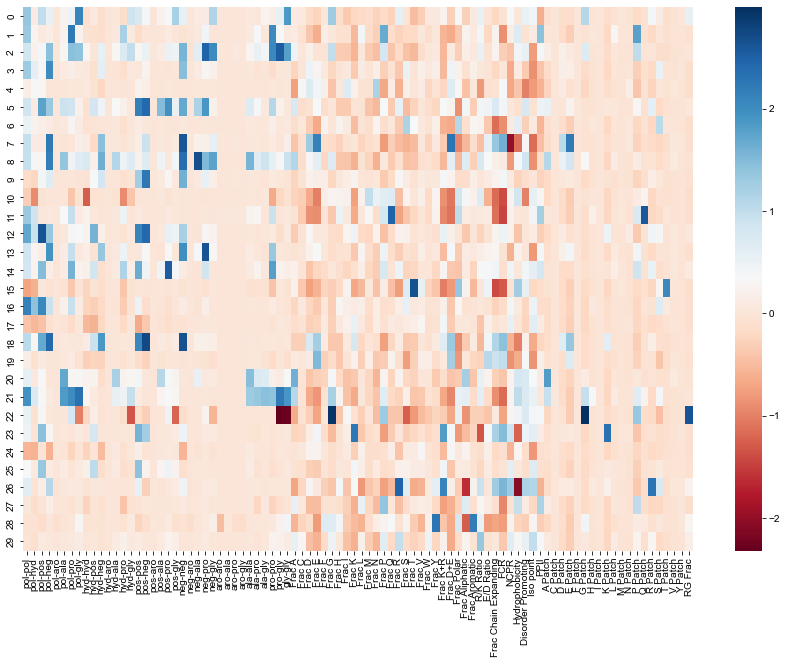

<Figure size 432x288 with 0 Axes>

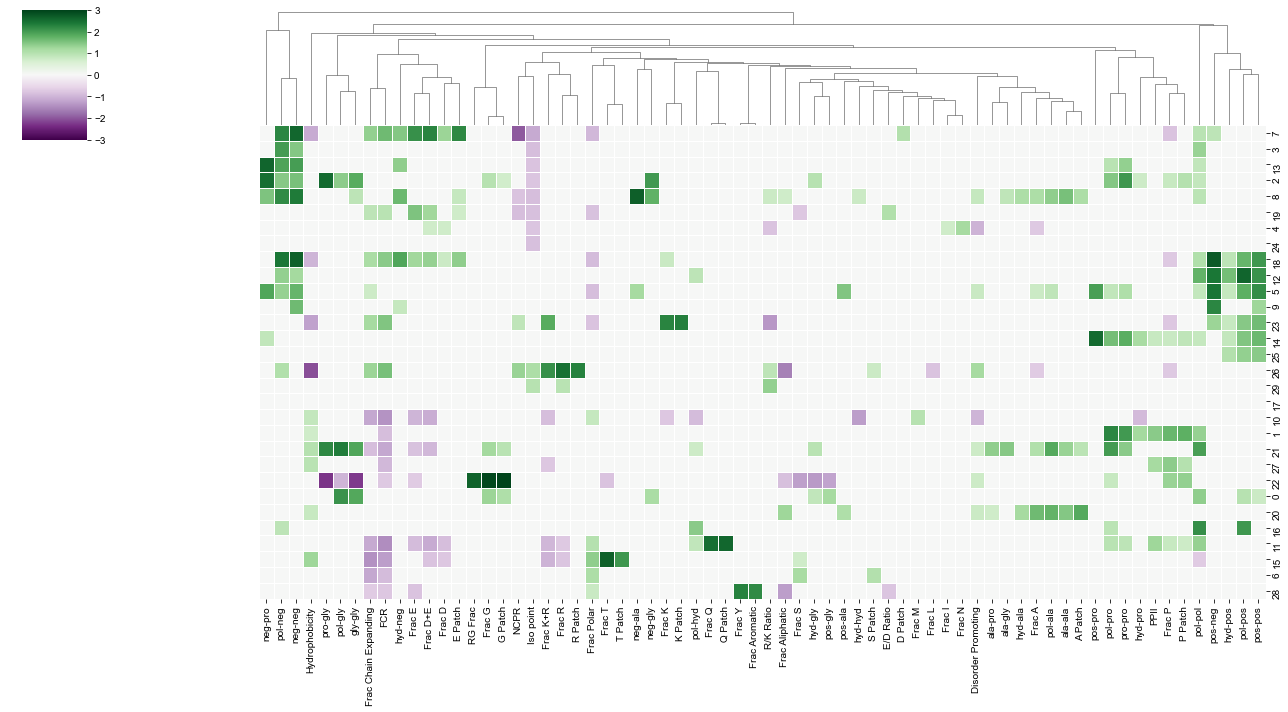

In [34]:
numkclusts=max(clusternum100to300)+1

clustcentroids=np.zeros((numkclusts,len(myfullfeats_all)))
for c in range(0,numkclusts):
    #print('Cluster_'+str(c))
    currclustpos=[x for x, ltr in enumerate(clusternum100to300) if ltr == c]
    
    tmparray=np.zeros((len(currclustpos),len(myfullfeats_all)))
    count=-1
    for p in currclustpos:
        count=count+1
        tmparray[count,:]=zvec100to300wcutoff[p,:]
        
    #print(len(np.mean(tmparray, axis=0)))
    clustcentroids[c,:]=np.mean(tmparray, axis=0)

plt.figure(figsize=(15,10))
sbn.heatmap(clustcentroids,cmap='RdBu')
plt.xticks(np.arange(0.5, len(myfullfeats_all), 1), myfullfeats_all,rotation=90) 

clustcentzscore=pd.DataFrame()
for i in range(0,len(myfullfeats_all)):
    clustcentzscore[myfullfeats_all[i]]=clustcentroids[:,i]
    
print(clustcentzscore)

#clustcentzscore.to_excel('GIN_human_cluster_centroid_zscores.xlsx')

#myclists=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 0, 16, 11, 22, 27, 20, 15, 6, 28]
myclists=[7, 3, 13, 2, 8, 19, 4, 24, 18, 12, 5, 9, 23, 14, 25, 26, 29, 17, 10, 1, 21, 27, 22, 0, 20, 16, 11, 15, 6, 28]

tmpcoff=0.7
testdf=clustcentzscore.copy()
testdf = testdf[testdf.columns[testdf.abs().max(axis=0) >= tmpcoff]]
testdf = testdf.reindex(myclists)
testdf[abs(testdf) < tmpcoff] = 0

plt.figure()
sbn.clustermap(testdf,cmap='PRGn',figsize=(18,10),linewidth=1,row_cluster=False,vmin=-3,vmax=3)
#plt.savefig("figures/GIN_centroid_zscores_cutoff_"+str(tmpcoff)+".pdf", transparent=True, bbox_inches = "tight") 


## 5.5 - Get which cluster IDR belongs to

In [35]:
## May eventually need strength of going to cluster, i.e., how different is the distance from another cluster
## This says which IDRs are strongly classified in that cluster vs which are not
## min(tmpdiff) gives this
numkclusts=max(clusternum100to300)+1
subclustnum=[]
believeclust=[]
mininterdist=[]
clustdist=[]
centcoff=5

for i in range(0,len(subseqs)):
    tmpmeandisttoclust=[]
    currzvecaa=subzvecpattcomp_all_wcutoff[i,:]
    
    for c in range(0,numkclusts):
        azvec=clustcentroids[c,:]
        bzvec=currzvecaa
        tmpdist=np.sum((azvec-bzvec)**2)
        tmpmeandisttoclust.append(tmpdist)
        
    print(subgenes[i])
    print("Cluster: ", pd.Series(tmpmeandisttoclust).idxmin())
    print(tmpmeandisttoclust[pd.Series(tmpmeandisttoclust).idxmin()])
    #print(tmpmeandisttoclust)
    minval=min(tmpmeandisttoclust)
    tmpdiff=[]
    for m in range(0,len(tmpmeandisttoclust)):
        if tmpmeandisttoclust[m]!=minval:
            tmpdiff.append(tmpmeandisttoclust[m]-minval)
        else:
            tmpdiff.append(100)
    print(min(tmpdiff))
    if min(tmpdiff)>=centcoff:
        believeclust.append(1)
    else:
        believeclust.append(0)
    subclustnum.append(pd.Series(tmpmeandisttoclust).idxmin())
    mininterdist.append(min(tmpdiff))
    clustdist.append(minval)
    
tdf=pd.DataFrame()
tdf['IDR']=subgenes
tdf['Cluster']=subclustnum
tdf['Cluster Dist']=clustdist
tdf['Min Inter Clust Dist']=mininterdist

print(tdf)

FOXG1 IDR 19Y 23DEtoG: 1-2
Cluster:  21
107.78553319872745
9.642751403667091
FUS2XPLD (24 YtoW): 1-2
Cluster:  28
79.17390055076741
23.499568160421845
ARID1A PLD 29YtoS: 1-2
Cluster:  21
42.5069961321381
36.57525995078666
EIF4B LCD: 1-2
Cluster:  26
117.33719586710853
15.064938336407806
FUS 2XPLD distributed YtoS, 24 Tyr; 70 Gly, and 114 Ser: 1-2
Cluster:  28
73.28029374042896
8.275302667931015
FOXG1 IDR 19Y, 17KtoR 23DE to G: 1-2
Cluster:  21
116.91410401475295
7.272250098550941
TAF15PLD DtoS: 1-2
Cluster:  28
68.51272776680982
24.035295156288797
FUS 2XPLD half YtoS, 24 Tyr; 70 Gly, and 114 Ser: 1-2
Cluster:  28
78.82384864717258
7.107693127028483
FOXG1 IDR Aro+ 12 S/GtoY: 1-2
Cluster:  2
82.60476820903403
13.901926946113818
FUSPLD24Y, 9 blocks of charge All 18 RtoK: 1-2
Cluster:  28
140.51226708931583
2.747337629465619
FOXG1 IDR1 17KtoR: 1-2
Cluster:  2
74.53137018397732
12.995864031589676
FOXG1IDR: 1-2
Cluster:  2
67.28589399455196
13.403962406223357
FOXG1 IDR Aro++ 19 S/G/AtoY: 1-2

## 5.6 - Save clusters to excel file as well

In [36]:
df1=pd.DataFrame(subzvecpattcomp_all,columns=myfullfeats_all)
df2=pd.DataFrame()
df2['Genes']=subgenes
df3=pd.DataFrame()
df3['Uniprot']=subaccs
df4=pd.DataFrame()
df4['Sequence']=subseqs
df5=pd.DataFrame()
df5['Start Pos']=substpos
df6=pd.DataFrame()
df6['End Pos']=subenpos
df7=pd.DataFrame()
df7['GIN Global Cluster']=subclustnum
df8=pd.DataFrame()
df8['Min Clust Dist']=clustdist
df9=pd.DataFrame()
df9['Min Inter Clust Dist']=mininterdist

dfcomppatt = pd.concat([df2, df3, df5, df6, df4, df7, df8, df9, df1], axis=1)
print(dfcomppatt)

dfcomppatt.to_excel('excel_zscore_w_clusters_files/'+mainprotein+'_patterning_compositional_feature_zscores_GIN_global_clusters.xlsx') 


                                                Genes Uniprot  Start Pos  \
0                          FOXG1 IDR 19Y 23DEtoG: 1-2  XXXXXX          0   
1                             FUS2XPLD (24 YtoW): 1-2  XXXXXX          0   
2                              ARID1A PLD 29YtoS: 1-2  XXXXXX          0   
3                                      EIF4B LCD: 1-2  XXXXXX          0   
4   FUS 2XPLD distributed YtoS, 24 Tyr; 70 Gly, an...  XXXXXX          0   
..                                                ...     ...        ...   
63                              ARID1APLD 30QtoA: 1-2  XXXXXX          0   
64                                SS18NPLDFUSPLD: 1-2  XXXXXX          0   
65                                     ARID1BPLD: 1-2  XXXXXX          0   
66                                 SS18PLD Mymix: 1-2  XXXXXX          0   
67                       ARID1A PLD AQG scramble: 1-2  XXXXXX          0   

    End Pos                                           Sequence  \
0         2  MLGMYGRK

# Part 6: Create sequence block diagrams

## 6.1 - Load in full protein sequences

In [27]:
## Load in sequences
myfile = open('FASTA_IDR_sets/'+mainprotein+'/'+mainprotein+'_full_proteins.fasta', 'r')
Lines = myfile.readlines()

subfullprotaccs=[]
subfullprotseqs=[]
thisseq = ''
for line in Lines:
    
    # remove pesky newline
    cleanline = line.strip()
    
    
    if cleanline[0]=='>':
        subfullprotaccs.append(cleanline)
        
        # check that this is not the very first sequence, if not 
        # add the sequence
        if (thisseq is not ''): 
            subfullprotseqs.append(thisseq.upper()) 

            # reset the sequence for the coming entry
            thisseq = '' 

    # else append the sequence
    else:
        thisseq += cleanline

# store the final sequence	
subfullprotseqs.append(thisseq.upper()) 

print(len(subfullprotaccs))
print(len(subfullprotseqs))

29
29


## 6.2 - Map full protein sequence lengths

In [28]:
subfullproteinlens=[]

for s in range(0,len(subaccs)):
    tmp2=subaccs[s].split('_')
    idx= [i for i, s in enumerate(subfullprotaccs) if tmp2[0][1:] in s][0]
    subfullproteinlens.append(len(subfullprotseqs[idx]))
    
print(subfullproteinlens)

[2285, 2285, 2236, 2236, 1835, 231, 202, 242, 651, 651, 651, 597, 597, 387, 391, 378, 1560, 1560, 1079, 1079, 1689, 1689, 498, 498, 1590, 1590, 1590, 1590, 1590, 1590, 1647, 1647, 1647, 1647, 1647, 1647, 1105, 1105, 1105, 1214, 1214, 1214, 1214, 515, 531, 483, 411, 418, 396]


## 6.3 - Plot sequence block diagrams full proteins w IDR cluster

meta NOT subset; don't know how to subset; dropped


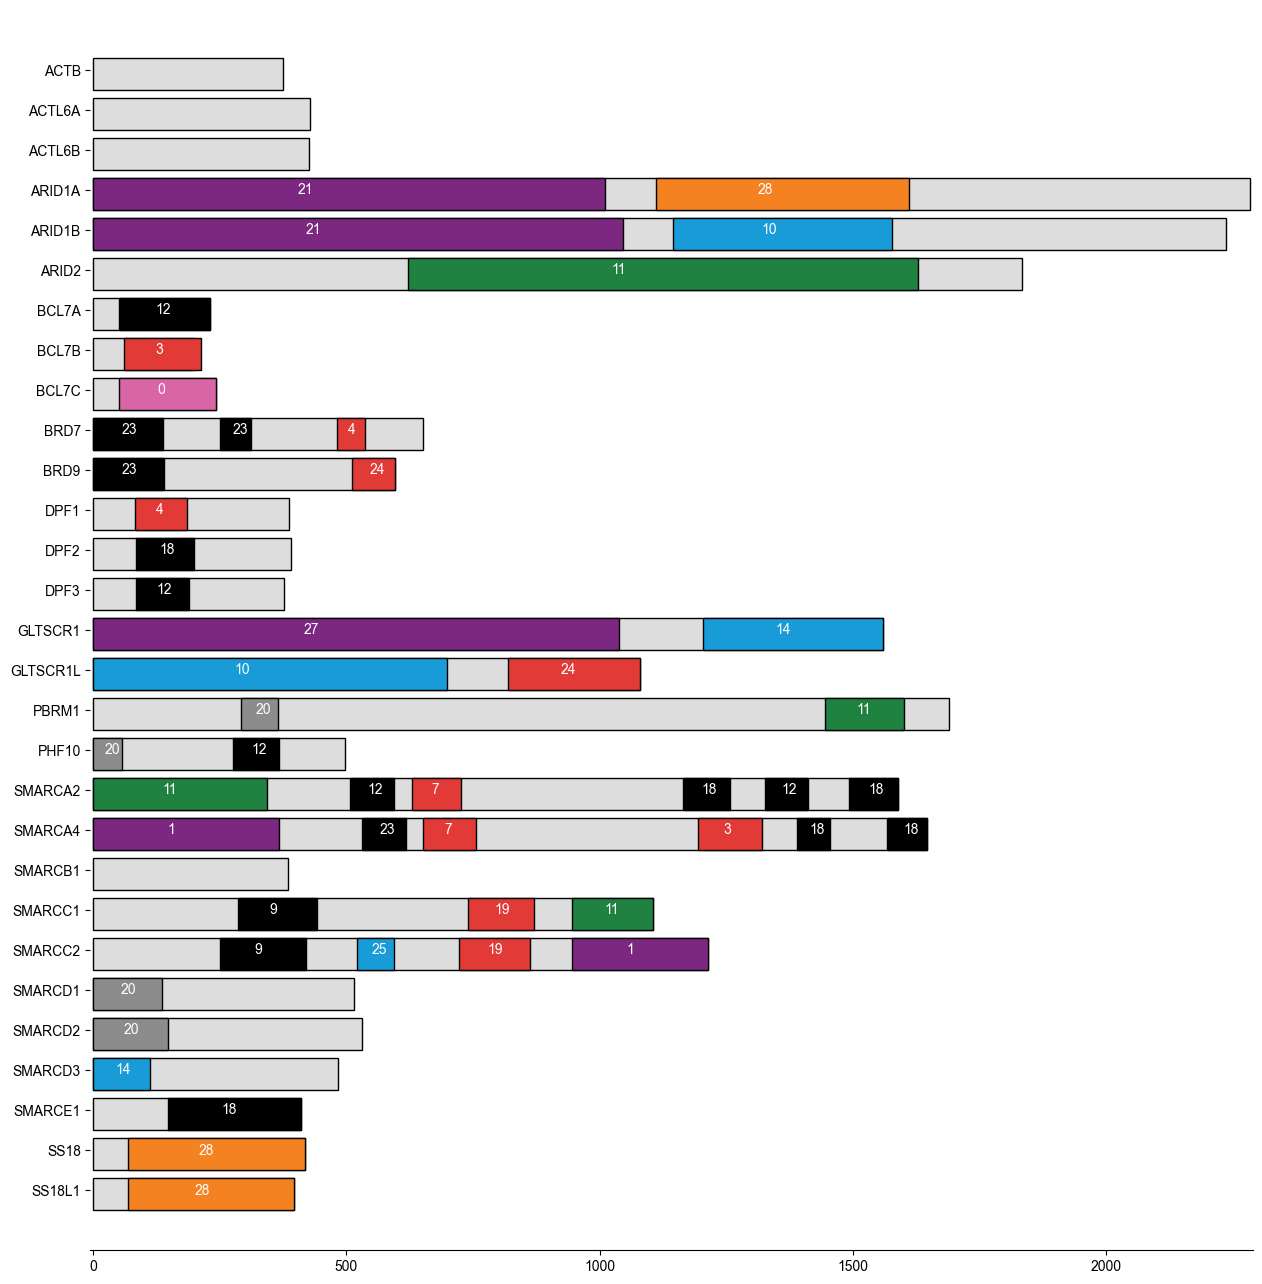

In [31]:
mycolors = ['#d865a6','#7c2880','#e23a36','#e23a36','#e23a36','#000000','#1f8241','#e23a36','#e23a36','#000000','#189bd7','#1f8241','#000000','#e23a36','#189bd7','#1f8241','#1f8241','#189bd7','#000000','#e23a36','#8c8c8c','#7c2880','#d865a6','#000000','#e23a36','#189bd7','#189bd7','#7c2880','#f58220','#189bd7']

#define Matplotlib figure and axis
plt.style.use('default')
fig, ax = plt.subplots()
fig.set_size_inches(15,len(subfullprotaccs)/1.8)

toplens=[]
tmpprots=[]
for s in range(0,len(subfullprotaccs)):
    currlen=len(subfullprotseqs[s])
    toplens.append(currlen)
    
    #ax.plot([0, currlen+1],[len(subaccs)-s, len(subaccs)-s+0.8],color='#d8d8d8')

    #add rectangle to plot
    ax.add_patch(Rectangle((0, len(subfullprotaccs)-s), currlen, 0.8, edgecolor = 'black', facecolor='#dddddd'))

    tmp=subfullprotaccs[s].split('_')
    pos=[i for i, ltr in enumerate(subaccs) if ltr == tmp[1]]
    tmpprots.append(tmp[0][1:])
    
    if pos:
        for p in pos:
            currstpos=int(substpos[p])
            currenpos=int(subenpos[p])
            if believeclust[p]==1:
                ax.add_patch(Rectangle((currstpos, len(subfullprotaccs)-s), currenpos-currstpos, 0.8, edgecolor = 'black', facecolor=mycolors[subclustnum[p]]))
            else:
                ax.add_patch(Rectangle((currstpos, len(subfullprotaccs)-s), currenpos-currstpos, 0.8, edgecolor = 'black', facecolor=mycolors[subclustnum[p]],alpha=0.7,hatch='/')) 
            plt.text(currstpos+(currenpos-currstpos)/2.5,len(subfullprotaccs)-s+0.4, subclustnum[p],color='white')

#print(list(np.arange(len(subaccs)+0.5, 0, -1)))
#print(subgenes)
ax.set_yticks(list(np.arange(len(tmpprots)+0.5, 1, -1)))
ax.set_yticklabels(tmpprots)
ax.set_xlim([-5, max(toplens)+5])
ax.set_ylim([0, len(tmpprots)+2])
ax.spines[['left','right', 'top']].set_visible(False)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42

plt.savefig("figures/sequence_block_diagrams/"+mainprotein+"_clustered_sequence_features_IDRs_gte_30_w_confidence_using_centroids_"+str(centcoff)+".pdf", transparent=True, bbox_inches = "tight") 


## 6.4 - Plot Specific Residues only on IDR region

/project/engineering/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


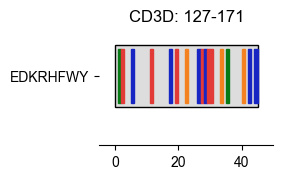

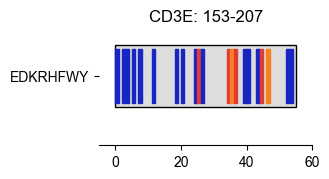

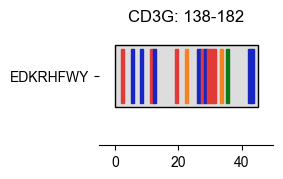

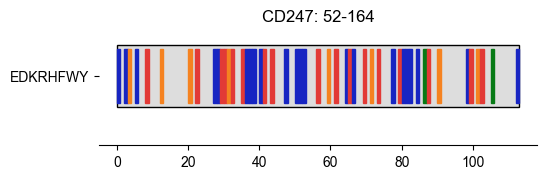

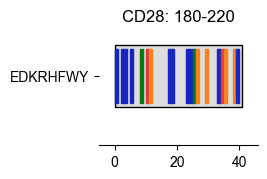

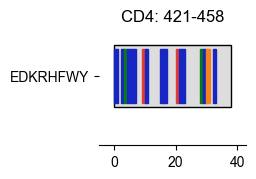

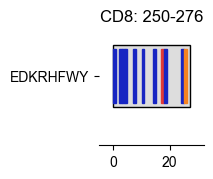

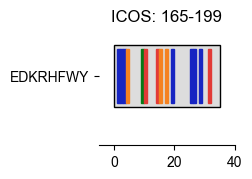

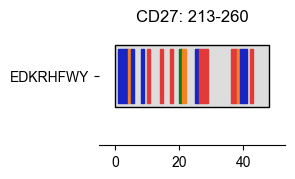

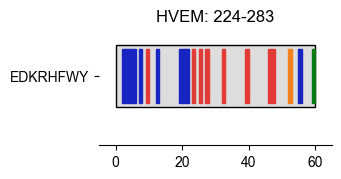

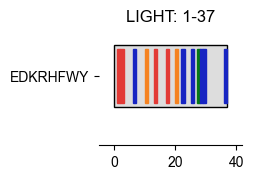

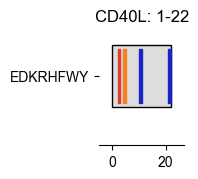

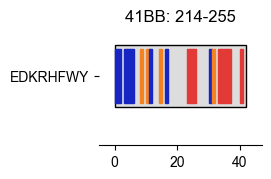

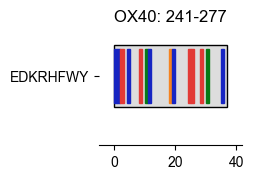

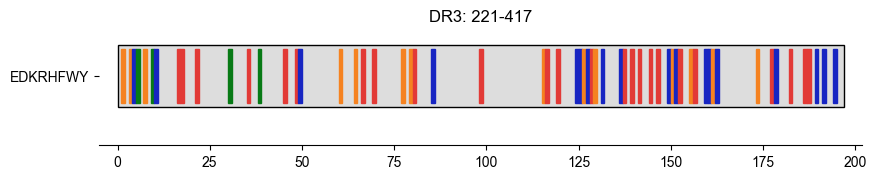

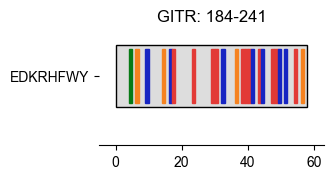

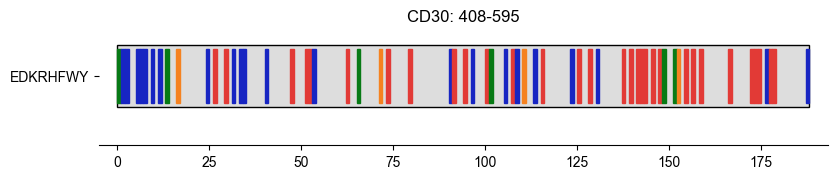

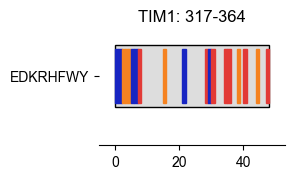

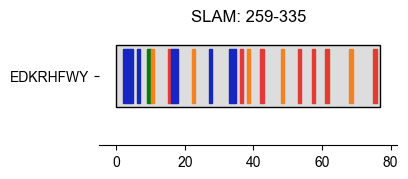

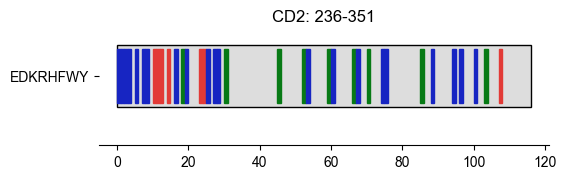

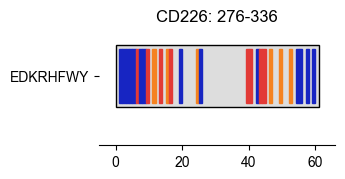

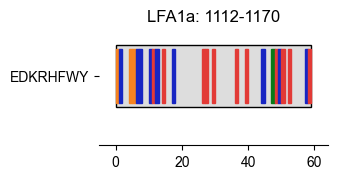

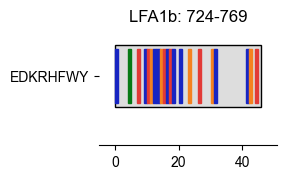

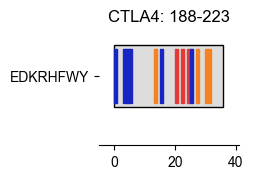

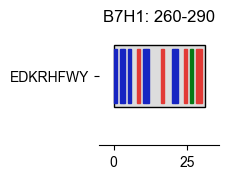

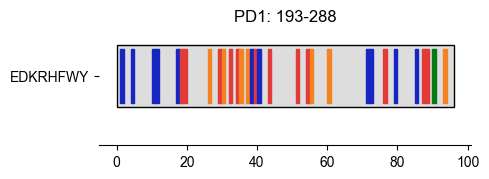

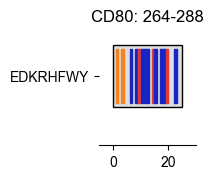

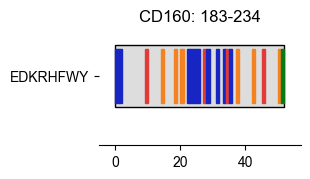

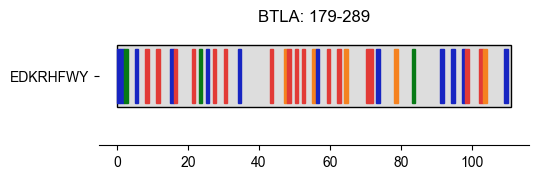

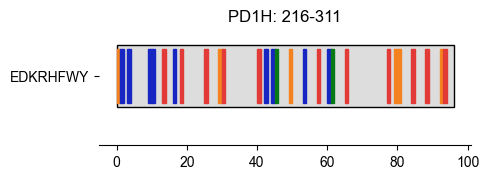

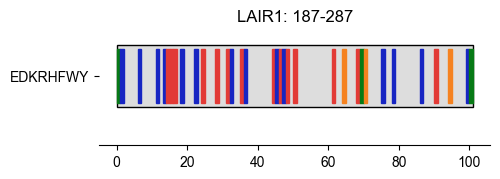

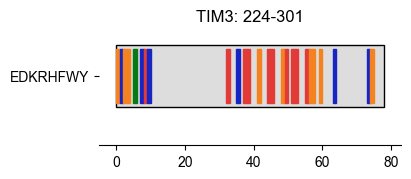

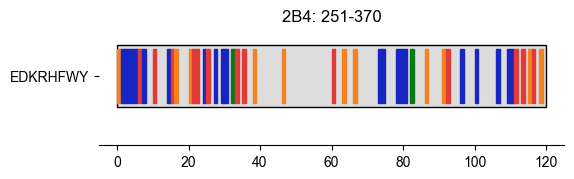

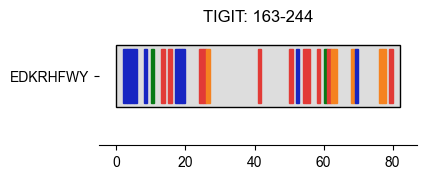

In [42]:
#myaa=['ED','KR','FWY']
myaa=['EDKRHFWY']

myaalist='_'
for a in range(0,len(myaa)):
    subaa=myaa[a]
    for i in range(0,len(subaa)):
        myaalist=myaalist+subaa[i]+'_'

shift=0.05

# If subgenes then all the IDRs, otherwise can set to a particular IDR
whichseqs=subgenes
#whichseqs=['MED1: 519-1581']

for p in range(0,len(whichseqs)):
    whichseq=whichseqs[p]
    whichseqpos=subgenes.index(whichseq)
    
    currseq=subseqs[whichseqpos]
    
    ## define Matplotlib figure and axis
    fig, ax = plt.subplots()
    fig.set_size_inches(len(currseq)*0.05,1+len(myaa)/2) # may need to change 0.05 to something smaller if using long IDRs
    
    ## Plot particular amino acids
    for a in range(0,len(myaa)):
        
        #tmp=0
        tmp=a

        #ax.plot([0, len(currseq)+1],[tmp+1, tmp+1.8],color='grey')

        #add rectangle to plot
        ax.add_patch(Rectangle((0, tmp+1), len(currseq), 0.8, edgecolor = 'black', facecolor='#dddddd'))

        
        posaa=[i for i, ltr in enumerate(currseq) if ltr in myaa[a]]
        for i in posaa:
            #ax.plot([i, i],[tmp+1.8, tmp+2.25],color='black')
            #ax.plot(i,tmp+2.25,marker="o",markeredgecolor='black',markerfacecolor=aacolor_map[currseq[i]],markersize=8)
            #ax.plot([i, i],[tmp+1.05, tmp+1.75],color=aacolor_map[currseq[i]])
            ax.add_patch(Rectangle((i, tmp+1+shift), 1, 0.8-2*shift, color=aacolor_map[currseq[i]]))
        
    
    ax.set_xlim([-5, len(currseq)+5])
    ax.set_ylim([0.5, tmp+2])
    plt.yticks(np.arange(1+0.4,len(myaa)+1,1),myaa)
    ax.spines[['left','right', 'top']].set_visible(False)
    plt.title(subgenes[whichseqpos])
    
    whichsequnderscore=subgenes[whichseqpos].replace(": ", "_")
    #plt.savefig('figures/sequence_block_diagrams/IDR_residues/'+mainprotein+'/'+whichsequnderscore+myaalist+'residues.pdf', transparent=True, bbox_inches = "tight")


## 6.5 - Plot patterning on only IDR region

/project/engineering/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:78: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


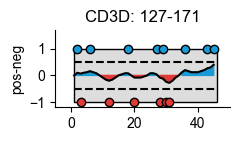

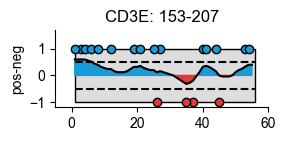

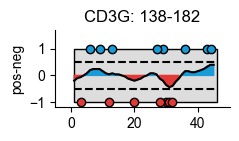

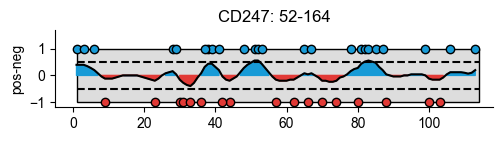

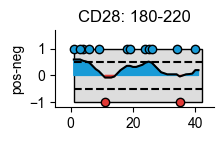

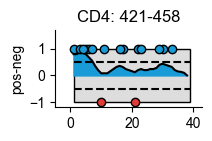

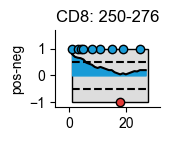

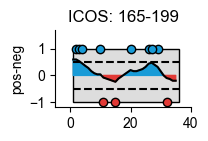

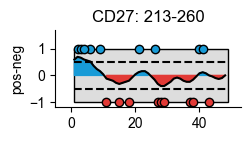

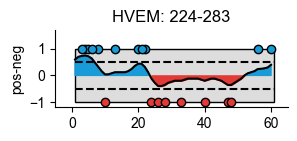

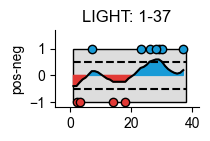

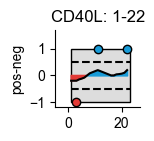

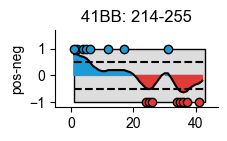

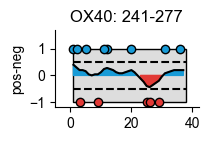

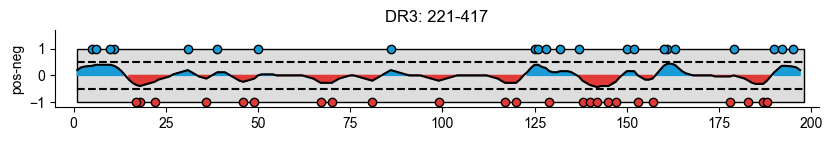

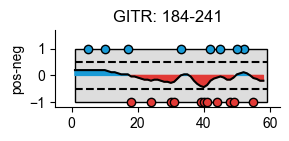

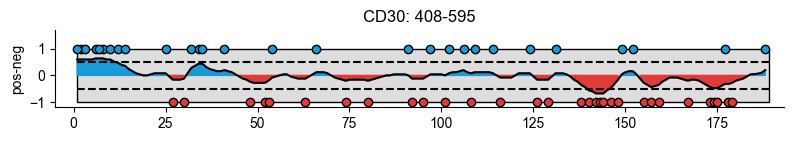

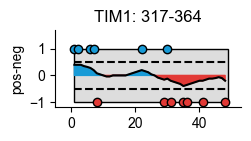

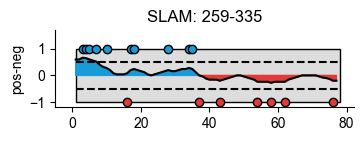

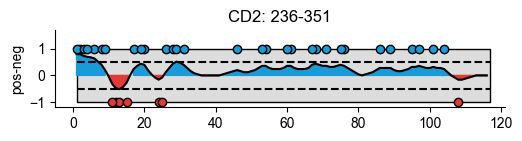

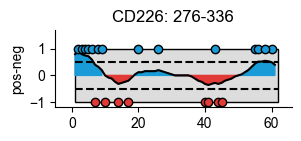

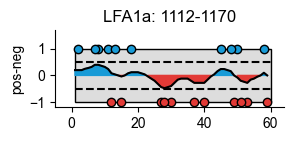

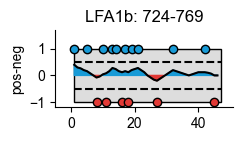

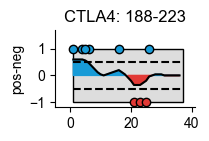

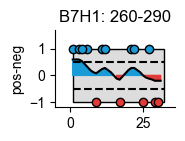

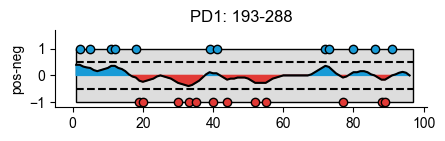

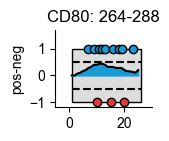

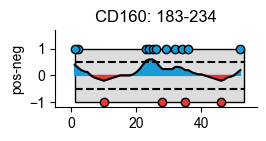

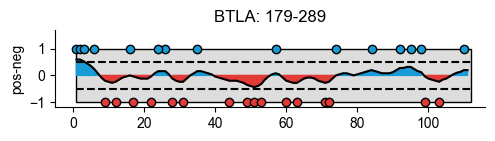

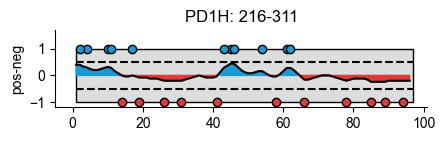

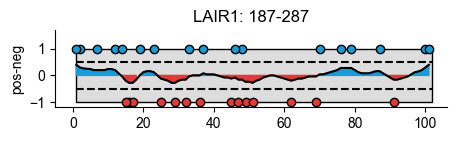

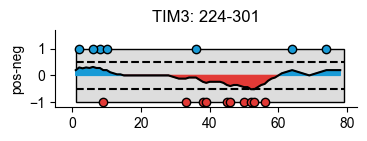

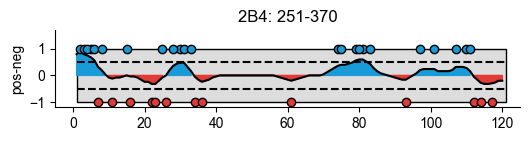

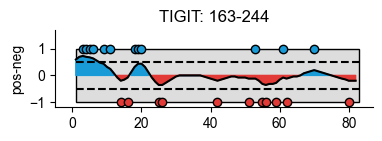

In [46]:
def get_omega(myseq,type1,type2):
    blobsz=[5]
    for b in blobsz:

        # Get asymmetry for each blob
        sigX=np.zeros((len(myseq)-b+1))
        for x in range(0,len(myseq)-b+1):
            count=0
            count2=0
            subseq=myseq[x:x+b]
            for res in type1:
                count=count+subseq.count(res)
                
            for res in type2:
                count2=count2+subseq.count(res)

            tmp=((count/b)-(count2/b))
            sigX[x]=(tmp)

        # Add up all blobs a part of so can map directly back to sequence
        blockX=np.zeros(len(myseq))
        #blockX=np.zeros((len(myseq)))
        for x in range(0,len(myseq)):
            if x>=b-1 and x<=len(myseq)-b:
                blockX[x]=np.mean(sigX[x-b+1:x+1])
                #print('Sequence position '+str(x))
                #print(sigX[x-b+1:x+1])
                #print(blockX[x])
            elif x==0:
                blockX[x]=sigX[0]
            elif x<b-1:
                blockX[x]=np.mean(sigX[0:x+1])
                #print('Sequence position '+str(x))
                #print(sigX[0:x+1])
                #print(blockX[x])
            elif x>len(myseq)-b:
                blockX[x]=np.mean(sigX[-(len(myseq)-x):])
                #print('Sequence position '+str(x))
                #print(len(myseq)-x)
                #print(sigX[-(len(myseq)-x):])
                #print(blockX[x])
        #print(len(sigX))
        return blockX

# Starts Here
pol=['S','T','N','Q','C','H']
hyd=['I','L','M','V']
pos=['R','K']
neg=['E','D']
aro=['F','W','Y']
ala=['A']
pro=['P']
gly=['G']

typeall=[pol,hyd,pos,neg,aro,ala,pro,gly]
typeallstr=['pol','hyd','pos','neg','aro','ala','pro','gly']

mytype1=pos
mytype2=neg

mypattcolordict={'pol':'#1f8241','hyd':'#231f20','pos':'#189bd7','neg':'#e23a36','aro':'#f58220','ala':'#8c8c8c','pro':'#7c2880','gly':'#d865a6'}

# If subgenes then all the IDRs, otherwise can set to a particular IDR
whichseqs=subgenes
#whichseqs=['YAP1: 249-472','YAP1: 1-155']

for p in range(0,len(whichseqs)):
    whichseq=whichseqs[p]
    whichseqpos=subgenes.index(whichseq)
    
    currseq=subseqs[whichseqpos]
    
    ## define Matplotlib figure and axis
    fig, ax = plt.subplots()
    fig.set_size_inches(len(currseq)*0.05,1)
    
    ax.add_patch(Rectangle((1, -1), len(currseq), 2, edgecolor = 'black', facecolor='#dddddd'))
    

    ## Plot patterning using sliding window ncpr idea
    # Get NCPR
    ncprblocks=get_omega(currseq,mytype1,mytype2)
    
    x0=np.linspace(1, len(ncprblocks), len(ncprblocks))
    plt.plot(x0,ncprblocks,color='black')
    plt.fill_between(x0, ncprblocks, 0, where=ncprblocks >= 0, color=mypattcolordict[typeallstr[typeall.index(mytype1)]])
    plt.fill_between(x0, ncprblocks, 0, where=ncprblocks <= 0, color=mypattcolordict[typeallstr[typeall.index(mytype2)]])
    plt.ylim(-1.2,1.7)
    plt.xlim(-5,len(ncprblocks)+5)
    plt.plot([1,len(currseq)+1],[0.5, 0.5],'--k')
    plt.plot([1,len(currseq)+1],[-0.5, -0.5],'--k')
    
    for a in mytype1:
        pos=[i for i, ltr in enumerate(currseq) if ltr == a]
        actpos=[]
        for i in pos:
            actpos.append(i+1)
        ys = [1] * len(pos)
        plt.plot(actpos,ys,'o',markerfacecolor = mypattcolordict[typeallstr[typeall.index(mytype1)]] ,markeredgecolor = 'black')

    for a in mytype2:
        pos=[i for i, ltr in enumerate(currseq) if ltr == a]
        actpos=[]
        for i in pos:
            actpos.append(i+1)
        ys = [-1] * len(pos)
        plt.plot(actpos,ys,'o',markerfacecolor = mypattcolordict[typeallstr[typeall.index(mytype2)]] ,markeredgecolor = 'black')
          
    
    ax.spines[['right', 'top']].set_visible(False)
    plt.title(subgenes[whichseqpos])
    plt.ylabel(typeallstr[typeall.index(mytype1)]+'-'+typeallstr[typeall.index(mytype2)])
    
    whichsequnderscore=subgenes[whichseqpos].replace(": ", "_")
    #plt.savefig('figures/sequence_block_diagrams/IDR_patterning/'+mainprotein+'/'+whichsequnderscore+'_'+typeallstr[typeall.index(mytype1)]+'-'+typeallstr[typeall.index(mytype2)]+'.pdf', transparent=False, bbox_inches = "tight")


# Part 7: Compare to rest of IDRome

## 7.1 Get all features for full idrome

In [14]:
myfeatidrome=['pol-pol','pol-hyd','pol-pos','pol-neg','pol-aro','pol-ala','pol-pro','pol-gly','hyd-hyd','hyd-pos','hyd-neg','hyd-aro','hyd-ala','hyd-pro','hyd-gly','pos-pos','pos-neg','pos-aro','pos-ala','pos-pro','pos-gly','neg-neg','neg-aro','neg-ala','neg-pro','neg-gly','aro-aro','aro-ala','aro-pro','aro-gly','ala-ala','ala-pro','ala-gly','pro-pro','pro-gly','gly-gly','Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','Y Patch','RG Frac']


# Created in /project/fava/work/kiersten.ruff/Nucleoli/2023/human_sequence_grammar/analyze_nucleolarome_IDR_sequence_grammar.ipynb
zvecaa=np.load('IDR_data_by_species/'+speciesname+'_full_idrome_gte_30_nardini_compositional_RtoK.npy')

# check vector
idx=fullaccswnums.index('P19338_1')
print(myseqs[idx])
print(zvecaa[idx][21])

# Creates subset z-score matrix again so that way isn't set to cutoff in part 5
subzvecpattcomp_all=np.zeros((len(subseqs),len(myfullfeats_all)))

for s in range(0,len(subseqs)):
    subzvecpattcomp_all[s,:]=np.append(subzvecpatt_all[s,:],subzveccomp_all[s,:])


MVKLAKAGKNQGDPKKMAPPPKEVEEDSEDEEMSEDEEDDSSGEEVVIPQKKGKKAAATSAKKVVVSPTKKVAVATPAKKAAVTPGKKAAATPAKKTVTPAKAVTTPGKKGATPGKALVATPGKKGAAIPAKGAKNGKNAKKEDSDEEEDDDSEEDEEDDEDEDEDEDEIEPAAMKAAAAAPASEDEDDEDDEDDEDDDDDEEDDSEEEAMETTPAKGKKAAKVVPVKAKNVAEDEDEEEDDEDEDDDDDEDDEDDDDEDDEEEEEEEEEEPVKEAPGKRKKEMAKQKAAPEAKKQKVEGTEPT
23.807065212607533


## 7.2 Compare z-scores of subset compared to rest of IDRome

24508
215
215
Ks_2sampResult(statistic=0.11796318999776056, pvalue=0.005308730456019589)
pol-pol
2.2750093248443948


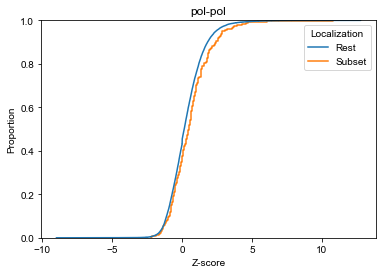

Ks_2sampResult(statistic=0.12881489100853644, pvalue=0.0016952719312238955)
pol-hyd
-2.7707606285773143


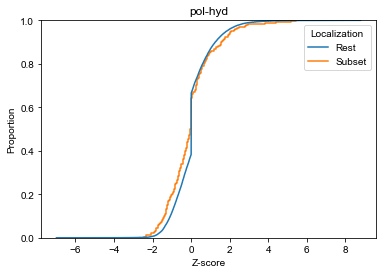

Ks_2sampResult(statistic=0.08178060509904692, pvalue=0.11556694868136416)
pol-pos
0.0


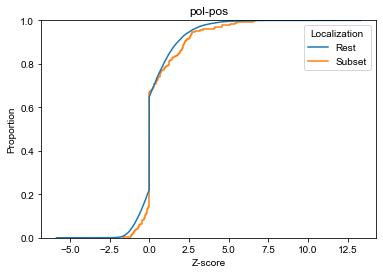

Ks_2sampResult(statistic=0.05913228143823944, pvalue=0.44538460963163873)
pol-neg
0.0


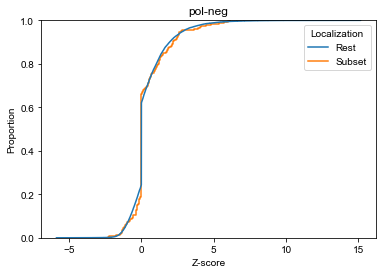

Ks_2sampResult(statistic=0.02092966321391021, pvalue=0.9999850320951679)
pol-aro
0.0


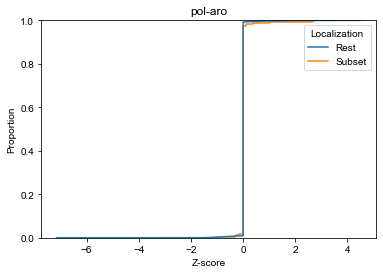

Ks_2sampResult(statistic=0.05822892192772365, pvalue=0.46519313661192185)
pol-ala
0.0


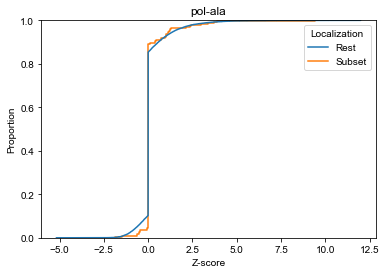

Ks_2sampResult(statistic=0.09006873882661948, pvalue=0.06298423764788968)
pol-pro
0.0


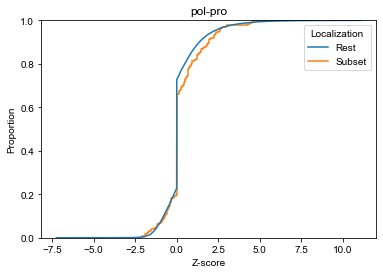

Ks_2sampResult(statistic=0.05788731539013359, pvalue=0.4727996511221089)
pol-gly
0.0


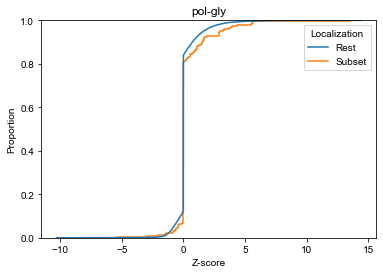

Ks_2sampResult(statistic=0.12107067080137102, pvalue=0.0038679680217948084)
hyd-hyd
-2.412517125079073


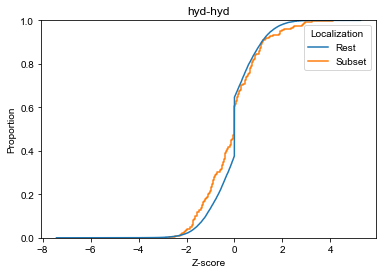

Ks_2sampResult(statistic=0.09823389420065975, pvalue=0.03270497169158519)
hyd-pos
1.4853862224437622


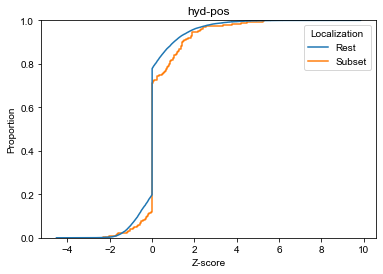

Ks_2sampResult(statistic=0.05417006691692505, pvalue=0.559135338939329)
hyd-neg
0.0


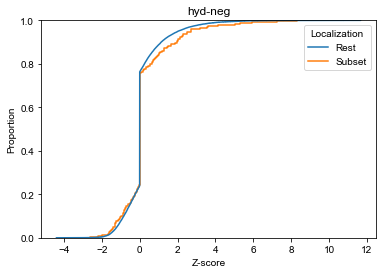

Ks_2sampResult(statistic=0.004243132759687351, pvalue=1.0)
hyd-aro
0.0


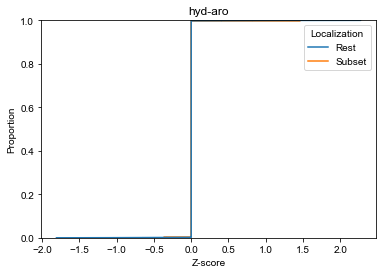

Ks_2sampResult(statistic=0.036522483403615746, pvalue=0.9386848946454589)
hyd-ala
0.0


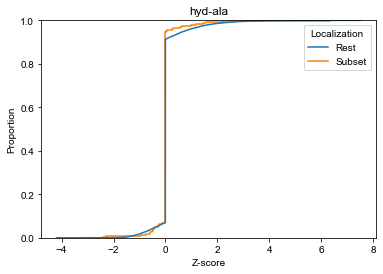

Ks_2sampResult(statistic=0.06975491628742014, pvalue=0.2508459701247545)
hyd-pro
0.0


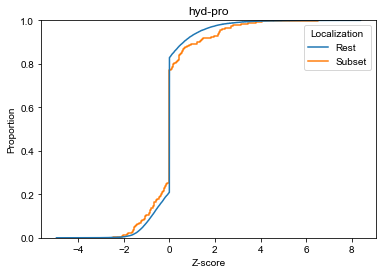

Ks_2sampResult(statistic=0.028758905492653475, pvalue=0.9945489440731815)
hyd-gly
0.0


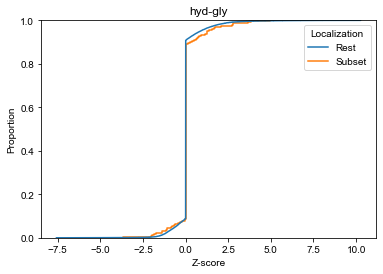

Ks_2sampResult(statistic=0.06729477987254281, pvalue=0.28930602894862556)
pos-pos
0.0


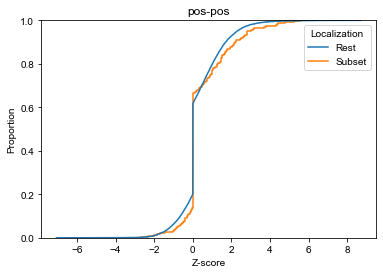

Ks_2sampResult(statistic=0.03406595283552404, pvalue=0.9656283362374056)
pos-neg
0.0


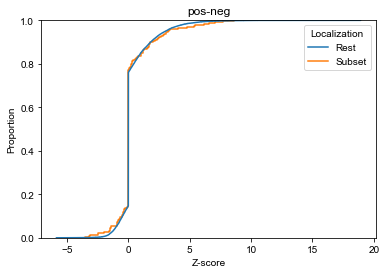

Ks_2sampResult(statistic=0.003916708734879166, pvalue=1.0)
pos-aro
0.0


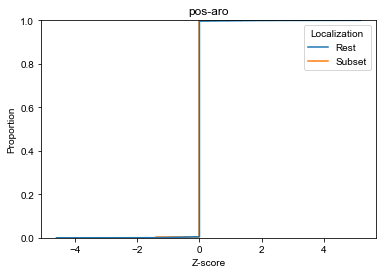

Ks_2sampResult(statistic=0.042683357309051484, pvalue=0.832251306582033)
pos-ala
0.0


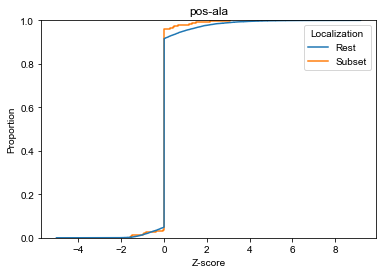

Ks_2sampResult(statistic=0.032239686329285935, pvalue=0.9796877288650169)
pos-pro
0.0


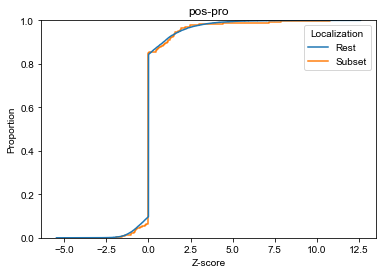

Ks_2sampResult(statistic=0.05953385890131746, pvalue=0.4367267407699599)
pos-gly
0.0


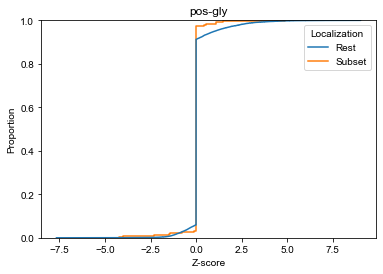

Ks_2sampResult(statistic=0.09538166939319292, pvalue=0.04138500722539781)
neg-neg
-1.3831569646417643


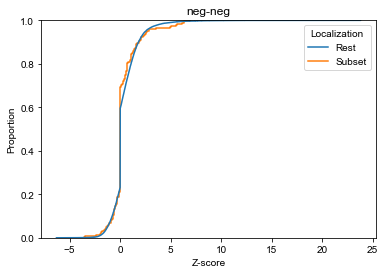

Ks_2sampResult(statistic=0.004569936347315173, pvalue=1.0)
neg-aro
0.0


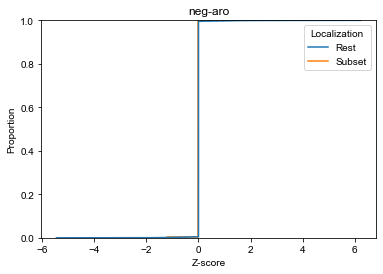

Ks_2sampResult(statistic=0.050312759763304626, pvalue=0.6532711100487889)
neg-ala
0.0


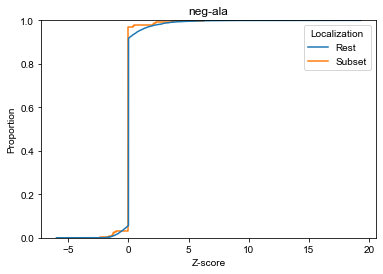

Ks_2sampResult(statistic=0.07609873947187629, pvalue=0.16932359804091862)
neg-pro
0.0


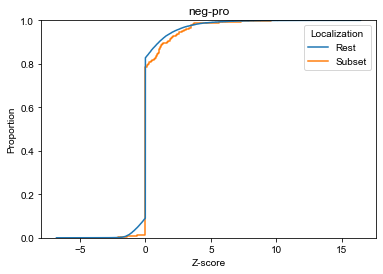

Ks_2sampResult(statistic=0.05080315492615606, pvalue=0.641195876262534)
neg-gly
0.0


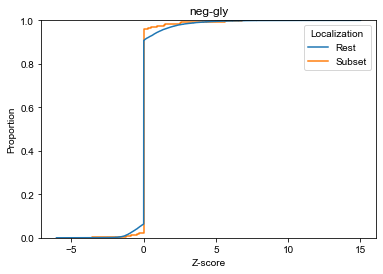

Ks_2sampResult(statistic=0.02827344464645621, pvalue=0.9956488906254602)
aro-aro
0.0


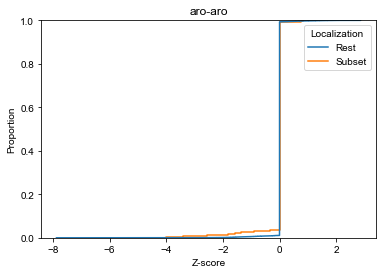

Ks_2sampResult(statistic=0.004447147775192506, pvalue=1.0)
aro-ala
0.0


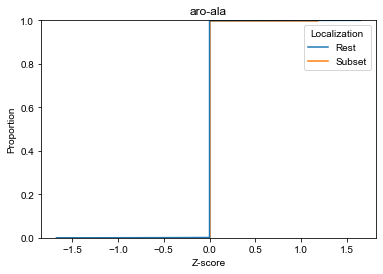

Ks_2sampResult(statistic=0.007139766417040838, pvalue=1.0)
aro-pro
0.0


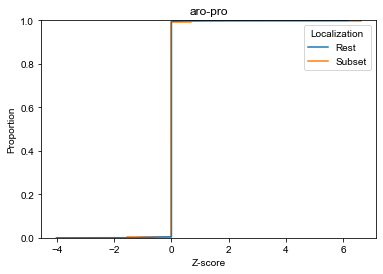

Ks_2sampResult(statistic=0.02749856715035622, pvalue=0.9970424056292114)
aro-gly
0.0


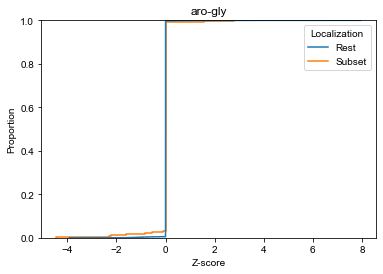

Ks_2sampResult(statistic=0.06398707968162265, pvalue=0.34734134905301367)
ala-ala
0.0


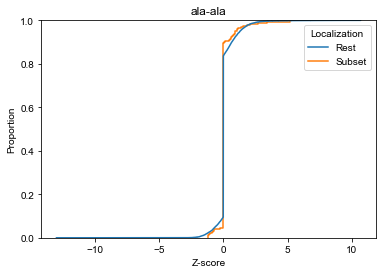

Ks_2sampResult(statistic=0.06336858206717502, pvalue=0.3589981417000013)
ala-pro
0.0


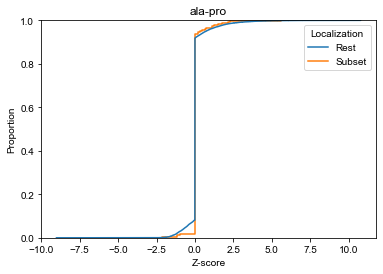

Ks_2sampResult(statistic=0.029094059462311313, pvalue=0.9936748078499255)
ala-gly
0.0


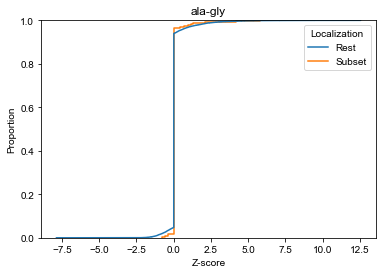

Ks_2sampResult(statistic=0.07280679113796729, pvalue=0.2085606021438458)
pro-pro
0.0


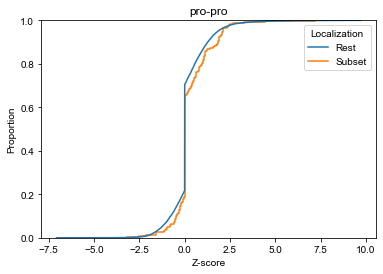

Ks_2sampResult(statistic=0.021989023043258775, pvalue=0.9999506422604258)
pro-gly
0.0


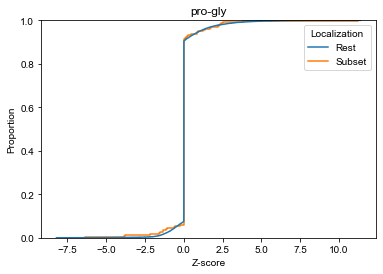

Ks_2sampResult(statistic=0.057537168689103885, pvalue=0.48065989762742056)
gly-gly
0.0


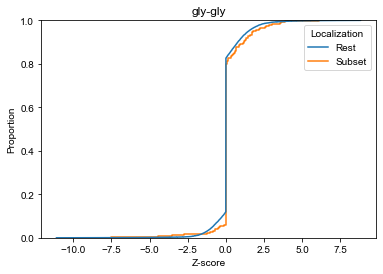

Ks_2sampResult(statistic=0.13144355331529145, pvalue=0.0012664590438551426)
Frac A
-2.8974088503387447


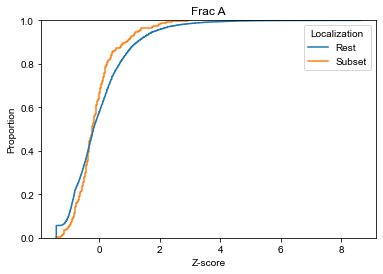

Ks_2sampResult(statistic=0.2892786788177378, pvalue=6.4501684179248185e-16)
Frac C
-15.190428945516594


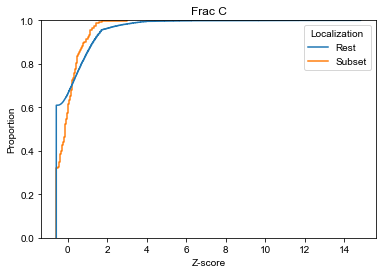

Ks_2sampResult(statistic=0.10214737665157272, pvalue=0.02341229244741216)
Frac D
-1.630556059668736


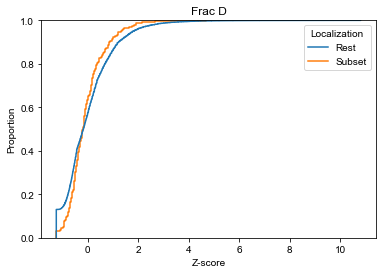

Ks_2sampResult(statistic=0.183939368635206, pvalue=1.0905577733282649e-06)
Frac E
-5.9623513223154


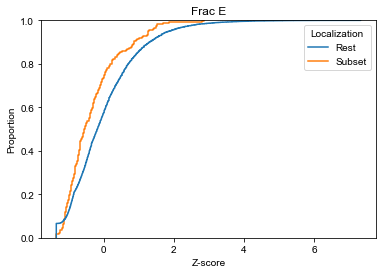

Ks_2sampResult(statistic=0.2855118973965786, pvalue=1.6232370957974803e-15)
Frac F
14.789618040940175


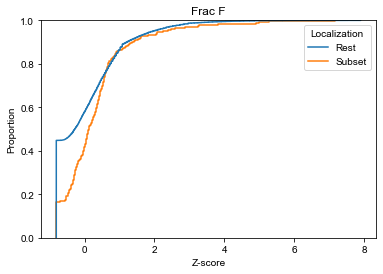

Ks_2sampResult(statistic=0.09654863528188233, pvalue=0.037616722177962976)
Frac G
1.4246190504135852


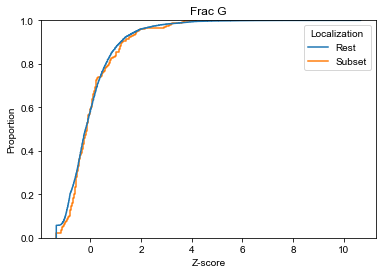

Ks_2sampResult(statistic=0.2262201995741305, pvalue=6.718513434782904e-10)
Frac H
9.172726810054852


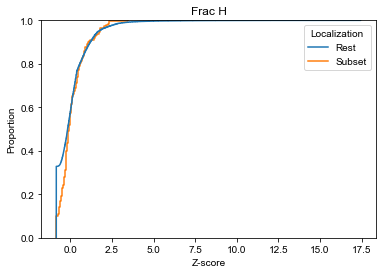

Ks_2sampResult(statistic=0.3268366095930707, pvalue=3.3560696678874715e-20)
Frac I
19.474169032329318


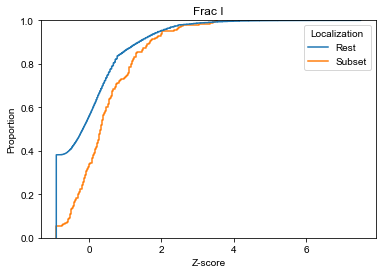

Ks_2sampResult(statistic=0.13259856297516515, pvalue=0.001112075019876632)
Frac K
-2.9538659145349935


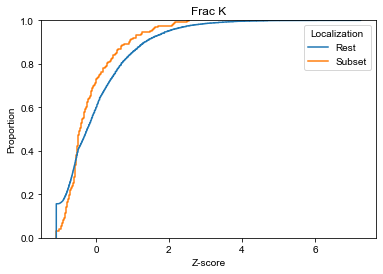

Ks_2sampResult(statistic=0.13616911041861984, pvalue=0.0007387229494200832)
Frac L
3.1315184088283603


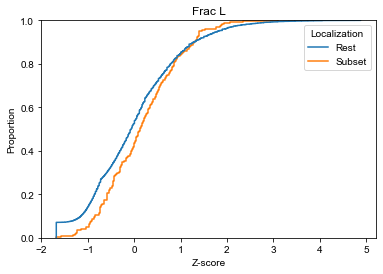

Ks_2sampResult(statistic=0.26996329627535004, pvalue=6.445557005689033e-14)
Frac M
13.190739546263332


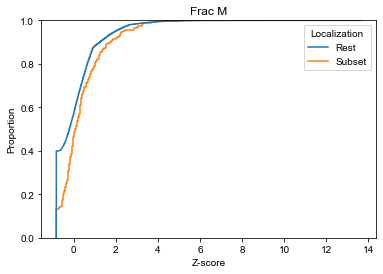

Ks_2sampResult(statistic=0.2128330189287978, pvalue=8.229350197771242e-09)
Frac N
8.084634455998383


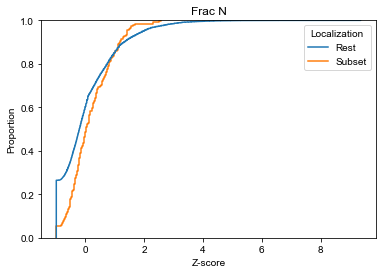

Ks_2sampResult(statistic=0.09043311913338214, pvalue=0.06124310658831749)
Frac P
0.0


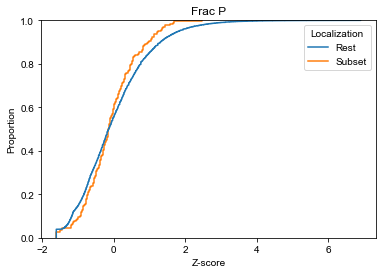

Ks_2sampResult(statistic=0.14621689737760046, pvalue=0.00022040585362277662)
Frac Q
3.6567768755084904


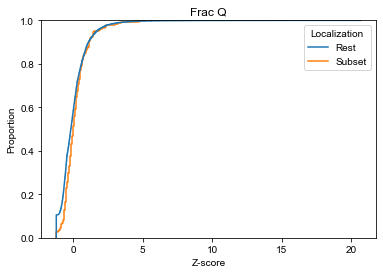

Ks_2sampResult(statistic=0.12005002637961593, pvalue=0.004295772464710077)
Frac R
-2.366958730087329


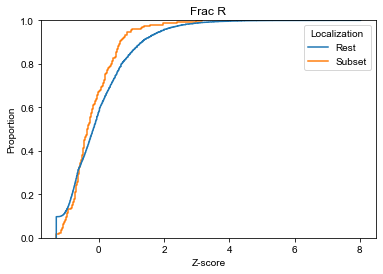

Ks_2sampResult(statistic=0.1027575238839904, pvalue=0.02219727256186878)
Frac S
-1.6537003851934684


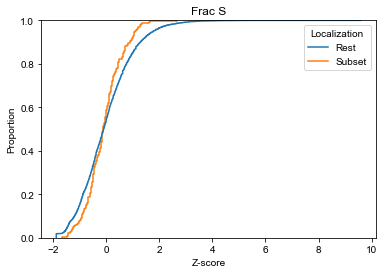

Ks_2sampResult(statistic=0.11398062711369045, pvalue=0.00787035137982456)
Frac T
2.104005877690203


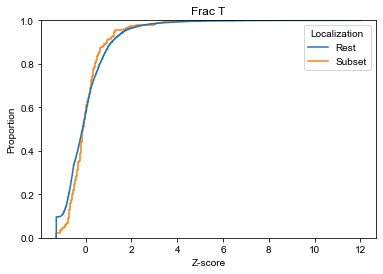

Ks_2sampResult(statistic=0.15161010548050752, pvalue=0.00011114021271593968)
Frac V
3.954128776335322


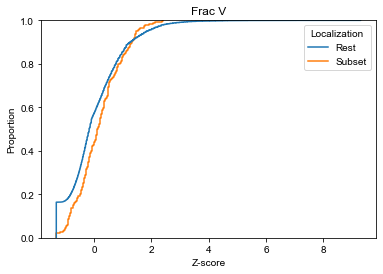

Ks_2sampResult(statistic=0.20919718668038145, pvalue=1.5827904625711537e-08)
Frac W
-7.8005765753286775


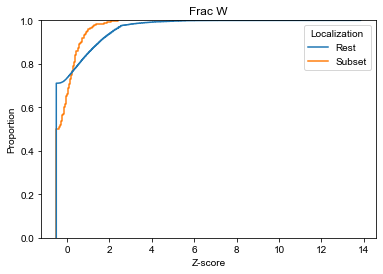

Ks_2sampResult(statistic=0.3973956297136958, pvalue=1.1637472791629587e-29)
Frac Y
28.934141321388385


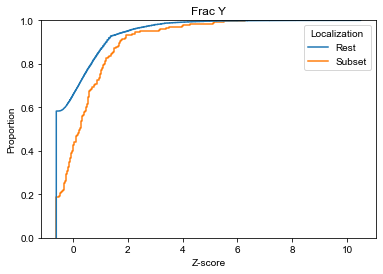

Ks_2sampResult(statistic=0.14969160520912006, pvalue=0.0001421938688667634)
Frac K+R
-3.8471191291669933


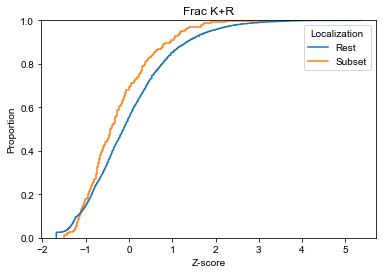

Ks_2sampResult(statistic=0.17205620566231816, pvalue=6.618853282411583e-06)
Frac D+E
-5.179217245644725


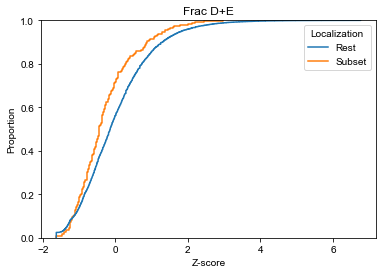

Ks_2sampResult(statistic=0.08901374396969569, pvalue=0.06826586352226885)
Frac Polar
0.0


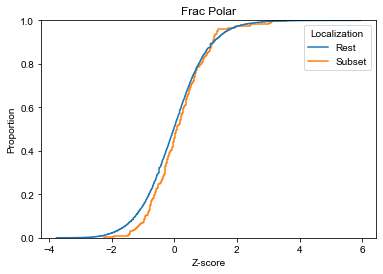

Ks_2sampResult(statistic=0.22130277346552235, pvalue=1.7165850694923162e-09)
Frac Aliphatic
8.76533466919971


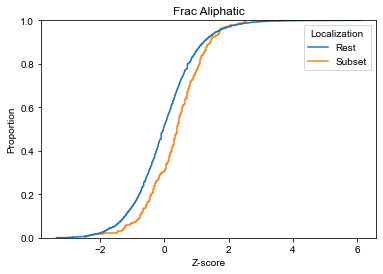

Ks_2sampResult(statistic=0.24680123433828915, pvalue=1.0593865898041375e-11)
Frac Aromatic
10.974945528862122


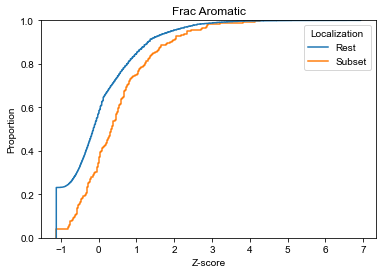

Ks_2sampResult(statistic=0.07627979093679904, pvalue=0.16734757266172995)
R/K Ratio
0.0


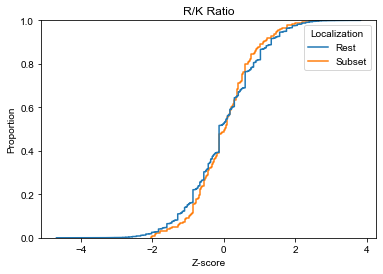

Ks_2sampResult(statistic=0.18062749325327088, pvalue=1.8245918151374179e-06)
E/D Ratio
-5.738834277651895


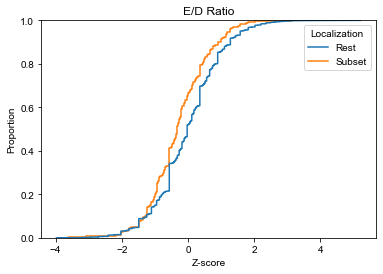

Ks_2sampResult(statistic=0.22463837152367905, pvalue=9.105400867042696e-10)
Frac Chain Expanding
-9.040700929549205


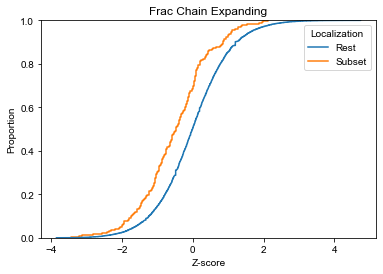

Ks_2sampResult(statistic=0.20576214316350427, pvalue=2.9060147696007506e-08)
FCR
-7.5367021827634595


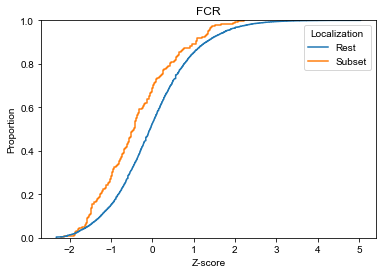

Ks_2sampResult(statistic=0.16408937186148992, pvalue=2.0727363423683332e-05)
NCPR
4.683455937817818


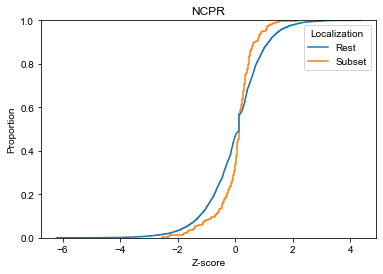

Ks_2sampResult(statistic=0.2376330842136028, pvalue=7.034801537294653e-11)
Hydrophobicity
10.152748150179994


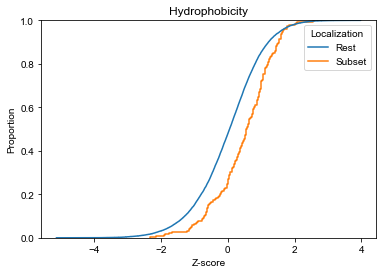

Ks_2sampResult(statistic=0.37663904714549784, pvalue=1.0967226675515166e-26)
Disorder Promoting
-25.959903180245988


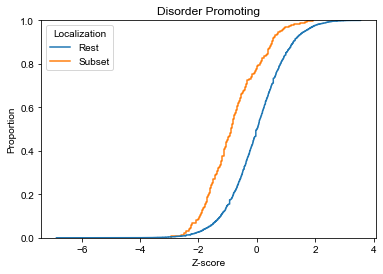

Ks_2sampResult(statistic=0.16449854058095886, pvalue=1.957287923903009e-05)
Iso point
4.70834528340452


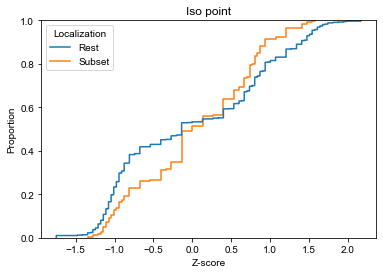

Ks_2sampResult(statistic=0.1336118059219391, pvalue=0.0009912881019902005)
PPII
-3.003800106442488


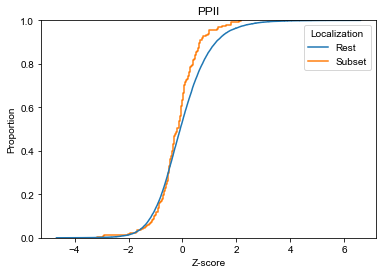

Ks_2sampResult(statistic=0.0683309863698992, pvalue=0.2726213344700262)
A Patch
0.0


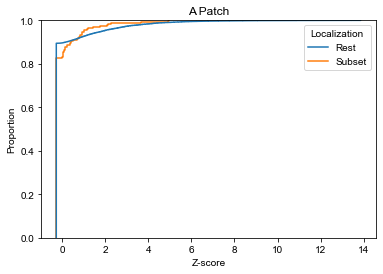

Ks_2sampResult(statistic=8.160600620210623e-05, pvalue=1.0)
C Patch
0.0


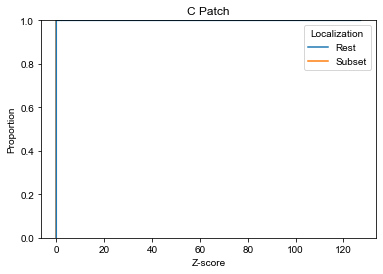

Ks_2sampResult(statistic=0.06768269307411723, pvalue=0.2829767196622023)
D Patch
0.0


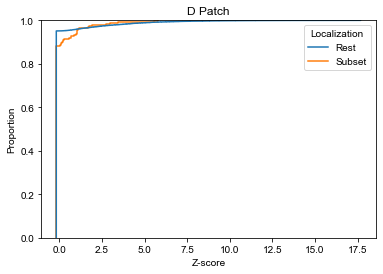

Ks_2sampResult(statistic=0.07161344563331962, pvalue=0.2243958954953904)
E Patch
0.0


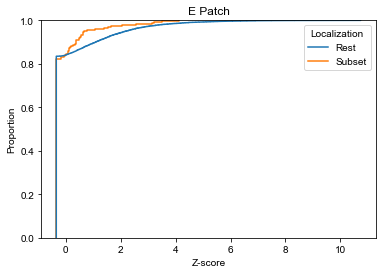

Ks_2sampResult(statistic=0.00020401501550515455, pvalue=1.0)
F Patch
0.0


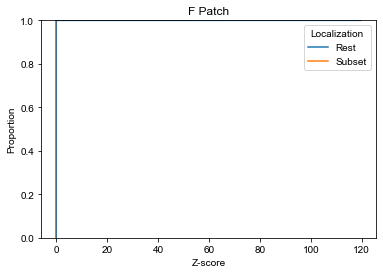

Ks_2sampResult(statistic=0.1304667483991938, pvalue=0.0014123815741009897)
G Patch
2.8500479568682597


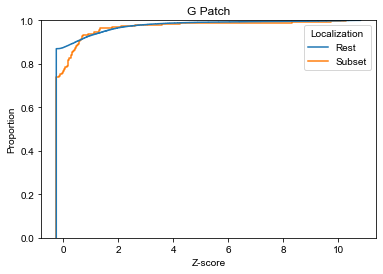

Ks_2sampResult(statistic=0.011382519613908793, pvalue=1.0)
H Patch
0.0


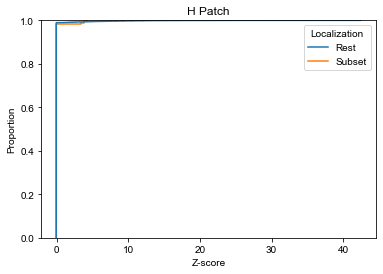

Ks_2sampResult(statistic=0.00028562102170714976, pvalue=1.0)
I Patch
0.0


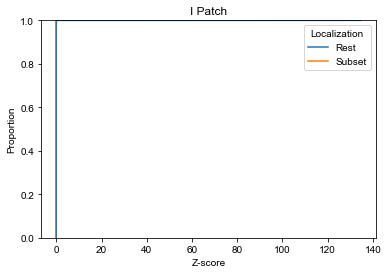

Ks_2sampResult(statistic=0.03977230026455536, pvalue=0.8888386122604345)
K Patch
0.0


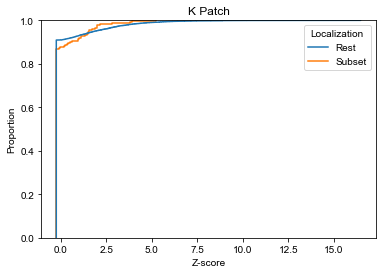

Ks_2sampResult(statistic=0.03733057264642581, pvalue=0.9277607837838964)
L Patch
0.0


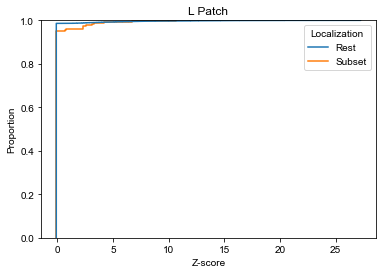

Ks_2sampResult(statistic=0.01758457608526509, pvalue=0.9999999276001981)
M Patch
0.0


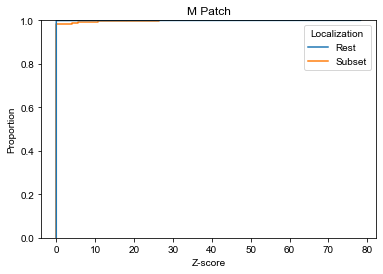

Ks_2sampResult(statistic=0.014646380299171424, pvalue=0.9999999999776077)
N Patch
0.0


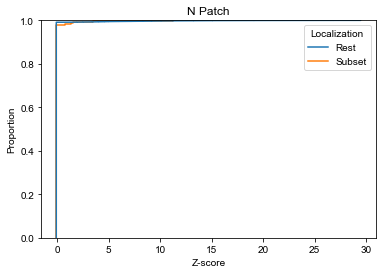

Ks_2sampResult(statistic=0.25897609133799687, pvalue=7.675605239851691e-13)
P Patch
-12.114887369340773


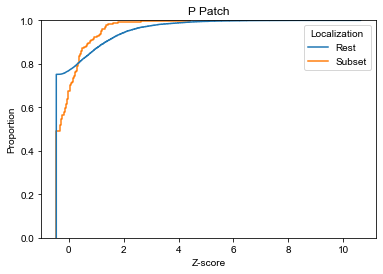

Ks_2sampResult(statistic=0.11521477562143922, pvalue=0.0069763800701118876)
Q Patch
2.1563698672589777


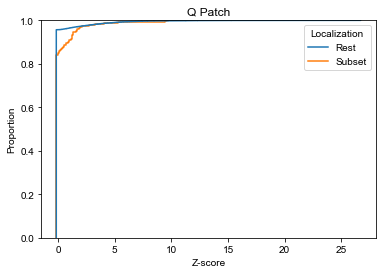

Ks_2sampResult(statistic=0.03737706909182004, pvalue=0.9271016398860397)
R Patch
0.0


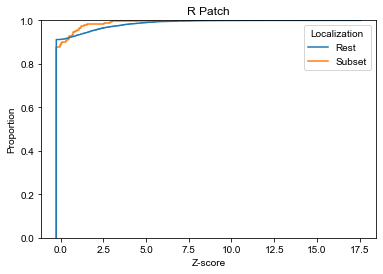

Ks_2sampResult(statistic=0.17884278887577287, pvalue=2.3984507130976212e-06)
S Patch
-5.62006920162988


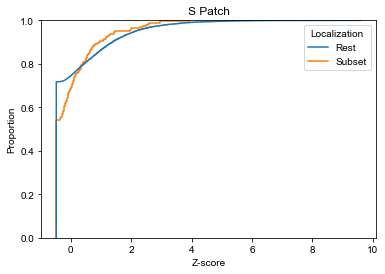

Ks_2sampResult(statistic=0.047855090506754294, pvalue=0.7135053163969733)
T Patch
0.0


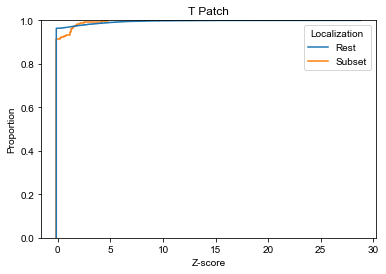

Ks_2sampResult(statistic=0.020073179711608158, pvalue=0.9999950668020495)
V Patch
0.0


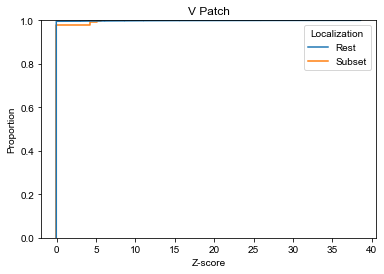

Ks_2sampResult(statistic=0.004324738765889458, pvalue=1.0)
Y Patch
0.0


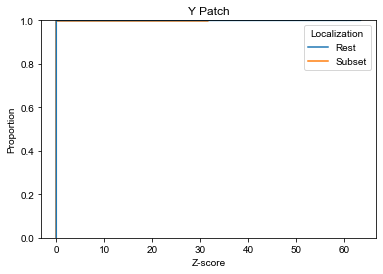

Ks_2sampResult(statistic=0.028434758844762653, pvalue=0.9953042001697383)
RG Frac
0.0


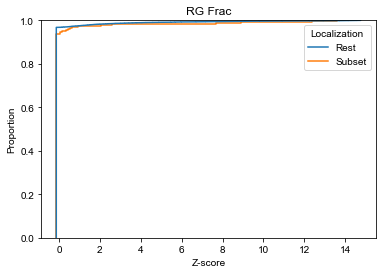

[5.30873046e-03 1.69527193e-03 1.15566949e-01 4.45384610e-01
 9.99985032e-01 4.65193137e-01 6.29842376e-02 4.72799651e-01
 3.86796802e-03 3.27049717e-02 5.59135339e-01 1.00000000e+00
 9.38684895e-01 2.50845970e-01 9.94548944e-01 2.89306029e-01
 9.65628336e-01 1.00000000e+00 8.32251307e-01 9.79687729e-01
 4.36726741e-01 4.13850072e-02 1.00000000e+00 6.53271110e-01
 1.69323598e-01 6.41195876e-01 9.95648891e-01 1.00000000e+00
 1.00000000e+00 9.97042406e-01 3.47341349e-01 3.58998142e-01
 9.93674808e-01 2.08560602e-01 9.99950642e-01 4.80659898e-01
 1.26645904e-03 6.45016842e-16 2.34122924e-02 1.09055777e-06
 1.62323710e-15 3.76167222e-02 6.71851343e-10 3.35606967e-20
 1.11207502e-03 7.38722949e-04 6.44555701e-14 8.22935020e-09
 6.12431066e-02 2.20405854e-04 4.29577246e-03 2.21972726e-02
 7.87035138e-03 1.11140213e-04 1.58279046e-08 1.16374728e-29
 1.42193869e-04 6.61885328e-06 6.82658635e-02 1.71658507e-09
 1.05938659e-11 1.67347573e-01 1.82459182e-06 9.10540087e-10
 2.90601477e-08 2.072736

In [16]:

dfk = pd.DataFrame()

#Performs the two-sample Kolmogorov-Smirnov test for goodness of fit.
#This test compares the underlying continuous distributions F(x) and G(x) of two independent samples.
#two-sided: The null hypothesis is that the two distributions are identical, F(x)=G(x) for all x; the alternative is that they are not identical.       

pvallks=np.zeros((len(myfeatidrome)))
pvallkslog=np.zeros((len(myfeatidrome)))

for p in range(0,len(myfeatidrome)): 
    
    nszvec=[]
    nszvec=zvecaa[:,p]

    szvec=[]
    szvec=subzvecpattcomp_all[:,p]

    if p==0:
        print(len(nszvec))
        print(len(szvec))
        print(len(subaccs))

    tmp=ks_2samp(nszvec, szvec, alternative='two-sided', mode='auto')
    print(tmp)
    pvallks[p]=tmp.pvalue
    
    if tmp.pvalue<0.05 and np.mean(szvec)>np.mean(nszvec):
        pvallkslog[p]=-1*math.log10(tmp.pvalue)
        print(myfeatidrome[p])
        print(pvallkslog[p])
    elif tmp.pvalue<0.05 and np.mean(szvec)<np.mean(nszvec):
        pvallkslog[p]=math.log10(tmp.pvalue)
        print(myfeatidrome[p])
        print(pvallkslog[p])
    else:
        print(myfeatidrome[p])
        print(pvallkslog[p])
        pvallkslog[p]=0

    result=[]
    tmpzvec=[]
    if tmp.pvalue<0.05:
        for s in range(0,len(nszvec)):
            result.append('Rest')
            tmpzvec.append(nszvec[s])
        for s in range(0,len(szvec)):
            result.append('Subset')
            tmpzvec.append(szvec[s])
                

        dfk['Z-score']=tmpzvec
        dfk['Localization']=result 
        #print(len(dfk))

        #sbn.violinplot(x="Localization", y="Z-score", data=dfk, hue='Localization')
        sbn.ecdfplot(x="Z-score", data=dfk, hue='Localization', stat="proportion")
        plt.title(myfeatidrome[p])
        plt.show() 
            
print(pvallks)
print(pvallkslog)

## 7.3 Plot p-values of features that are distinct between subset IDRs and rest of IDRome

['Disorder Promoting', 'Frac S', 'Frac Polar', 'Frac G', 'Frac D+E', 'R/K Ratio', 'pol-pos', 'FCR', 'Frac I', 'hyd-pos', 'Frac F', 'Iso point', 'NCPR', 'Frac C', 'pos-pos', 'Frac K+R', 'Frac R', 'Frac Aromatic', 'Frac Y']
[-10.989817397047695, -4.489544318559233, -3.4062063628697192, -2.0226590935637794, -1.4243808318859978, 1.4029780750423702, 1.4887282408594564, 1.8630104522807955, 1.982815059444752, 1.9833666364583347, 2.004059271803492, 2.2566872207288418, 2.355175038846007, 2.383161914075948, 3.114728367199539, 3.114824726891539, 3.8334527765846382, 6.571047977238313, 8.457979546622363]


/project/engineering/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:38: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().


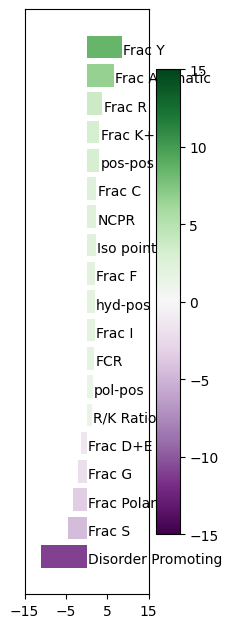

In [18]:
plt.style.use('default')

sigfeat=[]
sigspval=[]
for v in range(0,len(pvallkslog)):
    if pvallkslog[v]!=0:
        sigfeat.append(myfeatidrome[v])
        sigspval.append(pvallkslog[v])
        
sort_index = np.argsort(sigspval)

ssigfeat=[]
ssigspval=[]
for s in sort_index:
    ssigfeat.append(sigfeat[s])
    ssigspval.append(sigspval[s])

print(ssigfeat)
print(ssigspval)
    
absssigspval = list(map(abs, ssigspval))

from matplotlib import cm
fig = plt.figure(figsize = (2, 0.4*len(ssigspval))) 

# If want to just use max and min of values
#colors = cm.RdBu_r((ssigspval-(-1*max(absssigspval)))/(max(absssigspval)-(-1*max(absssigspval))))
#tmp=[-1*max(absssigspval),max(absssigspval)]

# If want to set own range
minval=np.float64(-15)
maxval=np.float64(15)
colors = cm.PRGn((ssigspval-minval)/(maxval-minval))
tmp=[minval,maxval]

plot = plt.scatter(tmp, tmp, c = tmp, cmap = 'PRGn')
plt.clf()
plt.colorbar(plot)
X = np.arange(len(ssigspval))
plt.barh(X,ssigspval,color = colors)
for i, v in enumerate(ssigspval):
    if ssigspval[i]>0:
        plt.text(v + 0.25, i - 0.25, str(ssigfeat[i]), color='black')
    else:
        plt.text(0 + 0.25, i - 0.25, str(ssigfeat[i]), color='black')

plt.xticks([-15,-5,5,15])
plt.yticks([])

plt.savefig('figures/enrichment_compared_to_idrome/'+mainprotein+'_enrichment_compared_to_idrome.pdf', transparent=False, bbox_inches = "tight")

## 7.4 Compare sequence features of clusters compared to rest of the IDRome

15
15
24508
Ks_2sampResult(statistic=0.14152657635601978, pvalue=0.9248484661838965)
pol-pol
0.0
Ks_2sampResult(statistic=0.3356455035090583, pvalue=0.06825105408356899)
pol-hyd
0.0
Ks_2sampResult(statistic=0.2487786301071759, pvalue=0.3115264252708051)
pol-pos
0.0
Ks_2sampResult(statistic=0.27318426636200427, pvalue=0.21318628253501548)
pol-neg
0.0
Ks_2sampResult(statistic=0.009384690713236494, pvalue=1.0)
pol-aro
0.0
Ks_2sampResult(statistic=0.14656438713889341, pvalue=0.9042125817417863)
pol-ala
0.0
Ks_2sampResult(statistic=0.20691202872531422, pvalue=0.542318435790926)
pol-pro
0.0
Ks_2sampResult(statistic=0.09319949948316197, pvalue=0.9994666242517759)
pol-gly
0.0
Ks_2sampResult(statistic=0.3530275828300963, pvalue=0.04767092330008069)
hyd-hyd
-1.321746436488167


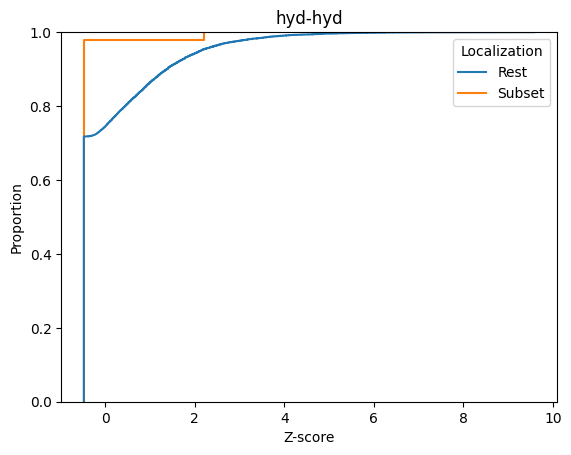

Ks_2sampResult(statistic=0.1985882160927044, pvalue=0.595474965206493)
hyd-pos
0.0
Ks_2sampResult(statistic=0.17190849246504541, pvalue=0.7674753764063214)
hyd-neg
0.0
Ks_2sampResult(statistic=0.00208095315815244, pvalue=1.0)
hyd-aro
0.0
Ks_2sampResult(statistic=0.08703280561449322, pvalue=0.9998577640805828)
hyd-ala
0.0
Ks_2sampResult(statistic=0.17186224906153091, pvalue=0.7677611538786937)
hyd-pro
0.0
Ks_2sampResult(statistic=0.08927697078504981, pvalue=0.9997622122405766)
hyd-gly
0.0
Ks_2sampResult(statistic=0.2911783907295577, pvalue=0.15734248699820272)
pos-pos
0.0
Ks_2sampResult(statistic=0.2854251672923127, pvalue=0.17376681351905826)
pos-neg
0.0
Ks_2sampResult(statistic=0.0048147543659213315, pvalue=1.0)
pos-aro
0.0
Ks_2sampResult(statistic=0.08454382242533054, pvalue=0.9999234941010523)
pos-ala
0.0
Ks_2sampResult(statistic=0.09735596539905338, pvalue=0.9988729878127116)
pos-pro
0.0
Ks_2sampResult(statistic=0.08744083564550353, pvalue=0.999843356823637)
pos-gly
0.0
Ks_2sampRes

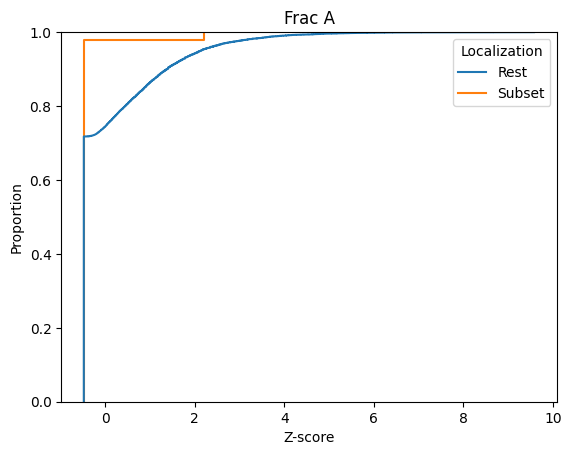

Ks_2sampResult(statistic=0.3237364670039715, pvalue=0.0863653108301456)
Frac C
0.0
Ks_2sampResult(statistic=0.6046814645557914, pvalue=3.4680482446775705e-05)
Frac D
4.459914869600812


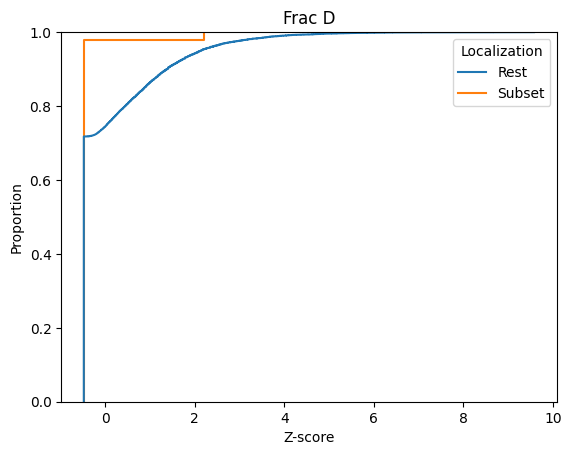

Ks_2sampResult(statistic=0.7486181382949785, pvalue=1.008690811416337e-07)
Frac E
6.996241935322598


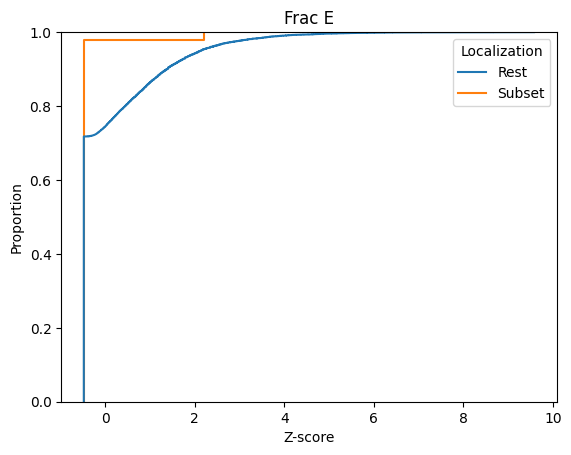

Ks_2sampResult(statistic=0.48539796529024537, pvalue=0.0017106790744781037)
Frac F
-2.7668314570024513


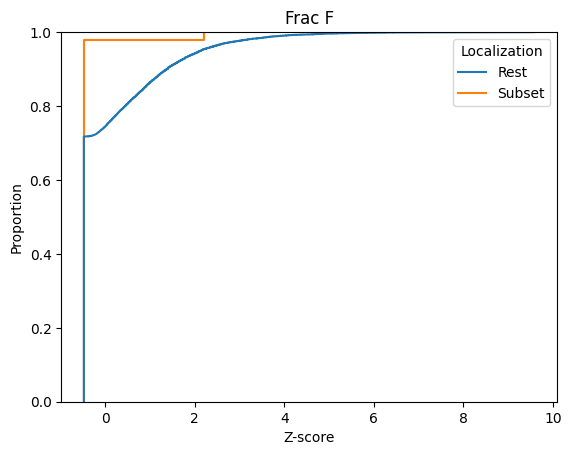

Ks_2sampResult(statistic=0.24334639029432564, pvalue=0.33717159775608335)
Frac G
0.0
Ks_2sampResult(statistic=0.4714950220336217, pvalue=0.002549137722097964)
Frac H
-2.593606700297141


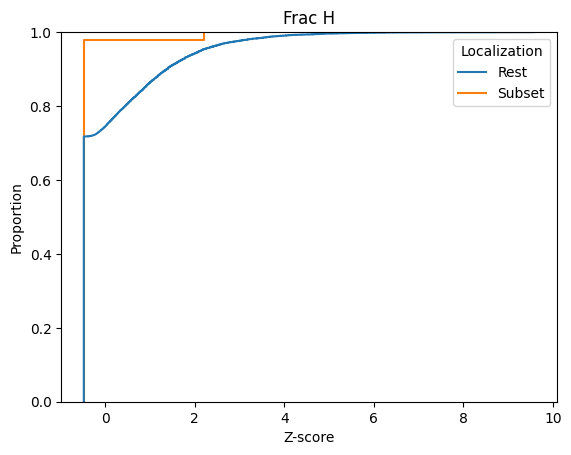

Ks_2sampResult(statistic=0.4183287089929819, pvalue=0.010529136317230911)
Frac I
-1.9776072516107468


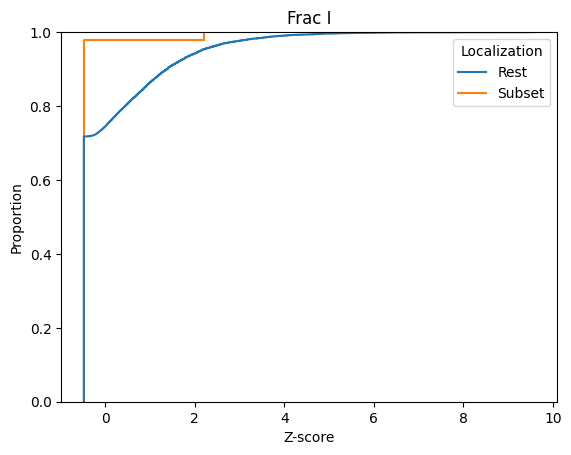

Ks_2sampResult(statistic=0.5111609814482345, pvalue=0.0007922570451081837)
Frac K
3.101133890177416


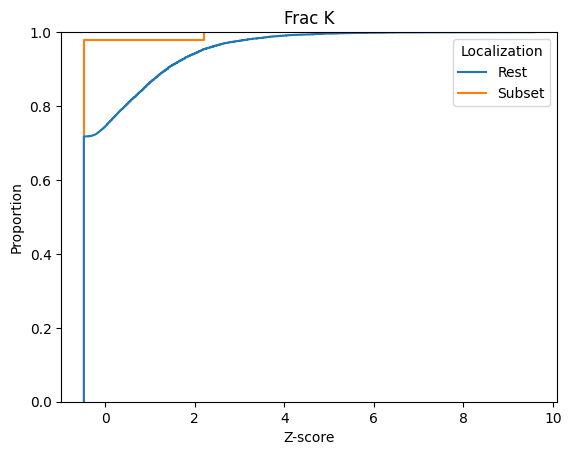

Ks_2sampResult(statistic=0.533953538980469, pvalue=0.0003878807787824992)
Frac L
-3.411301741089618


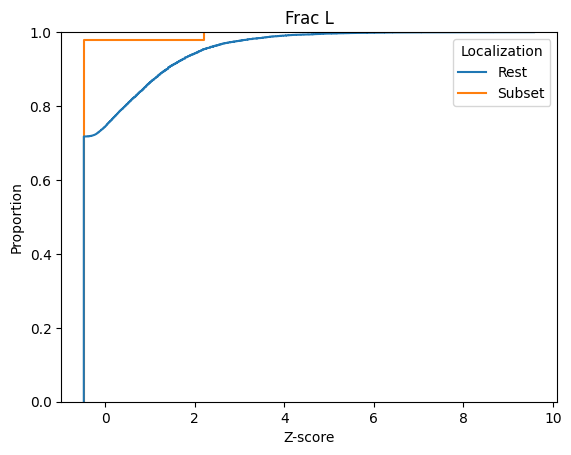

Ks_2sampResult(statistic=0.5343207660083782, pvalue=0.0003833453361996032)
Frac M
-3.4164098160261056


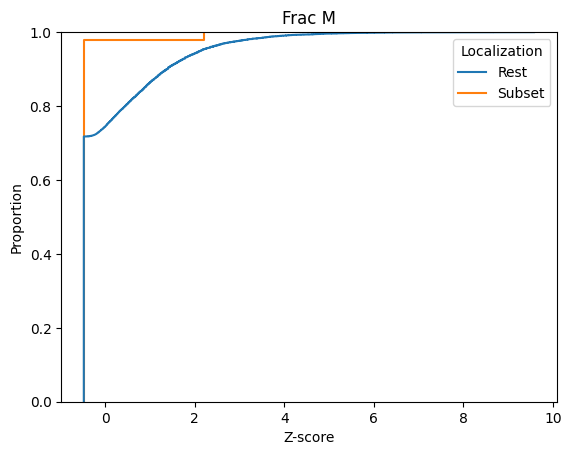

Ks_2sampResult(statistic=0.26876666122626625, pvalue=0.22898436181592685)
Frac N
0.0
Ks_2sampResult(statistic=0.4308307491431369, pvalue=0.0076587932426262165)
Frac P
-2.115839654565205


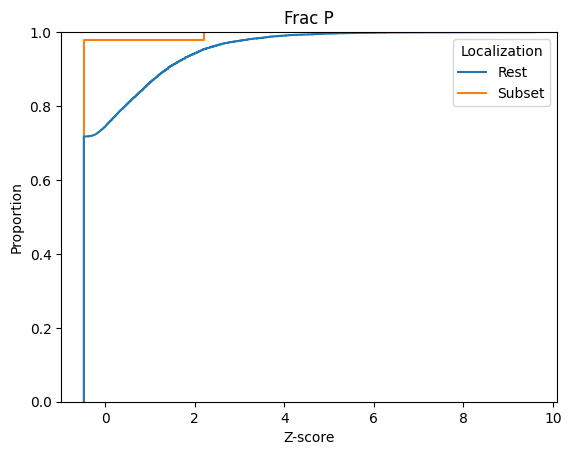

Ks_2sampResult(statistic=0.2916761873673903, pvalue=0.1559816660069444)
Frac Q
0.0
Ks_2sampResult(statistic=0.5162858386377238, pvalue=0.0006765571799842797)
Frac R
-3.169695492632912


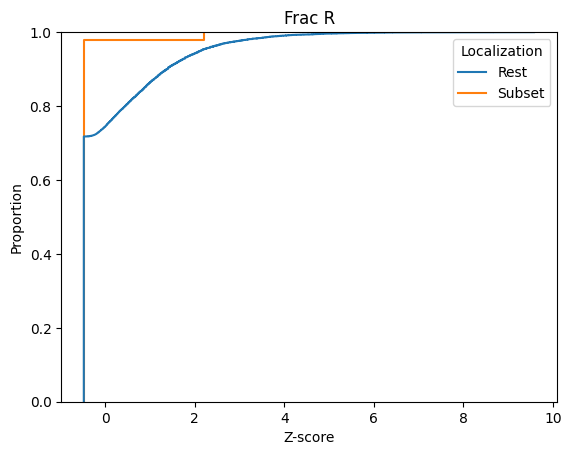

Ks_2sampResult(statistic=0.37328763396986014, pvalue=0.030665740824577934)
Frac S
1.513346539140846


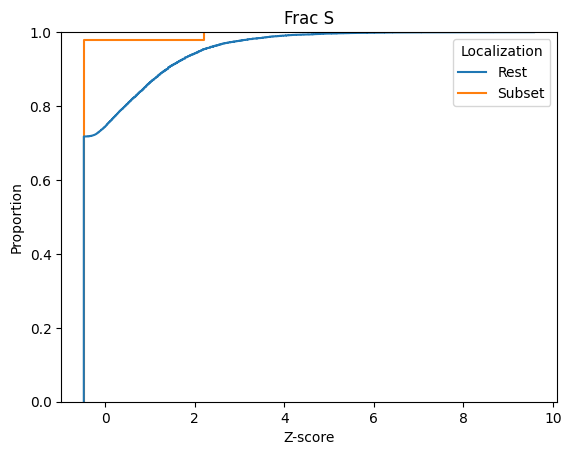

Ks_2sampResult(statistic=0.3037457156846744, pvalue=0.1257760245258238)
Frac T
0.0
Ks_2sampResult(statistic=0.3040966215113432, pvalue=0.1249748509038812)
Frac V
0.0
Ks_2sampResult(statistic=0.289089276970785, pvalue=0.16315713944379065)
Frac W
0.0
Ks_2sampResult(statistic=0.3505440400413471, pvalue=0.05023478804653938)
Frac Y
0.0
Ks_2sampResult(statistic=0.31125074805505687, pvalue=0.1095307104448768)
Frac K+R
0.0
Ks_2sampResult(statistic=0.8088841738751972, pvalue=6.047295706949001e-09)
Frac D+E
8.218438794291982


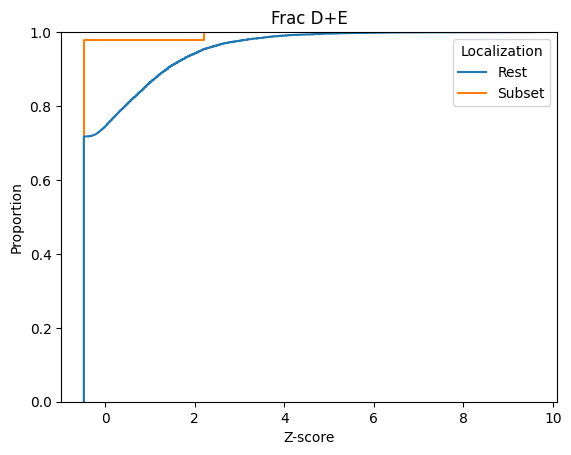

Ks_2sampResult(statistic=0.3661770306294544, pvalue=0.03590184293441143)
Frac Polar
-1.4448832573909747


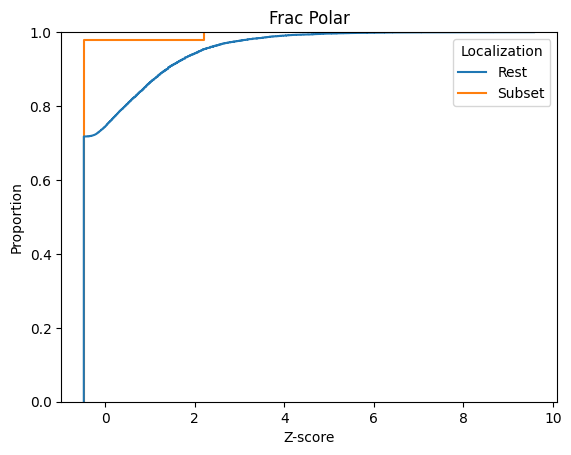

Ks_2sampResult(statistic=0.6005385996409336, pvalue=4.028089783446369e-05)
Frac Aliphatic
-4.394900857874934


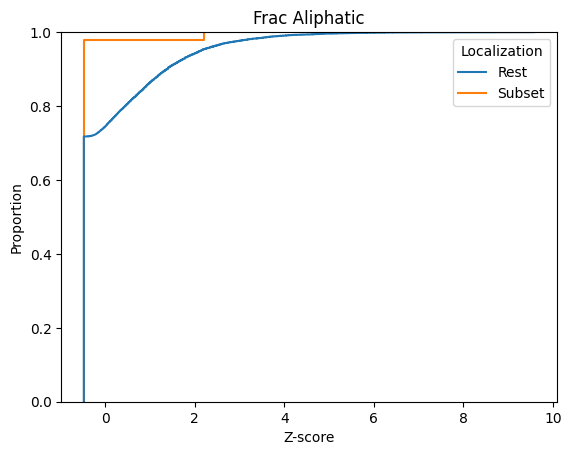

Ks_2sampResult(statistic=0.6353952450900386, pvalue=1.1070153967999985e-05)
Frac Aromatic
-4.955846338742978


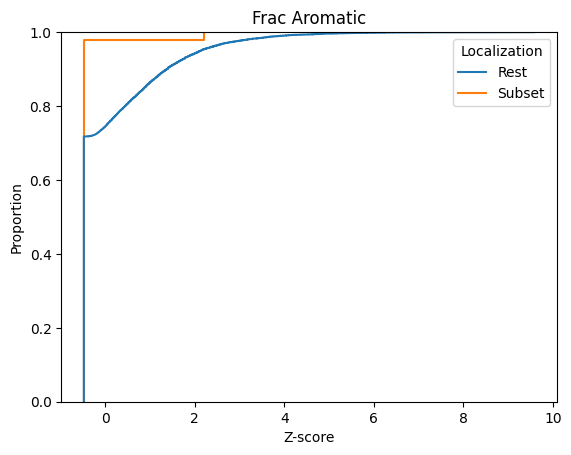

Ks_2sampResult(statistic=0.4833931777378815, pvalue=0.001813251031075044)
R/K Ratio
-2.741542066911811


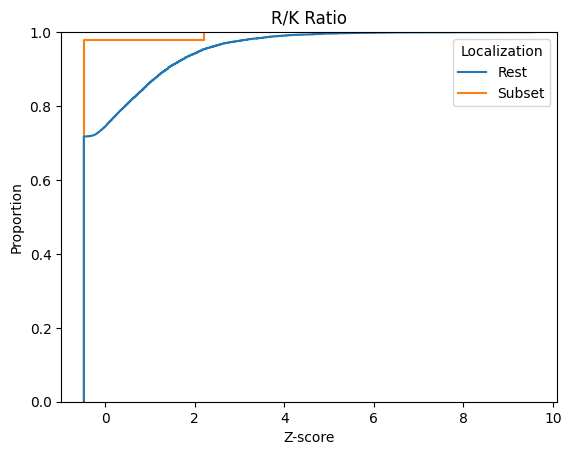

Ks_2sampResult(statistic=0.2053479136064415, pvalue=0.5521910176182137)
E/D Ratio
0.0
Ks_2sampResult(statistic=0.6473151623959523, pvalue=6.999503131846512e-06)
Frac Chain Expanding
5.154932787808038


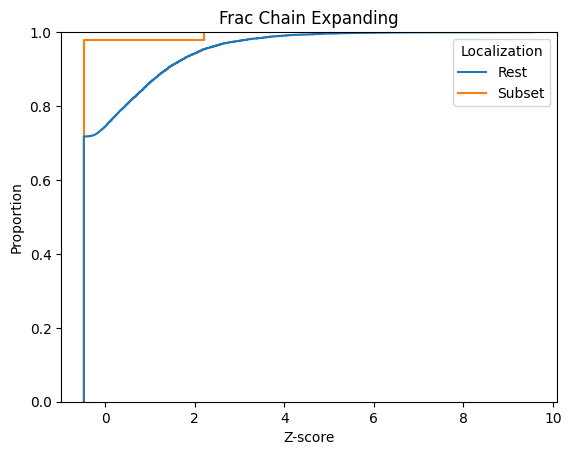

Ks_2sampResult(statistic=0.7322098906479517, pvalue=2.0899521833319568e-07)
FCR
6.679863650134226


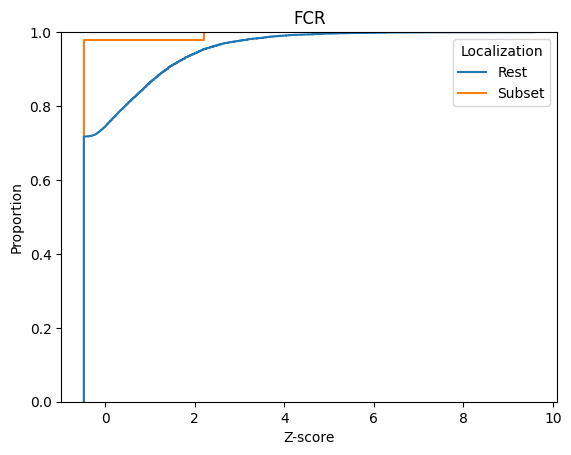

Ks_2sampResult(statistic=0.7463386105217344, pvalue=1.1171989252781759e-07)
NCPR
-6.951869490752972


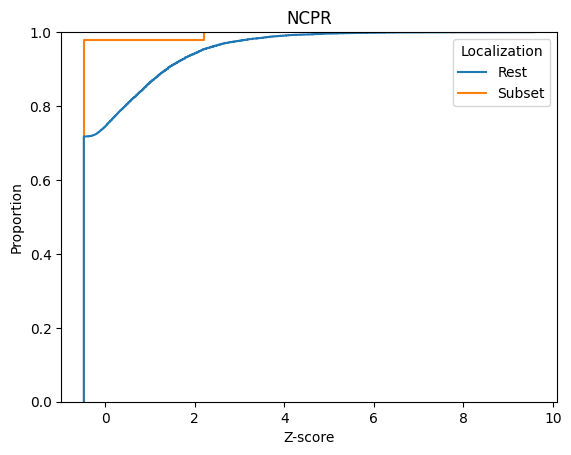

Ks_2sampResult(statistic=0.7427833088515314, pvalue=1.309382656936886e-07)
Hydrophobicity
-6.882933415702468


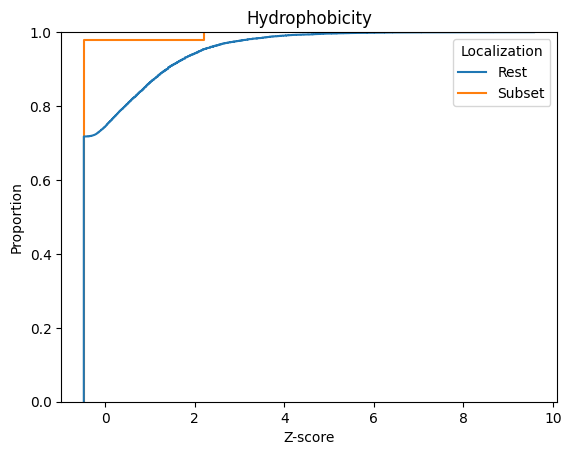

Ks_2sampResult(statistic=0.7073717425602525, pvalue=6.105446879273696e-07)
Disorder Promoting
6.214282543004951


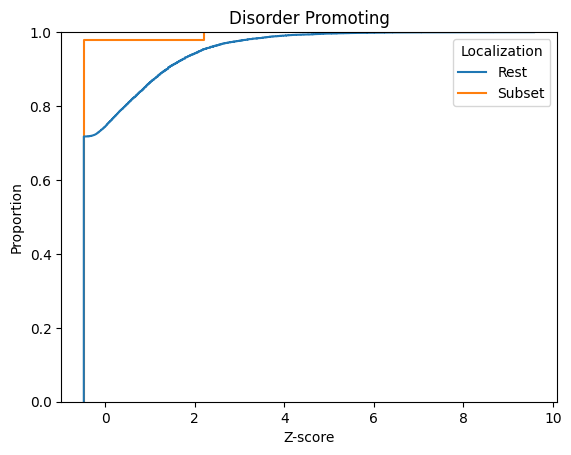

Ks_2sampResult(statistic=0.5665252162559165, pvalue=0.00013242581542888862)
Iso point
-3.878027344160336


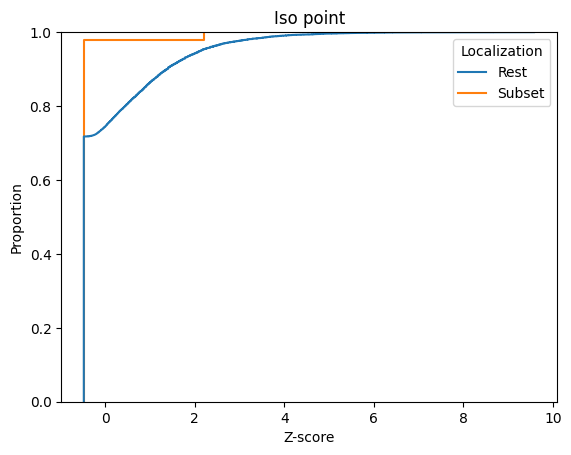

Ks_2sampResult(statistic=0.2771258364615635, pvalue=0.1998064724945785)
PPII
0.0
Ks_2sampResult(statistic=0.10539415700995591, pvalue=0.9962783516655462)
A Patch
0.0
Ks_2sampResult(statistic=8.160600620210623e-05, pvalue=1.0)
C Patch
0.0
Ks_2sampResult(statistic=0.06397366846199881, pvalue=0.9999999812878234)
D Patch
0.0
Ks_2sampResult(statistic=0.24116478972852406, pvalue=0.3478584606881073)
E Patch
0.0
Ks_2sampResult(statistic=0.00020401501550515455, pvalue=1.0)
F Patch
0.0
Ks_2sampResult(statistic=0.1302839889015831, pvalue=0.9610385719459651)
G Patch
0.0
Ks_2sampResult(statistic=0.010486371796964211, pvalue=1.0)
H Patch
0.0
Ks_2sampResult(statistic=0.00028562102170714976, pvalue=1.0)
I Patch
0.0
Ks_2sampResult(statistic=0.09054186388118168, pvalue=0.9996877542561795)
K Patch
0.0
Ks_2sampResult(statistic=0.013913824057450674, pvalue=1.0)
L Patch
0.0
Ks_2sampResult(statistic=0.0010608780806267148, pvalue=1.0)
M Patch
0.0
Ks_2sampResult(statistic=0.008650236657417931, pvalue=1.0)
N Pa

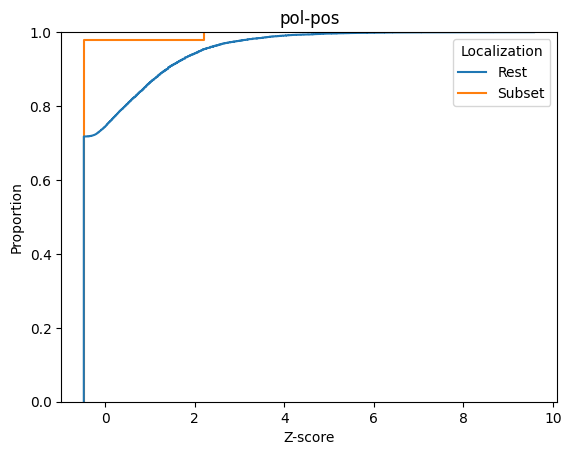

Ks_2sampResult(statistic=0.37942712583646154, pvalue=0.35358057139465615)
pol-neg
0.0
Ks_2sampResult(statistic=0.009384690713236494, pvalue=1.0)
pol-aro
0.0
Ks_2sampResult(statistic=0.1235922963930145, pvalue=0.9999882340057297)
pol-ala
0.0
Ks_2sampResult(statistic=0.4478401610358522, pvalue=0.1801930156540636)
pol-pro
0.0
Ks_2sampResult(statistic=0.15986616614982863, pvalue=0.9979516658804731)
pol-gly
0.0
Ks_2sampResult(statistic=0.3773053696752081, pvalue=0.36033631165690966)
hyd-hyd
0.0
Ks_2sampResult(statistic=0.22225395789130076, pvalue=0.9283852082868516)
hyd-pos
0.0
Ks_2sampResult(statistic=0.2385751591317121, pvalue=0.8843438896093775)
hyd-neg
0.0
Ks_2sampResult(statistic=0.00208095315815244, pvalue=1.0)
hyd-aro
0.0
Ks_2sampResult(statistic=0.08703280561449322, pvalue=0.9999999999810111)
hyd-ala
0.0
Ks_2sampResult(statistic=0.20944181491757793, pvalue=0.9550432289492546)
hyd-pro
0.0
Ks_2sampResult(statistic=0.0924188020238289, pvalue=0.9999999996138171)
hyd-gly
0.0
Ks_2sampResu

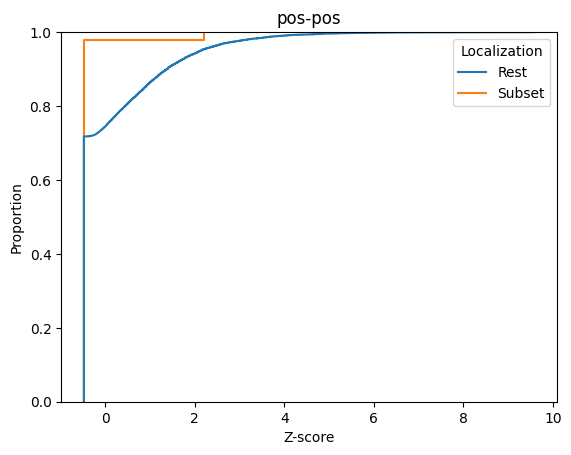

Ks_2sampResult(statistic=0.24069691529296555, pvalue=0.8778572196290608)
pos-neg
0.0
Ks_2sampResult(statistic=0.0048147543659213315, pvalue=1.0)
pos-aro
0.0
Ks_2sampResult(statistic=0.13802295848974477, pvalue=0.9998481269547711)
pos-ala
0.0
Ks_2sampResult(statistic=0.6520183885533974, pvalue=0.012189990048921169)
pos-pro
1.9139966489099518


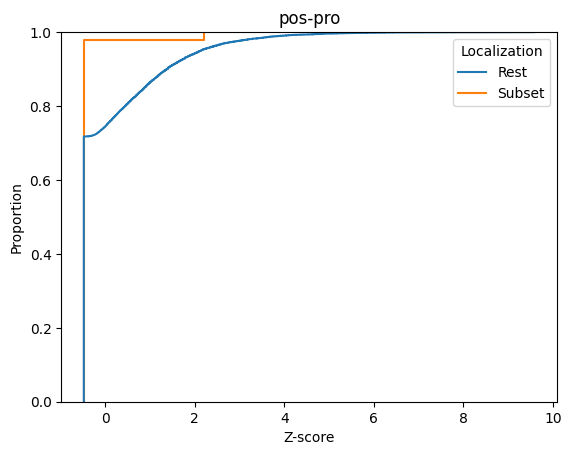

Ks_2sampResult(statistic=0.08744083564550353, pvalue=0.9999999999756632)
pos-gly
0.0
Ks_2sampResult(statistic=0.40611228986453407, pvalue=0.2757830272258295)
neg-neg
0.0
Ks_2sampResult(statistic=0.00485555736902236, pvalue=1.0)
neg-aro
0.0
Ks_2sampResult(statistic=0.08287089929818836, pvalue=0.9999999999987821)
neg-ala
0.0
Ks_2sampResult(statistic=0.17227027909254122, pvalue=0.9941907371828179)
neg-pro
0.0
Ks_2sampResult(statistic=0.09266362004243511, pvalue=0.9999999995626504)
neg-gly
0.0
Ks_2sampResult(statistic=0.010935204831075566, pvalue=1.0)
aro-aro
0.0
Ks_2sampResult(statistic=0.0013464991023339318, pvalue=1.0)
aro-ala
0.0
Ks_2sampResult(statistic=0.004692345356618247, pvalue=1.0)
aro-pro
0.0
Ks_2sampResult(statistic=0.005222784396931615, pvalue=1.0)
aro-gly
0.0
Ks_2sampResult(statistic=0.14516348403242474, pvalue=0.9995930944154733)
ala-ala
0.0
Ks_2sampResult(statistic=0.1645449105054132, pvalue=0.9968753677238231)
ala-pro
0.0
Ks_2sampResult(statistic=0.06034764158642081, pvalu

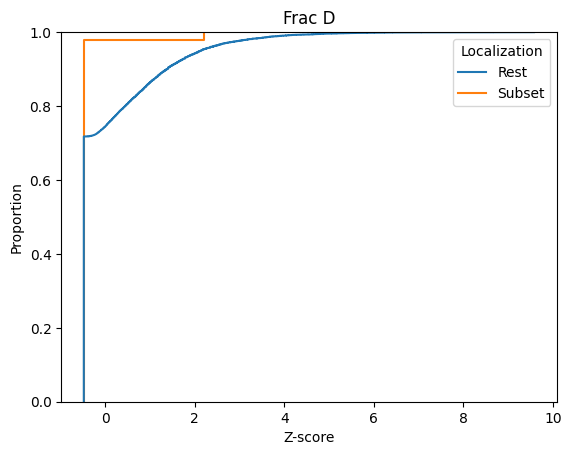

Ks_2sampResult(statistic=0.7147870083238126, pvalue=0.004355143084777493)
Frac E
-2.360997572020611


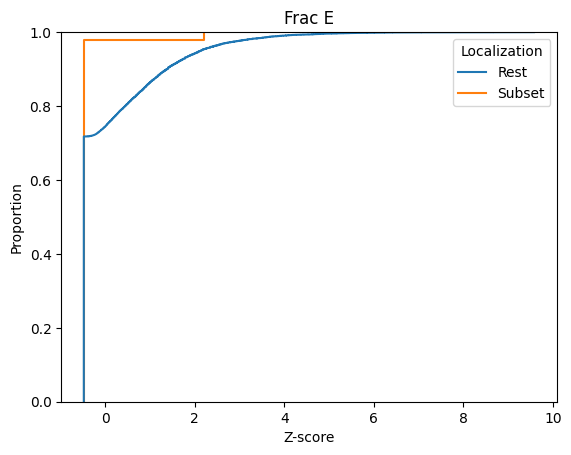

Ks_2sampResult(statistic=0.552064631956912, pvalue=0.05164927177791842)
Frac F
0.0
Ks_2sampResult(statistic=0.37667972362765895, pvalue=0.36234421477221496)
Frac G
0.0
Ks_2sampResult(statistic=0.35437408193243025, pvalue=0.4384976581094237)
Frac H
0.0
Ks_2sampResult(statistic=0.6183287089929819, pvalue=0.02036992678855216)
Frac I
-1.6910105318925677


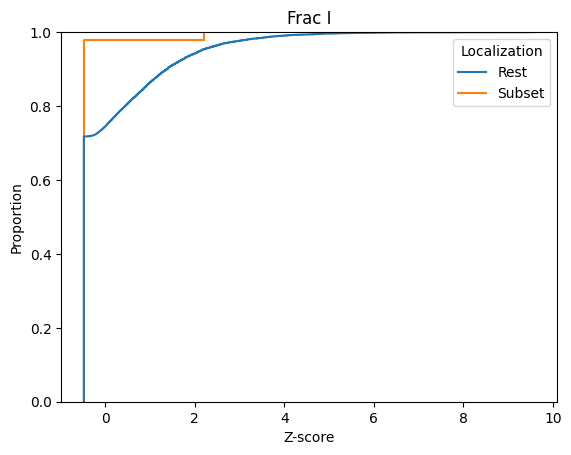

Ks_2sampResult(statistic=0.7778276481149012, pvalue=0.0014084492091885053)
Frac K
2.8512588097125593


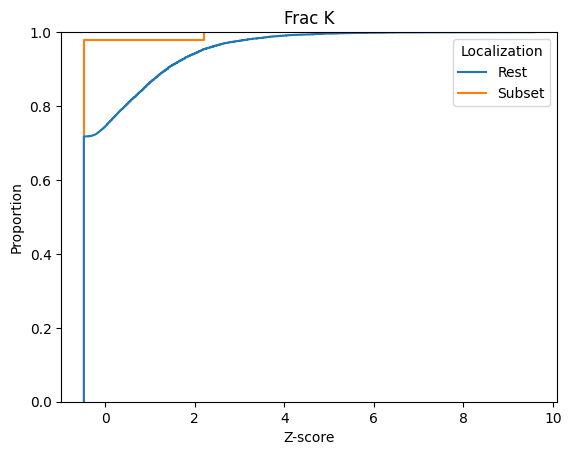

Ks_2sampResult(statistic=0.929084380610413, pvalue=6.36131111188592e-05)
Frac L
-4.19645336391549


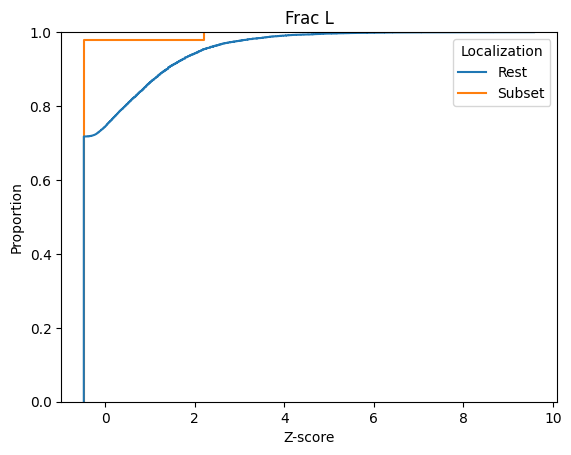

Ks_2sampResult(statistic=0.6009874326750448, pvalue=0.026251688357989224)
Frac M
-1.5808427600302661


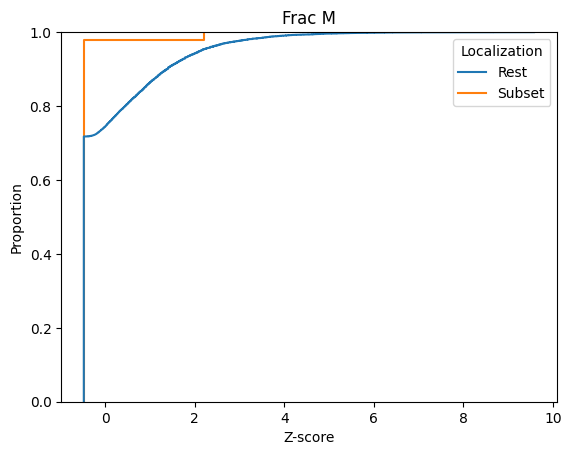

Ks_2sampResult(statistic=0.5888417387519722, pvalue=0.031221342920554552)
Frac N
1.5055484206059766


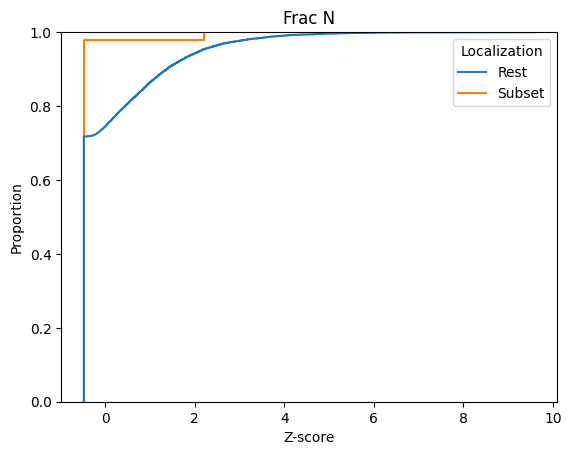

Ks_2sampResult(statistic=0.5333632555356074, pvalue=0.06588994722644183)
Frac P
0.0
Ks_2sampResult(statistic=0.894483433980741, pvalue=0.0001356123364013665)
Frac Q
-3.867700801712718


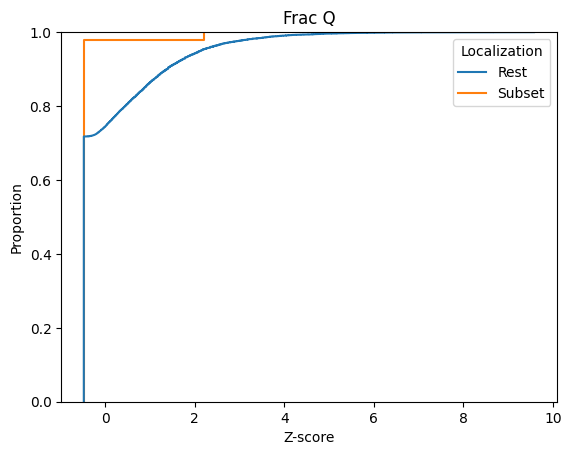

Ks_2sampResult(statistic=0.764525869103966, pvalue=0.0018015033975894938)
Frac R
2.744364914472316


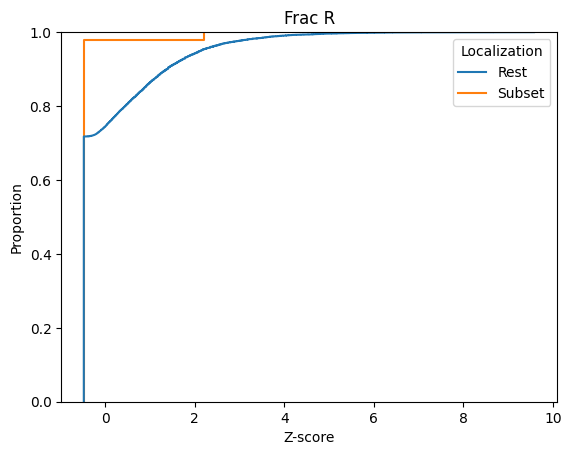

Ks_2sampResult(statistic=0.4732876339698602, pvalue=0.1360783518043194)
Frac S
0.0
Ks_2sampResult(statistic=0.5178581143572167, pvalue=0.08011807659817363)
Frac T
0.0
Ks_2sampResult(statistic=0.8362167455524727, pvalue=0.0004546874146119266)
Frac V
-3.3422870665563527


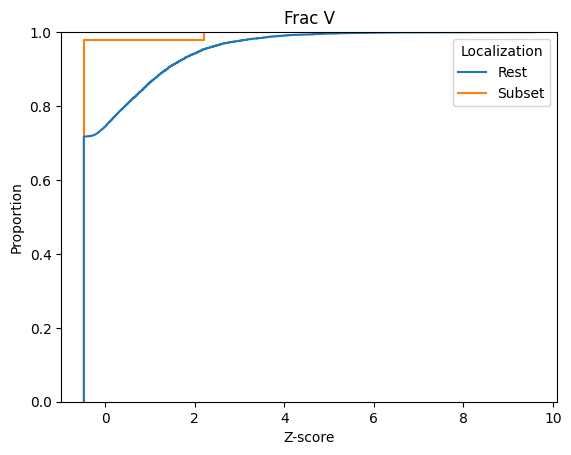

Ks_2sampResult(statistic=0.289089276970785, pvalue=0.697821719251873)
Frac W
0.0
Ks_2sampResult(statistic=0.4589929818834666, pvalue=0.15963933121903073)
Frac Y
0.0
Ks_2sampResult(statistic=0.8173657581197976, pvalue=0.0006608841658507208)
Frac K+R
3.1798746532832034


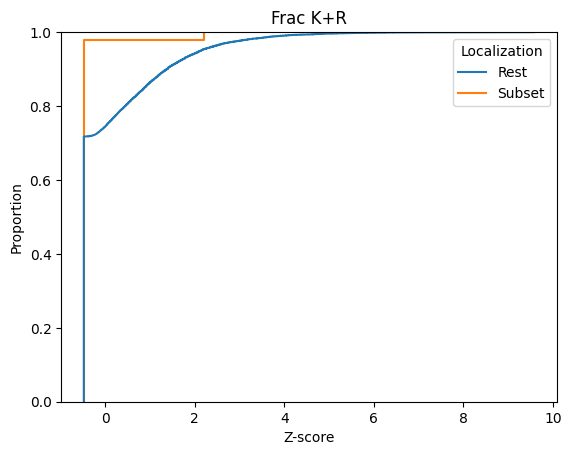

Ks_2sampResult(statistic=0.7182280615853327, pvalue=0.00410497222045165)
Frac D+E
-2.3866897775324527


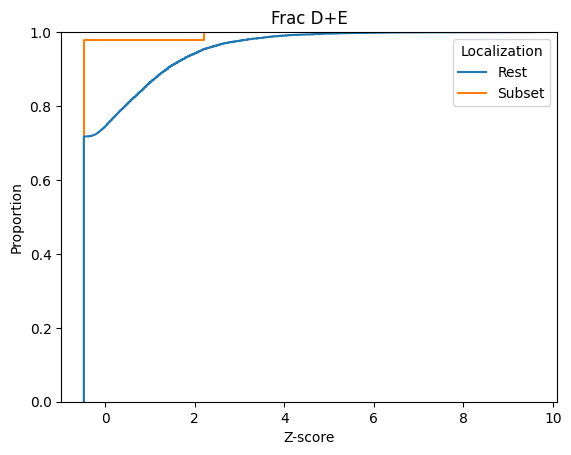

Ks_2sampResult(statistic=0.35244273978564816, pvalue=0.445491379503368)
Frac Polar
0.0
Ks_2sampResult(statistic=0.858372776236331, pvalue=0.0002897956232570176)
Frac Aliphatic
-3.5379081779044563


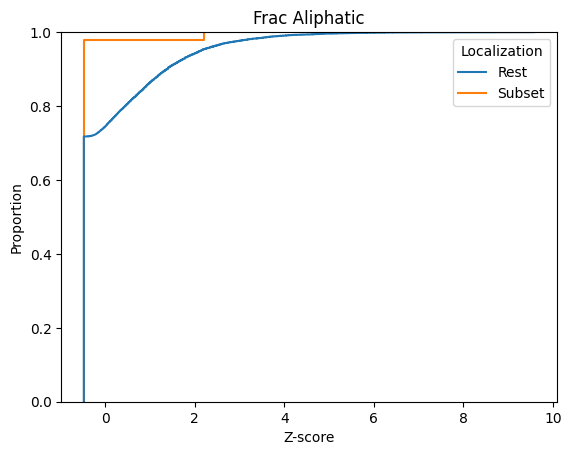

Ks_2sampResult(statistic=0.27525705891953645, pvalue=0.7537127420233521)
Frac Aromatic
0.0
Ks_2sampResult(statistic=0.40909090909090906, pvalue=0.2679244627637587)
R/K Ratio
0.0
Ks_2sampResult(statistic=0.30353354006854905, pvalue=0.6382673564632619)
E/D Ratio
0.0
Ks_2sampResult(statistic=0.8473151623959524, pvalue=0.0003633805359997085)
Frac Chain Expanding
3.439638338817495


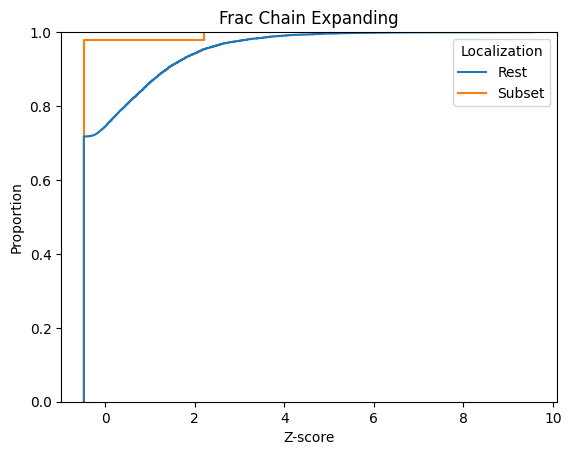

Ks_2sampResult(statistic=0.5127985419726893, pvalue=0.0852893076348556)
FCR
0.0
Ks_2sampResult(statistic=0.9313693487840705, pvalue=6.045015576849077e-05)
NCPR
4.218602575707943


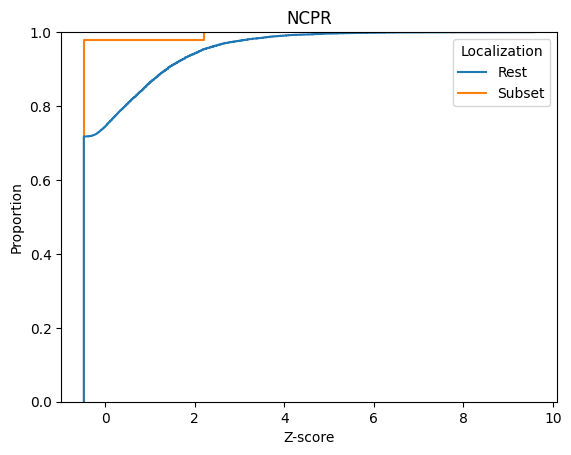

Ks_2sampResult(statistic=0.8966051901419945, pvalue=0.0001295683407331937)
Hydrophobicity
-3.887501102821417


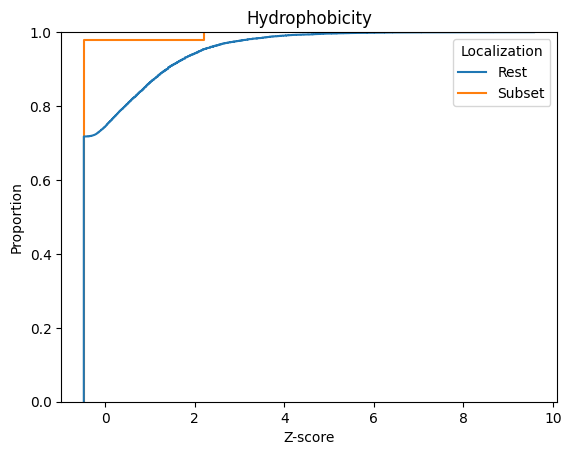

Ks_2sampResult(statistic=0.9662559164354496, pvalue=2.7319316284363633e-05)
Disorder Promoting
4.563530173864725


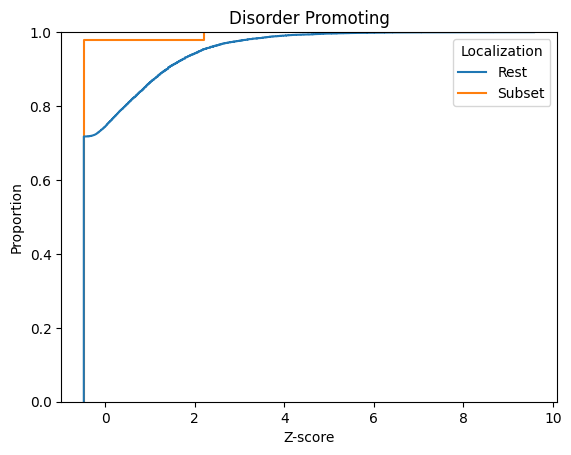

Ks_2sampResult(statistic=0.8310347641586421, pvalue=0.0005043451232547092)
Iso point
3.2972721742088074


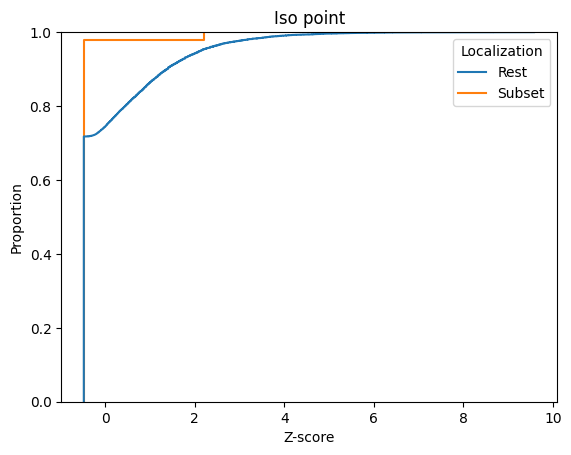

Ks_2sampResult(statistic=0.6106849464120558, pvalue=0.022800058055753646)
PPII
1.64206404715475


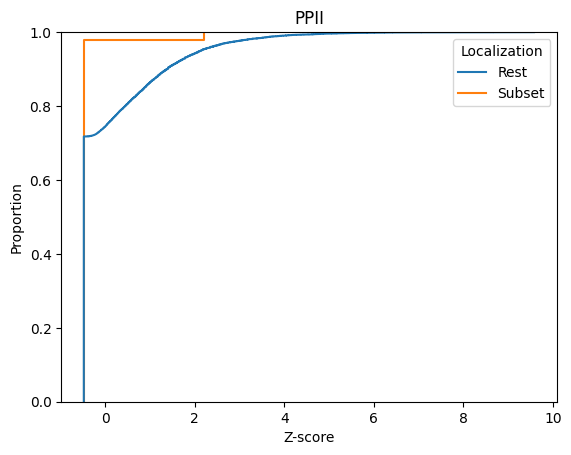

Ks_2sampResult(statistic=0.10539415700995591, pvalue=0.9999999116635646)
A Patch
0.0
Ks_2sampResult(statistic=8.160600620210623e-05, pvalue=1.0)
C Patch
0.0
Ks_2sampResult(statistic=0.04867798269952672, pvalue=1.0)
D Patch
0.0
Ks_2sampResult(statistic=0.16504814754365926, pvalue=0.9967374328499886)
E Patch
0.0
Ks_2sampResult(statistic=0.00020401501550515455, pvalue=1.0)
F Patch
0.0
Ks_2sampResult(statistic=0.1302839889015831, pvalue=0.9999570483127102)
G Patch
0.0
Ks_2sampResult(statistic=0.010486371796964211, pvalue=1.0)
H Patch
0.0
Ks_2sampResult(statistic=0.00028562102170714976, pvalue=1.0)
I Patch
0.0
Ks_2sampResult(statistic=0.1623007453348566, pvalue=0.9974361023861664)
K Patch
0.0
Ks_2sampResult(statistic=0.013913824057450674, pvalue=1.0)
L Patch
0.0
Ks_2sampResult(statistic=0.0010608780806267148, pvalue=1.0)
M Patch
0.0
Ks_2sampResult(statistic=0.008650236657417931, pvalue=1.0)
N Patch
0.0
Ks_2sampResult(statistic=0.6463059681192536, pvalue=0.0133243364269602)
P Patch
1.8753544

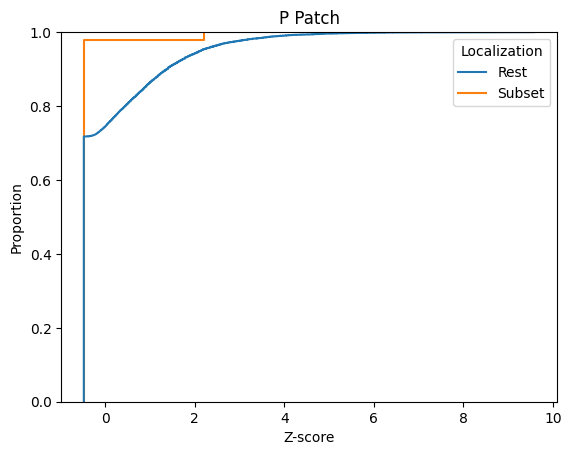

Ks_2sampResult(statistic=0.04312877427778683, pvalue=1.0)
Q Patch
0.0
Ks_2sampResult(statistic=0.08833850171372615, pvalue=0.9999999999585008)
R Patch
0.0
Ks_2sampResult(statistic=0.2823975844622164, pvalue=0.7250948437759066)
S Patch
0.0
Ks_2sampResult(statistic=0.036396278766117174, pvalue=1.0)
T Patch
0.0
Ks_2sampResult(statistic=0.004325118328708966, pvalue=1.0)
V Patch
0.0
Ks_2sampResult(statistic=0.0006120450465154637, pvalue=1.0)
Y Patch
0.0
Ks_2sampResult(statistic=0.032315978456014416, pvalue=1.0)
RG Frac
0.0
13
13
24508
Ks_2sampResult(statistic=0.3361979133971953, pvalue=0.10601244523702338)
pol-pol
0.0
Ks_2sampResult(statistic=0.20367917540269426, pvalue=0.6538346268332802)
pol-hyd
0.0
Ks_2sampResult(statistic=0.14940176520068804, pvalue=0.9338635335922861)
pol-pos
0.0
Ks_2sampResult(statistic=0.23503157524701512, pvalue=0.46959239115339885)
pol-neg
0.0
Ks_2sampResult(statistic=0.009384690713236494, pvalue=1.0)
pol-aro
0.0
Ks_2sampResult(statistic=0.09084631705816626, pvalue

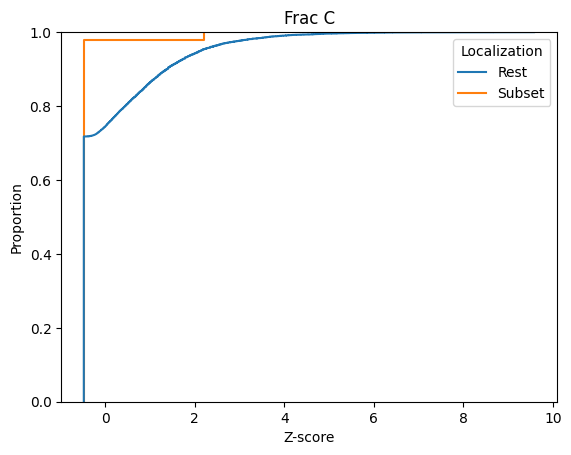

Ks_2sampResult(statistic=0.4867327466070734, pvalue=0.004239901733202765)
Frac D
2.3726442087898953


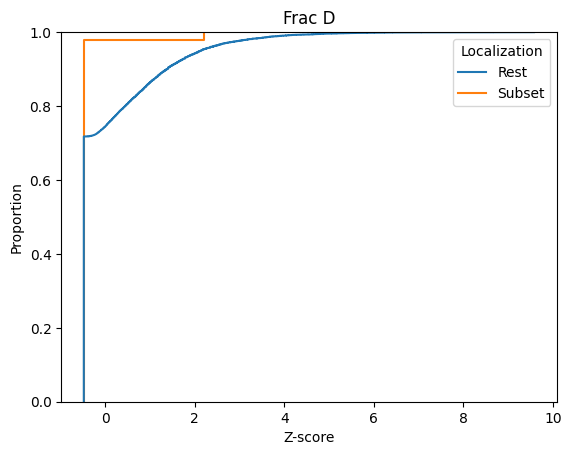

Ks_2sampResult(statistic=0.20306713035617885, pvalue=0.6575558658205123)
Frac E
0.0
Ks_2sampResult(statistic=0.33030658748791597, pvalue=0.11739454916423668)
Frac F
0.0
Ks_2sampResult(statistic=0.40416943917841586, pvalue=0.028673543310304927)
Frac G
-1.5425186361421548


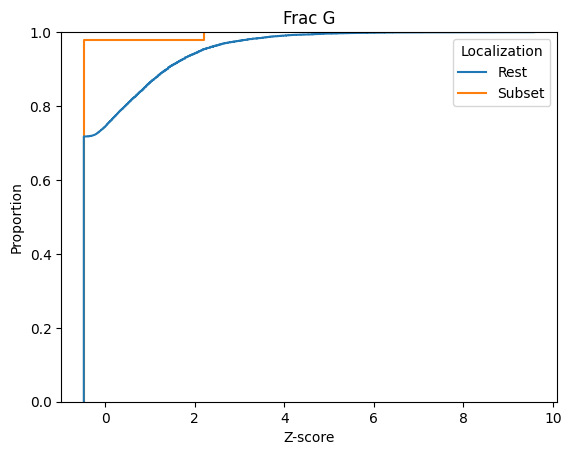

Ks_2sampResult(statistic=0.44072579126439093, pvalue=0.012850205553754507)
Frac H
-1.8910899252395101


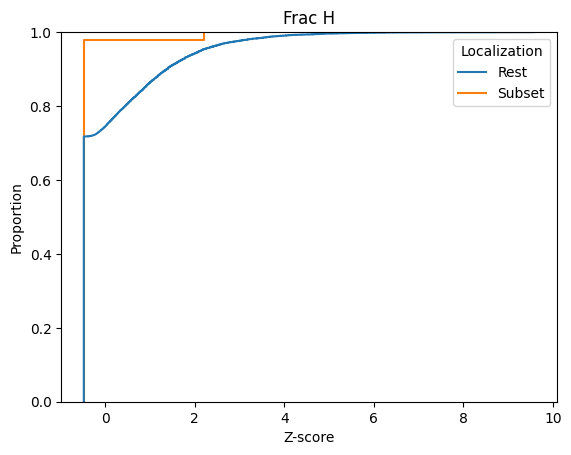

Ks_2sampResult(statistic=0.6796681774240123, pvalue=1.223567264522776e-05)
Frac I
4.912372150702804


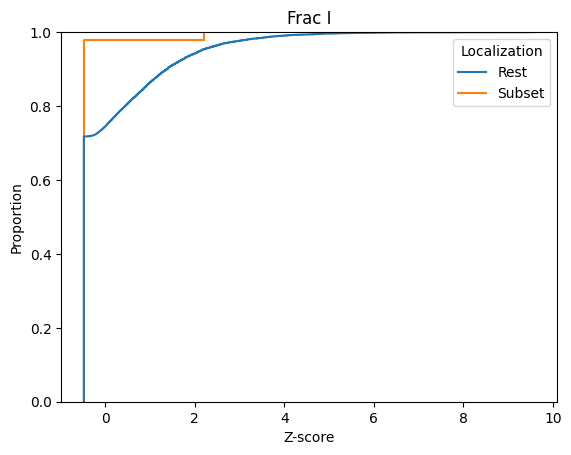

Ks_2sampResult(statistic=0.26580331697028287, pvalue=0.3176268781133779)
Frac K
0.0
Ks_2sampResult(statistic=0.29292789795482793, pvalue=0.21483382621887445)
Frac L
0.0
Ks_2sampResult(statistic=0.44714127882889104, pvalue=0.011082195533488116)
Frac M
-1.955374191446846


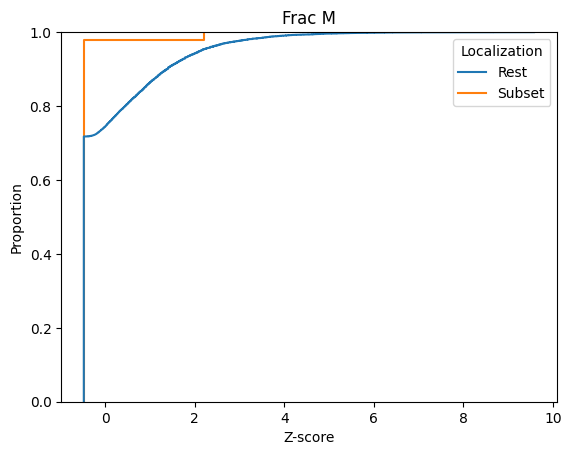

Ks_2sampResult(statistic=0.44781609772633113, pvalue=0.010909629713236042)
Frac N
1.9621899896708135


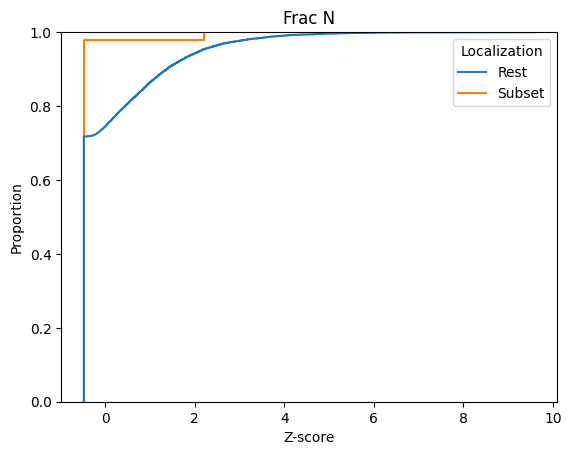

Ks_2sampResult(statistic=0.36929228760467536, pvalue=0.05779842452448471)
Frac P
0.0
Ks_2sampResult(statistic=0.4147531104443134, pvalue=0.022891104730725833)
Frac Q
-1.640333247653945


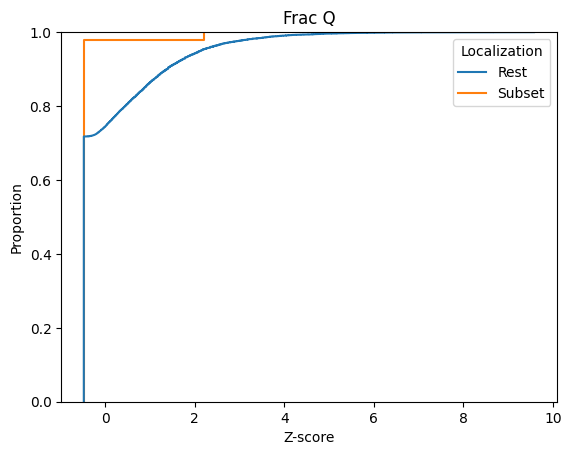

Ks_2sampResult(statistic=0.2752601976120827, pvalue=0.2784531393291873)
Frac R
0.0
Ks_2sampResult(statistic=0.19603959774516327, pvalue=0.7001492184838496)
Frac S
0.0
Ks_2sampResult(statistic=0.3010163086464703, pvalue=0.18969440470271245)
Frac T
0.0
Ks_2sampResult(statistic=0.3194812368959586, pvalue=0.14091887546247128)
Frac V
0.0
Ks_2sampResult(statistic=0.14401263009880605, pvalue=0.9503930838376253)
Frac W
0.0
Ks_2sampResult(statistic=0.2633645528618599, pvalue=0.3283178219048235)
Frac Y
0.0
Ks_2sampResult(statistic=0.1732464124744197, pvalue=0.8303017403777012)
Frac K+R
0.0
Ks_2sampResult(statistic=0.29401074688327833, pvalue=0.2113275046245511)
Frac D+E
0.0
Ks_2sampResult(statistic=0.34566421011663384, pvalue=0.0896471984648365)
Frac Polar
0.0
Ks_2sampResult(statistic=0.4192947985587123, pvalue=0.020745168380032302)
Frac Aliphatic
1.6830830358303264


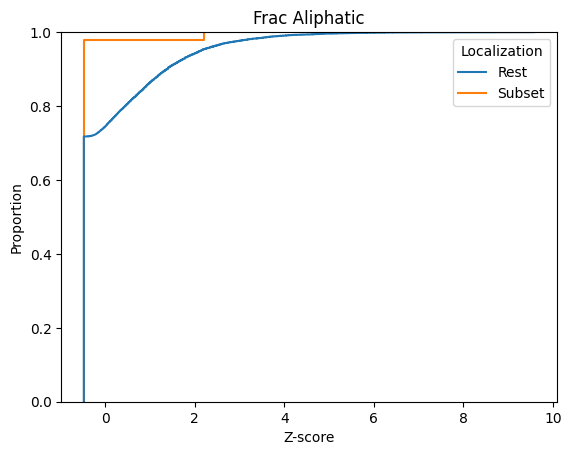

Ks_2sampResult(statistic=0.3137185973810749, pvalue=0.15491712099878968)
Frac Aromatic
0.0
Ks_2sampResult(statistic=0.27508756952203994, pvalue=0.2791357820551425)
R/K Ratio
0.0
Ks_2sampResult(statistic=0.25208409185069863, pvalue=0.380883634091201)
E/D Ratio
0.0
Ks_2sampResult(statistic=0.1550074700882601, pvalue=0.9137717274594344)
Frac Chain Expanding
0.0
Ks_2sampResult(statistic=0.27783078680744744, pvalue=0.2684298309318809)
FCR
0.0
Ks_2sampResult(statistic=0.2719865412863618, pvalue=0.2916035203845102)
NCPR
0.0
Ks_2sampResult(statistic=0.2773223186149577, pvalue=0.2703914045748795)
Hydrophobicity
0.0
Ks_2sampResult(statistic=0.5455895092340335, pvalue=0.0008742751092992257)
Disorder Promoting
-3.0583518858434218


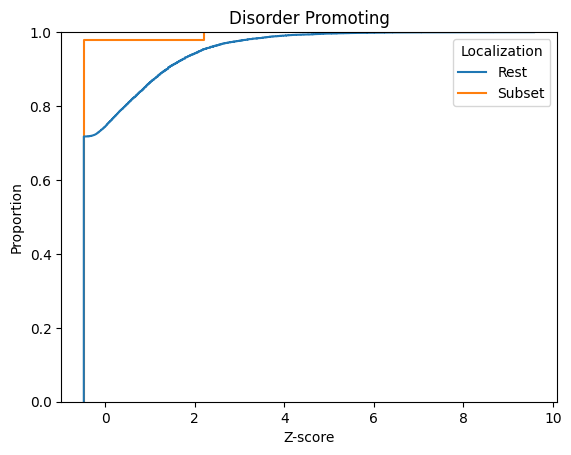

Ks_2sampResult(statistic=0.33987332236883405, pvalue=0.09938599354779623)
Iso point
0.0
Ks_2sampResult(statistic=0.1504124242005751, pvalue=0.930456525903113)
PPII
0.0
Ks_2sampResult(statistic=0.0751685477897327, pvalue=0.9999995342896919)
A Patch
0.0
Ks_2sampResult(statistic=8.160600620210623e-05, pvalue=1.0)
C Patch
0.0
Ks_2sampResult(statistic=0.04867798269952672, pvalue=0.9999999999999999)
D Patch
0.0
Ks_2sampResult(statistic=0.16504814754365926, pvalue=0.8709216567010436)
E Patch
0.0
Ks_2sampResult(statistic=0.00020401501550515455, pvalue=1.0)
F Patch
0.0
Ks_2sampResult(statistic=0.1302839889015831, pvalue=0.9801416614063541)
G Patch
0.0
Ks_2sampResult(statistic=0.010486371796964211, pvalue=1.0)
H Patch
0.0
Ks_2sampResult(statistic=0.00028562102170714976, pvalue=1.0)
I Patch
0.0
Ks_2sampResult(statistic=0.09054186388118168, pvalue=0.9999283494083094)
K Patch
0.0
Ks_2sampResult(statistic=0.013913824057450674, pvalue=1.0)
L Patch
0.0
Ks_2sampResult(statistic=0.0010608780806267148, p

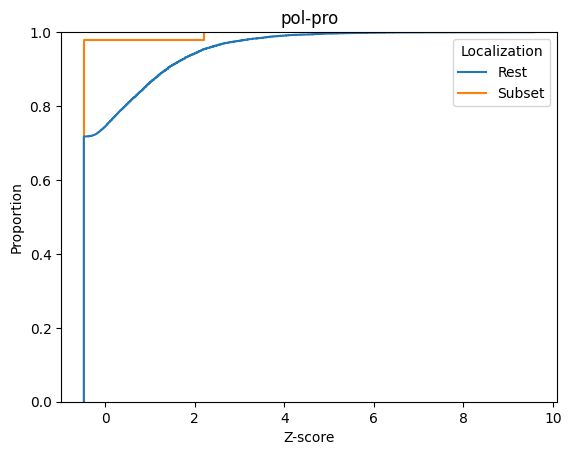

Ks_2sampResult(statistic=0.1417778810058882, pvalue=0.9564327476505415)
pol-gly
0.0
Ks_2sampResult(statistic=0.20201566835319085, pvalue=0.6639472393732297)
hyd-hyd
0.0
Ks_2sampResult(statistic=0.27477370026741665, pvalue=0.28038002903931847)
hyd-pos
0.0
Ks_2sampResult(statistic=0.2385751591317121, pvalue=0.4503048387386914)
hyd-neg
0.0
Ks_2sampResult(statistic=0.00208095315815244, pvalue=1.0)
hyd-aro
0.0
Ks_2sampResult(statistic=0.07075240737718295, pvalue=0.9999999431235614)
hyd-ala
0.0
Ks_2sampResult(statistic=0.2467828401401112, pvalue=0.4073165812034478)
hyd-pro
0.0
Ks_2sampResult(statistic=0.0924188020238289, pvalue=0.9998881721775891)
hyd-gly
0.0
Ks_2sampResult(statistic=0.2446045875130256, pvalue=0.41848658805998673)
pos-pos
0.0
Ks_2sampResult(statistic=0.24069691529296555, pvalue=0.43896070338369714)
pos-neg
0.0
Ks_2sampResult(statistic=0.0048147543659213315, pvalue=1.0)
pos-aro
0.0
Ks_2sampResult(statistic=0.08454382242533054, pvalue=0.9999860064032419)
pos-ala
0.0
Ks_2sampRe

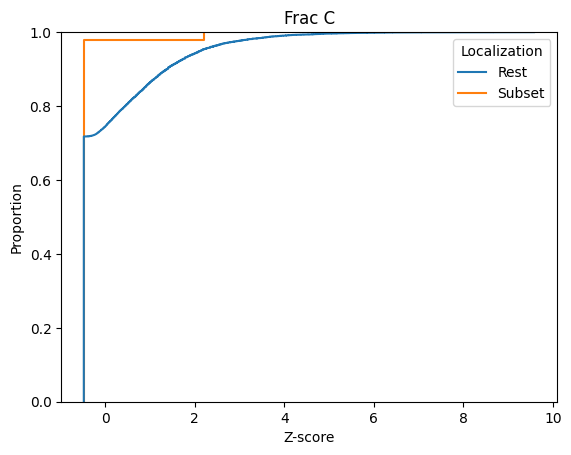

Ks_2sampResult(statistic=0.48510062648303226, pvalue=0.004418313653321151)
Frac D
-2.354743457076743


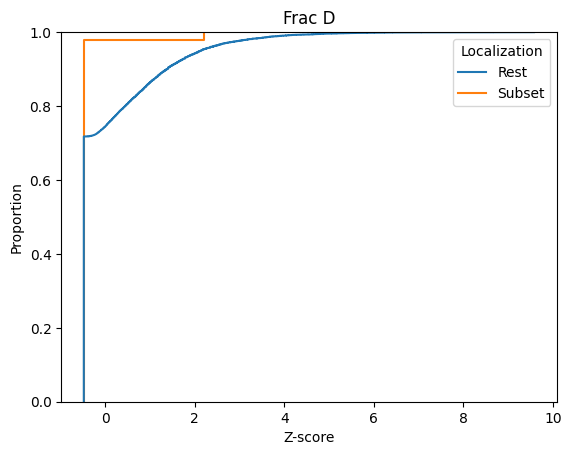

Ks_2sampResult(statistic=0.6378639314007357, pvalue=5.119468983956249e-05)
Frac E
-4.29077508380885


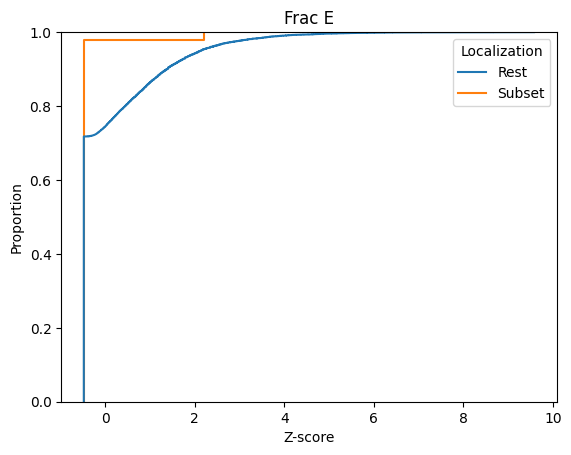

Ks_2sampResult(statistic=0.39821847811075817, pvalue=0.03246157800000229)
Frac F
-1.4886303723706589


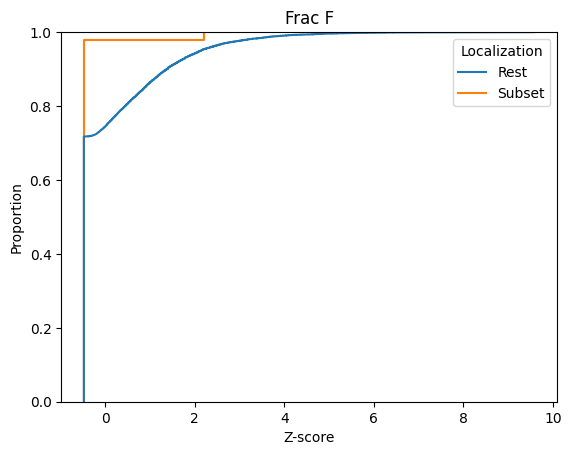

Ks_2sampResult(statistic=0.25123036747812333, pvalue=0.38506727796505696)
Frac G
0.0
Ks_2sampResult(statistic=0.36380271434131395, pvalue=0.06416969102128722)
Frac H
0.0
Ks_2sampResult(statistic=0.464482555146828, pvalue=0.0073487564116876515)
Frac I
-2.133786147886808


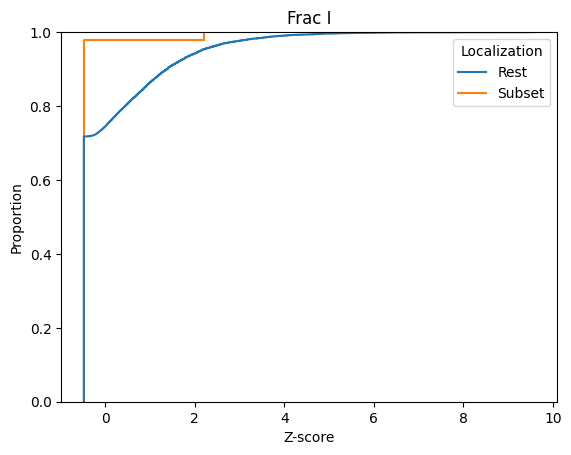

Ks_2sampResult(statistic=0.30514055065222034, pvalue=0.17778981831056934)
Frac K
0.0
Ks_2sampResult(statistic=0.4467740518009818, pvalue=0.011177136432142212)
Frac L
-1.9516694478819754


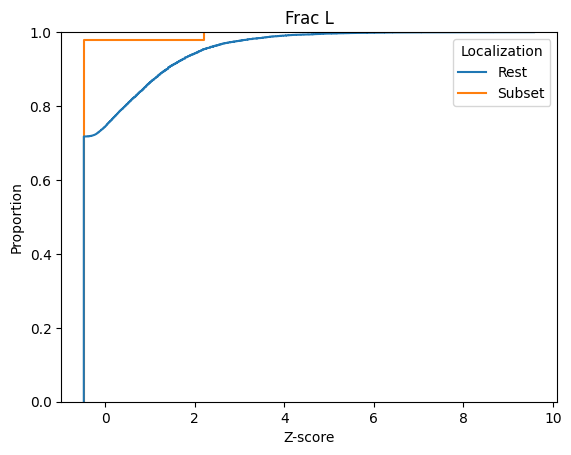

Ks_2sampResult(statistic=0.6189030897289425, pvalue=9.509446057015825e-05)
Frac M
4.021844780790045


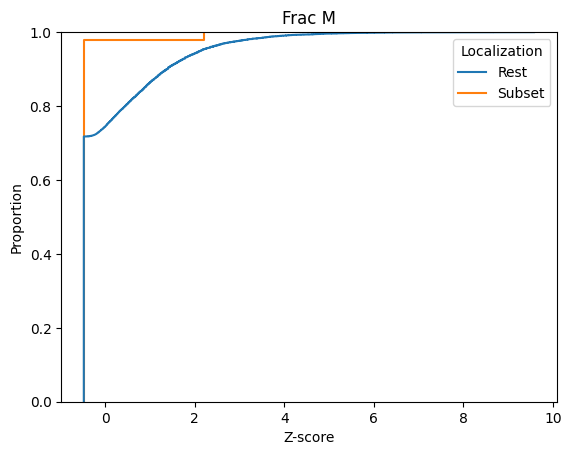

Ks_2sampResult(statistic=0.35081794327754834, pvalue=0.08166510955022858)
Frac N
0.0
Ks_2sampResult(statistic=0.5491895895845627, pvalue=0.0007891653065706176)
Frac P
3.10283201553354


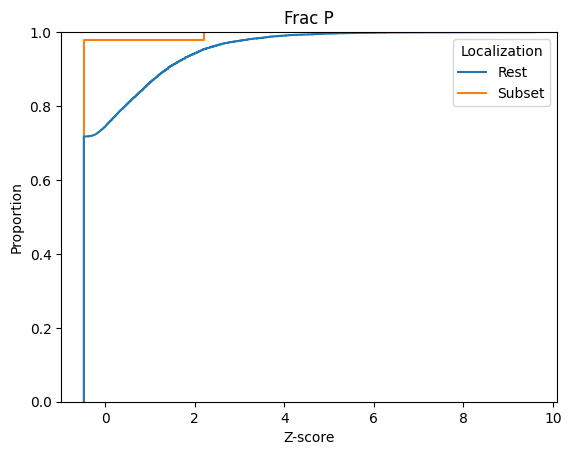

Ks_2sampResult(statistic=0.4037300222219432, pvalue=0.028939284820383552)
Frac Q
1.5385122058499767


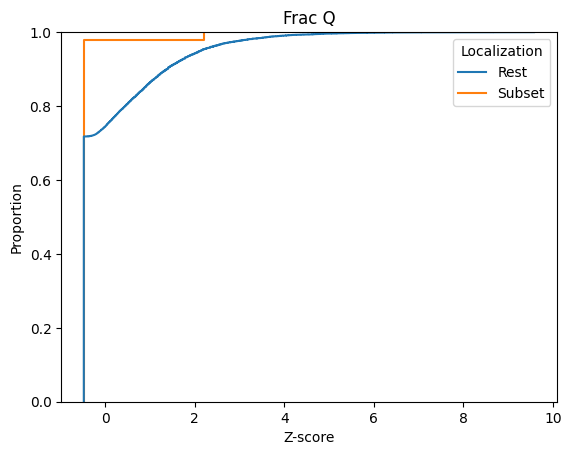

Ks_2sampResult(statistic=0.2752601976120827, pvalue=0.2784531393291873)
Frac R
0.0
Ks_2sampResult(statistic=0.2610921394583873, pvalue=0.33849643468931956)
Frac S
0.0
Ks_2sampResult(statistic=0.3010163086464703, pvalue=0.18969440470271245)
Frac T
0.0
Ks_2sampResult(statistic=0.528524437860165, pvalue=0.0014077078839091653)
Frac V
-2.8514874571032456


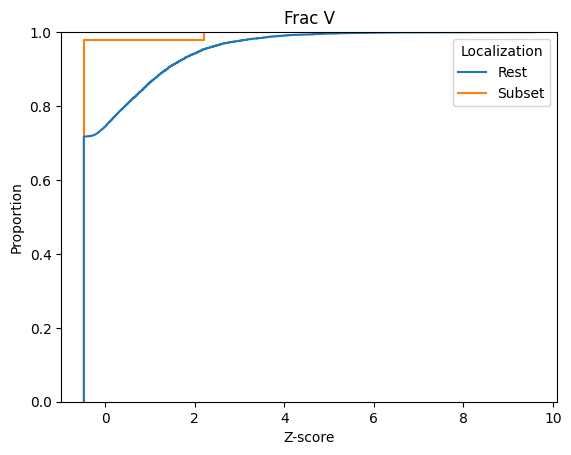

Ks_2sampResult(statistic=0.289089276970785, pvalue=0.2276216348657145)
Frac W
0.0
Ks_2sampResult(statistic=0.18976221265269733, pvalue=0.7376531508415471)
Frac Y
0.0
Ks_2sampResult(statistic=0.4040156432436504, pvalue=0.028766306953349998)
Frac K+R
-1.5411158896818078


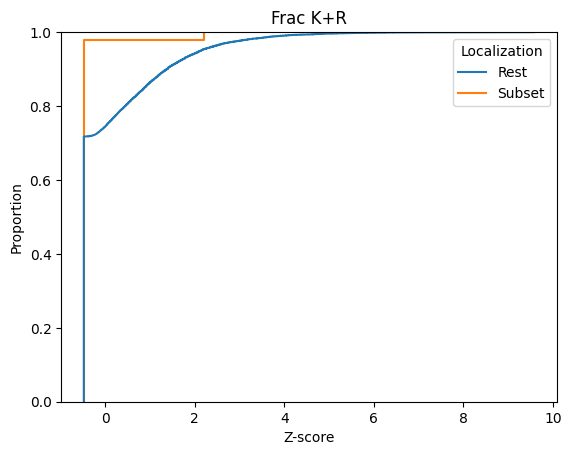

Ks_2sampResult(statistic=0.7310485744058455, pvalue=1.860400771517274e-06)
Frac D+E
-5.730393489056444


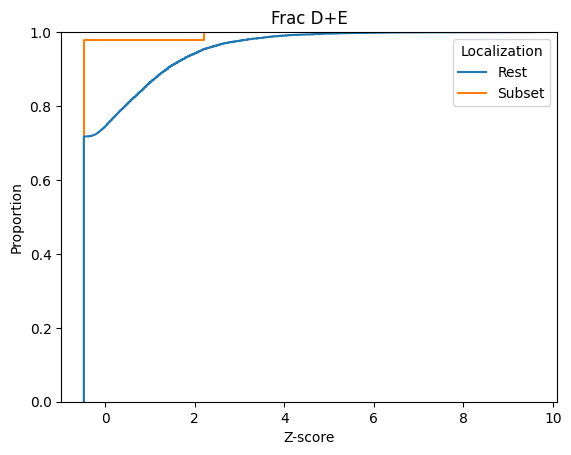

Ks_2sampResult(statistic=0.22754265483170333, pvalue=0.5116552486686787)
Frac Polar
0.0
Ks_2sampResult(statistic=0.215923215025549, pvalue=0.5797907028577447)
Frac Aliphatic
0.0
Ks_2sampResult(statistic=0.46103627073106423, pvalue=0.00798381807206002)
Frac Aromatic
-2.09778936791315


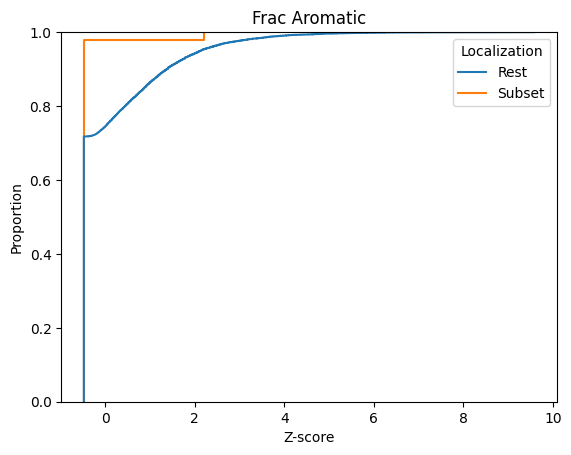

Ks_2sampResult(statistic=0.23612697894565038, pvalue=0.46358561124080533)
R/K Ratio
0.0
Ks_2sampResult(statistic=0.35058254133658084, pvalue=0.08201618318924281)
E/D Ratio
0.0
Ks_2sampResult(statistic=0.22903353379116398, pvalue=0.5031499166428807)
Frac Chain Expanding
0.0
Ks_2sampResult(statistic=0.5976635572685842, pvalue=0.00018610974455748937)
FCR
-3.7302308869619143


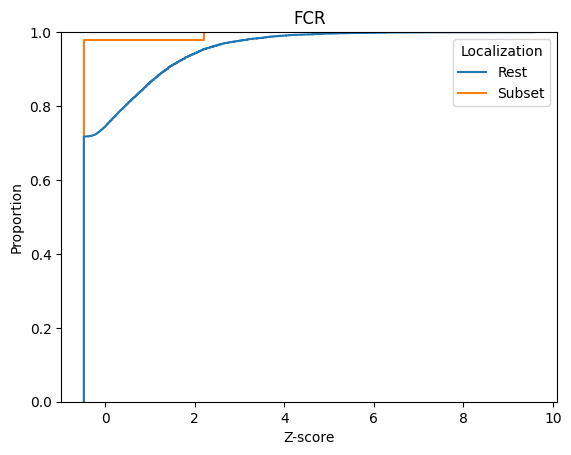

Ks_2sampResult(statistic=0.4174994664222671, pvalue=0.02157106725995316)
NCPR
1.6661283670141944


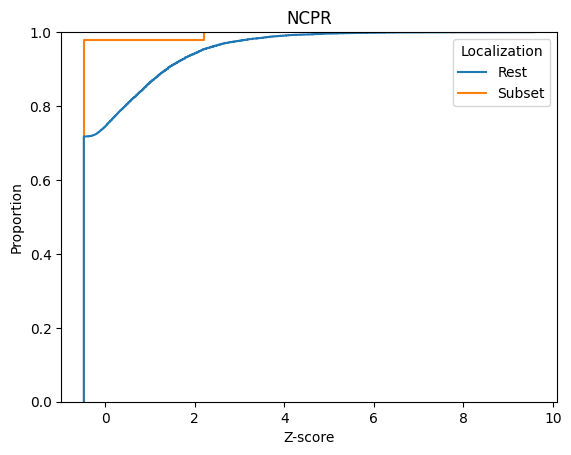

Ks_2sampResult(statistic=0.160409159960327, pvalue=0.8917536487396525)
Hydrophobicity
0.0
Ks_2sampResult(statistic=0.2457188233669383, pvalue=0.4127507380947576)
Disorder Promoting
0.0
Ks_2sampResult(statistic=0.44641937954325744, pvalue=0.011269528551332687)
Iso point
1.9480942518187871


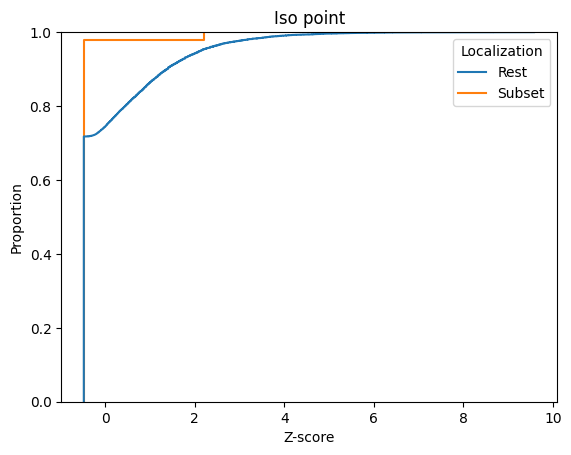

Ks_2sampResult(statistic=0.4617926956347064, pvalue=0.007840299666868715)
PPII
2.1056673376752135


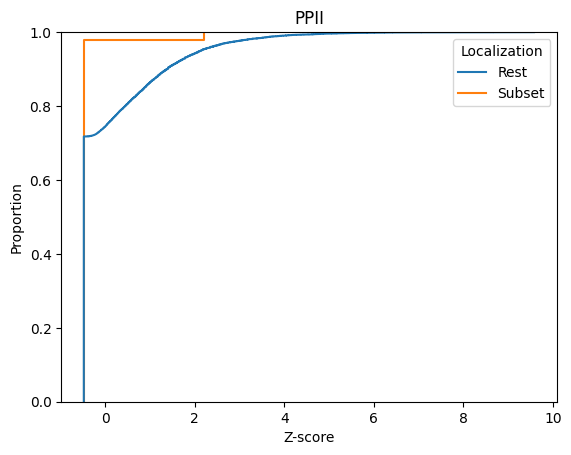

Ks_2sampResult(statistic=0.10539415700995591, pvalue=0.9987203974753756)
A Patch
0.0
Ks_2sampResult(statistic=8.160600620210623e-05, pvalue=1.0)
C Patch
0.0
Ks_2sampResult(statistic=0.04867798269952672, pvalue=0.9999999999999999)
D Patch
0.0
Ks_2sampResult(statistic=0.16504814754365926, pvalue=0.8709216567010436)
E Patch
0.0
Ks_2sampResult(statistic=0.00020401501550515455, pvalue=1.0)
F Patch
0.0
Ks_2sampResult(statistic=0.13781057362744975, pvalue=0.9659850121833975)
G Patch
0.0
Ks_2sampResult(statistic=0.010486371796964211, pvalue=1.0)
H Patch
0.0
Ks_2sampResult(statistic=0.00028562102170714976, pvalue=1.0)
I Patch
0.0
Ks_2sampResult(statistic=0.09054186388118168, pvalue=0.9999283494083094)
K Patch
0.0
Ks_2sampResult(statistic=0.013913824057450674, pvalue=1.0)
L Patch
0.0
Ks_2sampResult(statistic=0.0010608780806267148, pvalue=1.0)
M Patch
0.0
Ks_2sampResult(statistic=0.008650236657417931, pvalue=1.0)
N Patch
0.0
Ks_2sampResult(statistic=0.13989152678560224, pvalue=0.9611600505198357)

In [32]:
dfclust2 = pd.DataFrame()

for c in range(1,numclust+1):
    
    curraccclust=acclistbyclust[c-1]
    
    # Get indices in reference to full IDRome
    currclustpos=[]
    for a in curraccclust:
        curridx=subgenes.index(a)
        currclustpos.append(curridx)
    
    pvallks2=np.zeros((len(myfeatidrome)))
    pvallkslog2=np.zeros((len(myfeatidrome)))

    for p in range(0,len(myfeatidrome)): 
        dfk2 = pd.DataFrame()        
        
        nczvec=[]
        nczvec=zvecaa[:,p]
        
        czvec=[]
        for i in range(0,len(currclustpos)):
            czvec.append(subzvecpattcomp_all[currclustpos[i],p])

        if p==0:
            print(len(currclustpos))
            print(len(czvec))
            print(len(nczvec))
            
        tmp=ks_2samp(nczvec, czvec, alternative='two-sided', mode='auto')
        print(tmp)
        pvallks2[p]=tmp.pvalue
        
            
        if tmp.pvalue<0.05 and np.mean(czvec)>np.mean(nczvec):
            if tmp.pvalue!= 0:
                pvallkslog2[p]=-1*math.log10(tmp.pvalue)
            else:
                pvallkslog2[p]=30
            print(myfeatidrome[p])
            print(pvallkslog2[p])
        elif tmp.pvalue<0.05 and np.mean(czvec)<np.mean(nczvec):
            if tmp.pvalue!= 0:
                pvallkslog2[p]=math.log10(tmp.pvalue)
            else:
                pvallkslog2[p]=-30
            print(myfeatidrome[p])
            print(pvallkslog2[p])
        else:
            print(myfeatidrome[p])
            print(pvallkslog2[p])
            pvallkslog2[p]=0

        result=[]
        tmpzvec=[]
        if tmp.pvalue<0.05:
            for s in range(0,len(nczvec)):
                result.append('Rest')
                tmpzvec.append(nczvec[s])
            for s in range(0,len(czvec)):
                result.append('Cluster')
                tmpzvec.append(czvec[s])
                
            dfk2['Z-score']=tmpzvec
            dfk2['Localization']=result  

            #sbn.violinplot(x="Localization", y="Z-score", data=dfk2, hue='Localization')
            sbn.ecdfplot(x="Z-score", data=dfk2, hue='Localization', stat="proportion")
            plt.title(myfeatidrome[p])
            plt.show() 
    
    dfclust2[c]=pvallkslog2

print(dfclust2)

## 7.5 Plot significant blocky and enriched features compared to the rest of the IDRome

   Sequence Features    1         2    3    4
0            pol-pol  0.0  0.000000  0.0  0.0
1            pol-hyd  0.0  0.000000  0.0  0.0
2            pol-pos  0.0  1.756032  0.0  0.0
3            pol-neg  0.0  0.000000  0.0  0.0
4            pol-aro  0.0  0.000000  0.0  0.0
..               ...  ...       ...  ...  ...
85           S Patch  0.0  0.000000  0.0  0.0
86           T Patch  0.0  0.000000  0.0  0.0
87           V Patch  0.0  0.000000  0.0  0.0
88           Y Patch  0.0  0.000000  0.0  0.0
89           RG Frac  0.0  0.000000  0.0  0.0

[90 rows x 5 columns]
       Sequence Features         1         2         3         4
2                pol-pos  0.000000  1.756032  0.000000  0.000000
15               pos-pos  0.000000  3.683053  0.000000  0.000000
19               pos-pro  0.000000  1.913997  0.000000  0.000000
38                Frac D  4.459915  0.000000  2.372644  0.000000
39                Frac E  6.996242  0.000000  0.000000  0.000000
43                Frac I  0.000000 

([<matplotlib.axis.XTick at 0x14bb22a81790>,
 [Text(0.5, 0, 'Frac D+E'),
  Text(1.5, 0, 'Frac E'),
  Text(2.5, 0, 'FCR'),
  Text(3.5, 0, 'Disorder Promoting'),
  Text(4.5, 0, 'Frac Chain Expanding'),
  Text(5.5, 0, 'Frac D'),
  Text(6.5, 0, 'Frac K'),
  Text(7.5, 0, 'Frac S'),
  Text(8.5, 0, 'NCPR'),
  Text(9.5, 0, 'pos-pos'),
  Text(10.5, 0, 'Iso point'),
  Text(11.5, 0, 'Frac K+R'),
  Text(12.5, 0, 'Frac R'),
  Text(13.5, 0, 'pos-pro'),
  Text(14.5, 0, 'P Patch'),
  Text(15.5, 0, 'pol-pos'),
  Text(16.5, 0, 'PPII'),
  Text(17.5, 0, 'Frac N'),
  Text(18.5, 0, 'Frac I'),
  Text(19.5, 0, 'Frac Aliphatic'),
  Text(20.5, 0, 'Frac M'),
  Text(21.5, 0, 'Frac P'),
  Text(22.5, 0, 'Frac Q')])

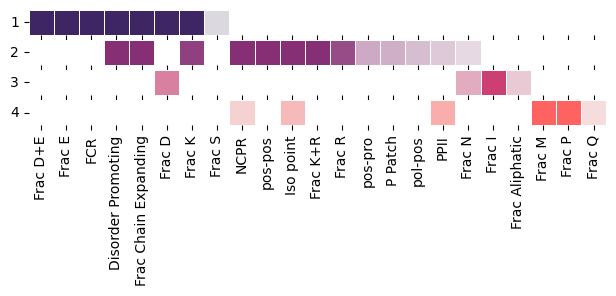

In [33]:
cutoffval=-math.log10(0.05) # if equal to 2 only showing features with p-value<0.01
maxval=3

dffeature = pd.DataFrame(myfeatidrome,columns =['Sequence Features'])

dfr = pd.concat([dffeature, dfclust2], axis=1)
print(dfr)

## Only save features that at least one cluster has a p-value > 0 ##
tmp=(dfr.select_dtypes(include=['number']) > 0).any(1)
dfr= dfr.loc[tmp==True]

## Set values below zero to zero ##
sortlist=[]
for i in range(1,numclust+1):
    dfr[i][dfr[i]<0] = 0
    sortlist.append(i)
print(dfr)


final_dfr = dfr.sort_values(by=sortlist, ascending=False)
#final_dfr = dfr
print(final_dfr)

final_dfr2=final_dfr;
mygroup=final_dfr2.pop('Sequence Features')

f,axs = plt.subplots(numclust,1,sharex=True,figsize = (12, 1.5))

cmap = plt.cm.get_cmap('rainbow', numclust-1)
cmaplist=[]
for i in range(0,numclust):
    cmaplist.append(list(cmap(i)))
    
print(cmaplist)

tmpcolorlist=['#3d2663', '#872f74', '#cb3f73', '#ff6361','#276026', '#008770', '#00aabe', '#64c8ff']

for i in range(0,numclust):
    mycmap = sbn.light_palette(tmpcolorlist[i], reverse=False, as_cmap=True) # if want to use own color list in tmpcolor
    #mycmap = sbn.light_palette(cmaplist[i], reverse=False, as_cmap=True) # if want to automatically generate color list based on number of clusters
    mycmap.set_under('white')

    sbn.heatmap(final_dfr2[[i+1]].T,cmap=mycmap,cbar=False,ax=axs[i],vmin=cutoffval,vmax=maxval,cbar_kws={'extend': 'min'},square=True,linewidth=0.5)
    axs[i].tick_params(labelrotation=0)

plt.xticks(np.arange(0.5, len(mygroup), 1), mygroup,rotation=90) 

#plt.savefig("figures/clustered_enriched_pvals_vs_idrome/"+mainprotein+"_by_cluster_sequence_features_IDRs_gte_30.pdf", transparent=True, bbox_inches = "tight") 
